# Logistic Regression

Logistic Regression was originally developed to provide a probabilistic discriminative classification model with a purely linear decision boundary (or affine, to be precise, though we will treat the terms interchangeably moving forward). 

Before the era of abundant computing resources, non-linear models were mathematically opaque and computationally expensive to evaluate. By restricting the decision boundary to a linear hyperplane, statisticians created a model that was not only easy to compute and plot, but also incredibly easy to interpret.

In classification our inference or decision is which of the possible classes a data point belongs to. The output is a multi-nomial distribution - a probability mass function across the classes. It was hard in this space to directly connect it back to how a change in a particular variable in the input affected the distribution, which was a large part of investigating a broad spectrum of scientific questions.

However it was discovered one could convert the multinomial space back into a space that was real valued and could be reached by an affine transformation of the input, their slopes and offsets (which were easy to plot and find) would give us interpertative capability. This map between the multinomial space and the real space is called the canonical link function. The inverse of it which takes us from the real space to the multinomial space is the inverse canonical link function.


For the multinomial distribution, the canonical link function is the ratio of the natural log of each of the probabilities with a reference:
$$
logit(p_k) = ln(\frac{p_k}{p_{ref}})
$$

Historically and for interpretation the reference is one of the classes ($K$) above, but for machine learning we use a symmetric version where its the geometric average of the probabilities (for clearer path to update parameters in optimizers):
$$
logit(p_k) = ln(\frac{p_k}{\sqrt[K]{\prod_{k=1}^{k=K} p_k}})
$$


For the multinomial distribution the inverse canonical link function is the softmax:
$$
p_k = \text{Softmax}_{k}(\vec{x}) = \sigma_{k}(\vec{x}) = \frac{e^{\text{logit}_k}}{\sum_{k = 1}^{K - 1} e^{\text{logit}_k}} ;\forall k \neq K \\
p_K = \text{Softmax}_{K}(\vec{x}) = \sigma_{K}(\vec{x}) = \frac{1}{1 + \sum_{k = 1}^{K - 1} e^{\text{logit}_k}}
$$

And for the symmetric one:
$$
p_k = \text{Softmax}_{k}(\vec{x}) = \sigma_{k}(\vec{x}) = \frac{e^{\text{logit}_k}}{\sum_{k = 1}^{K} e^{\text{logit}_k}}
$$

Because softmax is shift invariant its equivalent.

This was called logit space because of its association with $ln(x)$ function.

Logistic regression assumes that this logit space ($\text{logit}_k$) is modeled by $\vec{\beta_k}\vec{x}$ (an affine transformation of the input). That is for symmetric:

$$
p_k = \text{Softmax}_{k}(\vec{x}) = \sigma_{k}(\vec{x}) = \frac{e^{\vec{\beta_k}\vec{x}}}{\sum_{k = 1}^{K} e^{\vec{\beta_k}\vec{x}}}
$$

It's a linear decision boundary because at the point where the two classes (i and j) are equal, the function is linear (using symmetric here but applicable with reference):
$$
ln(\frac{p_i}{p_j}) = 0 \\
ln(\frac{p_i}{p_j}) = ln(\frac{\sigma_i(x)}{\sigma_j(x)}) = ln(\frac{\frac{e^{X \beta_i}}{\sum_{k=1}^{K} e^{X \beta_k}}}{\frac{e^{X \beta_j}}{\sum_{k=1}^{K} e^{X \beta_k}}}) \\
= ln(\frac{e^{X \beta_i}}{e^{X \beta_j}}) = ln(e^{X \beta_i}) - ln(e^{X \beta_j}) \\
= X \beta_i - X \beta_j = 0
$$


## Assumptions
* **Independence of Observations:** Each data point must be entirely independent of the others. There can be no repeated measures (e.g., measuring the same patient five times) and no temporal autocorrelation (time-series data). If rows are correlated, the model thinks it has more unique information than it actually does, which artificially shrinks Standard Errors and causes massive false-positive rates (Type I Errors).
* **Absence of Multicollinearity:** The independent variables must not be highly correlated with one another. If features overlap too closely, it becomes mathematically impossible for the model to isolate the individual effect of a specific feature. Consequently, the $\beta$ coefficients become highly unstable, and their standard errors explode.
* **Linearity in the Logit (Log-Odds):** The foundational assumption is that the log-odds can be modeled as an exact linear combination of the input features. This provides the model's immense interpretability: a one-unit increase in feature $x_i$ increases the log-odds by exactly its coefficient $\beta_i$. If violated, the coefficient weights are mathematically meaningless.
* **Lack of Strongly Influential Outliers:** Logistic Regression models fit a single continuous curve to the data. A single extreme outlier—especially one with high leverage (far away from the average feature values)—can single-handedly drag the entire decision boundary, severely distorting the coefficients for the rest of the dataset.
* **Large Sample Size (Asymptotic Convergence):** Logistic Regression relies on Maximum Likelihood Estimation (MLE). Unlike OLS regression, MLE's mathematical guarantees (like lack of bias) only hold true as the sample size approaches infinity. 
  * *Rule of Thumb:* Use the **"10 Events Per Variable" (EPV)** rule. You need at least 10 occurrences of the *least frequent* target class for every independent feature. Without this, MLE will produce biased, inflated coefficients or fail to converge due to "perfect separation."

#### An Important Caveat: Interpretability vs. Predictive Accuracy
It is crucial to note that violating these assumptions destroys *interpretability*, but it may not ruin predictive accuracy! Logistic Regression is a "high bias / low variance" model. Even if assumptions like Linearity are slightly violated, the model's rigid mathematical constraints prevent it from overfitting. In noisy or small datasets, this high-bias approach will often still yield higher classification accuracy on unseen data than complex, high-variance models (like deep decision trees) that over-fit the noise. Furthermore, violating Multicollinearity has zero negative impact on predictive accuracy; it only corrupts the individual feature weights.

#### A note about Conditional Logits

There is a logistic model called a Conditional Logit, its used in Discrete Choice modeling where we predict the probability distribution across a dynamic menu of options. In this case a set of shared coefficients is found through training for the menu items features (by training on final choice) and then these coefficients can be used to understand how a new menu item would do in relation, and in particular can passed through softmax (along with the previously computed scores) and give you a distribution. This is used by economists to measure how market share will be redistributed given a new item on the menu (by training to predict the purchased category given features). In this case an additional assumption is made when using softmax regression:

* **Independence of Irrelevant Alternatives (IIA):** This assumption states that the relative odds between any two classes depend *only* on the features and parameters of those specific classes, and are unaffected by other "irrelevant" alternatives. This leads to a specific mathematical and behavioral chain:

    1. **Structural Isolation:** Because the Softmax denominator cancels out in an odds ratio, the formula for $\frac{p_i}{p_j}$ contains no parameters from a third class $k$. The model is "blind" to $k$ when comparing $i$ vs. $j$.
    2. **The "Equal Tax" Effect:** If a new class $k$ enters the market, it must take probability mass from the "total pie." Since the model cannot change the ratio between $i$ and $j$, it is forced to "tax" their probability mass at the exact same rate to keep their ratio locked.
    3. **Requirement for Equal Distinctness:** For this to work in the real world, classes must be **mutually exclusive** and **equally distinct** (no close substitutes). If classes overlap (e.g., Red Civic vs. Blue Civic), the model will illogically steal probability from unrelated classes (like a Truck) just to maintain those fixed ratios.


  *Rule of Thumb:* If you can logically group your target classes into a hierarchy or a tree (e.g., first you choose Vehicle Type, *then* you choose Color), you will likely violate IIA. All classes must sit perfectly flat on the same conceptual level. If your data violates this, you can resolve it by using a **Nested Logistic Regression** approach—fitting sequential logistic models at each stage of the decision tree (e.g., one model to predict the Vehicle Type, and a second model to predict the Color conditioned on that specific Type).

## Optimization:
We optimize the Negative Log Likelihood Loss as detailed in the [classification notes](../../../README.md):

$$
Loss(X, \theta) = -\sum_{i=1}^{N} y_{i,c} \cdot ln(\frac{e^{\theta_c \cdot \vec{x}_i}}{\sum_{j=1}^{C} e^{\theta_j \cdot \vec{x}_i}})
$$

where $c$ denotes the label class.

Logistic regression does not have a closed form solution, unlike linear regression. Therefore we can only use iterative optimization methods, and in this case either gradient descent or a second order method (like Newtons method). Further more as discussed previously this loss function with respect to logits is convex (see [classification notes](../../../README.md) for proof), and because the logits are a linear mapping from the inputs, the overall loss landscape is guaranteed to be convex, we have a clear path to the optimum to go down (not requiring momentum or other tricks to overcome local minima). 

### Gradient Descent
Gradient descent is where you move in the steepest descent direction (that minimizes the loss function) in the parameter space:
$$
\vec{\theta}_{t+1} = \vec{\theta}_{t} - \alpha \cdot \nabla_{\theta}\text{Loss} \\
\nabla_{\theta}\text{Loss} = \sum_{i=1}^{N} (\vec{p}_i - \vec{y}_i) \vec{x}_i^T

$$

In our case of softmax regression this is an update to the $\theta$ matrix that has a row for each class, with the row being that classes $\vec{\theta}_k$. 
You can see up to the logits of the derivation in our [classification notes](../../../README.md), and in logistic regression the partial derivative from the chain rule $\frac{\partial{z}}{\partial{\theta}}$ is $\vec{x}$.

From here the variants of gradient descent (mini-batch, batch or stochastic) are applicable and can be run in a distributed manner effectively.

### Newton's Method (Second-Order)
Second-order methods (like Newton's Method) take advantage of the second derivative to find the global minimum. To build intuition, let's look at Newton's Method in a simple 1D case:
$$
\theta_{t+1} = \theta_t - \frac{f'(\theta)}{f''(\theta)}
$$

We can break the logic of this update step into two parts:
* **The Numerator ($-f'(\theta)$):** This dictates our *direction*. Just like gradient descent, if the slope is positive (going up), we subtract to move backward. If the slope is negative (going down), the double-negative means we add to move forward.
* **The Denominator ($f''(\theta)$):** This dictates our *step size* by looking at the curvature (the rate of change of the slope). If the curvature is very high (a steep, narrow bowl), the denominator is large, which *dampens* our step so we don't overshoot. If the curvature is very low (a wide, flat bowl), the denominator is small, which *accelerates* our step to cover more ground quickly.

In the multi-dimensional case:
$$
\vec{\theta}_{t+1} = \vec{\theta_t} - \mathbf{H}^{-1}  \cdot \nabla_{\vec{\theta}}\text{Loss}
$$

Now, as you can see, this method is built for $\vec{\theta}$ when it is a 1D vector. However, in our gradient descent derivation, $\theta$ was a $C \times P$ matrix. What we do in the case of logistic regression is we **flatten** that matrix into a single vector of size $[CP \times 1]$ and compute the gradient and Hessian based on that flattened vector:

* **The Gradient ($\nabla_{\vec{\theta}}\text{Loss}$):** Becomes a vector of size $[CP \times 1]$. This is simply the $[C \times P]$ matrix we derived in Gradient Descent ($\sum (\vec{p}_i - \vec{y}_i)\vec{x}_i^T$), flattened into a single column.
* **The Hessian ($\mathbf{H}$):** Becomes a square matrix of all second-order partial derivatives, with a massive shape of $[CP \times CP]$. 

**What is actually inside the Hessian?**
Because of the Softmax function, changing the weights of one class affects the probabilities of all other classes. Therefore, the Hessian is a **Block Matrix** made up of $C \times C$ smaller blocks (one for every pair of classes). 

For any two classes $j$ and $k$, the $[P \times P]$ block of the Hessian is calculated as:
$$
\mathbf{H}_{jk} = \sum_{i=1}^{N} \vec{x}_i \vec{x}_i^T \left[ p_{i,j} (\delta_{jk} - p_{i,k}) \right]
$$
#### Proof: Deriving the Hessian Block ($\mathbf{H}_{jk}$)

To understand why the Hessian takes this specific form, we can derive the block matrix $\mathbf{H}_{jk}$ that represents the second derivative of the loss with respect to the weights of class $j$ ($\theta_j$) and class $k$ ($\theta_k$). 

For clarity, we will derive this for a **single sample** first, and then apply the summation over the $N$ dataset at the end.

**1. The First Derivative (Gradient)**
From our gradient descent derivation, we know the gradient of the loss with respect to the weights of class $j$ is:
$$
\nabla_{\theta_j} L = (p_j - y_j) \vec{x}
$$

**2. Setting up the Second Derivative**
To find the Hessian block $H_{jk}$, we take the derivative of that gradient with respect to the weights of class $k$:
$$
H_{jk} = \frac{\partial}{\partial \theta_k} \left[ (p_j - y_j) \vec{x} \right]
$$

Because the true label $y_j$ is a constant ($0$ or $1$) and the feature vector $\vec{x}$ does not contain any $\theta$ parameters, both act as constants. The only term we need to differentiate is the predicted probability $p_j$:
$$
H_{jk} = \left[ \frac{\partial p_j}{\partial \theta_k} \right] \vec{x}^T
$$
*(Note: $\vec{x}$ is transposed here because the derivative of a column vector with respect to another column vector produces a matrix).*

**3. The Chain Rule**
We evaluate $\frac{\partial p_j}{\partial \theta_k}$ using the chain rule, routing it through the logit $z_k$:
$$
\frac{\partial p_j}{\partial \theta_k} = \frac{\partial p_j}{\partial z_k} \cdot \frac{\partial z_k}{\partial \theta_k}
$$

We already know the solutions to both of these partial derivatives:
* **The Logit Derivative:** Since $z_k = \theta_k \cdot \vec{x}$, the derivative $\frac{\partial z_k}{\partial \theta_k}$ is the feature vector **$\vec{x}$**.
* **The Softmax Derivative:** As proven earlier, the derivative of a Softmax probability across classes uses the Kronecker delta ($\delta_{jk}=1$ if $j=k$, else $0$): **$p_j(\delta_{jk} - p_k)$**.

Substituting these back into the chain rule gives:
$$
\frac{\partial p_j}{\partial \theta_k} = p_j(\delta_{jk} - p_k) \vec{x}
$$

**4. The Final Assembly**
Substitute this chain rule result back into our Hessian setup from Step 2:
$$
H_{jk} = \left[ p_j(\delta_{jk} - p_k) \vec{x} \right] \vec{x}^T
$$

Because $p_j(\delta_{jk} - p_k)$ is a scalar value, we can pull it to the front. The feature vector multiplies by its own transpose to create a $[P \times P]$ matrix:
$$
H_{jk} = p_j(\delta_{jk} - p_k) \vec{x} \vec{x}^T
$$

**5. Adding the Dataset Summation**
Finally, summing this result over all $N$ examples in the dataset gives us the complete formula for the Hessian block:
$$
\mathbf{H}_{jk} = \sum_{i=1}^{N} \vec{x}_i \vec{x}_i^T \left[ p_{i,j} (\delta_{jk} - p_{i,k}) \right]
$$

> **The Mathematical Intuition:** > Look at the diagonal blocks where $j = k$. The $\delta$ becomes $1$, and the scalar weight becomes $p(1-p)$. This perfectly mirrors the mathematical variance of a binomial distribution, scaled by the feature interactions ($\vec{x}\vec{x}^T$).

The update equation remains mathematically identical, operating in this flattened space:
$$
\vec{\theta}_{t+1} = \vec{\theta}_t - \mathbf{H}^{-1} \nabla_{\vec{\theta}}\text{Loss}
$$

So second-order methods do not just look at the slope (the gradient); they also calculate the curvature of the loss using the second derivative—the **Hessian matrix**. By dividing the slope by the curvature, Newton's method can calculate the exact shape of the bowl and make massive, highly efficient jumps directly to the global minimum.

Because the logistic loss landscape is strictly convex, and the number of parameters ($P$) is simply linear with respect to the features, classical (non-distributed) setups often use second-order optimization. 

This efficiency comes at a severe computational cost. The update step requires calculating and inverting a $P \times P$ Hessian matrix. Matrix inversion requires $O(P^2)$ space complexity (memory) and $O(P^3)$ time complexity (compute). Because of this $O(P^3)$ bottleneck, true second-order methods are physically impossible for massive parameter models (like Neural Networks) and are notoriously difficult to parallelize in distributed computing environments.

## Example set up
Let's generate some data from a contrived model and examine how these two optimization strategies pan out, as well as seeing how we can recover the underlying data and statistical tests for the parameters we find.
We will look at the linearily seperable case first to understand why logistic regression needs some other stopping criteria then a small gradient.

In [1]:
import numpy as np

true_coefficients = np.array([-1, 3])
true_bias = np.array([2])

true_parameters = np.hstack([true_bias, true_coefficients]).reshape(-1, 1)

# let's get some data
data = np.hstack([np.ones((1000, 1)), np.random.uniform(-1, 1, (1000, 2))])
logits = data @ true_parameters
labels = (np.exp(logits) / (1 + np.exp(logits)) > 0.5).astype(int)

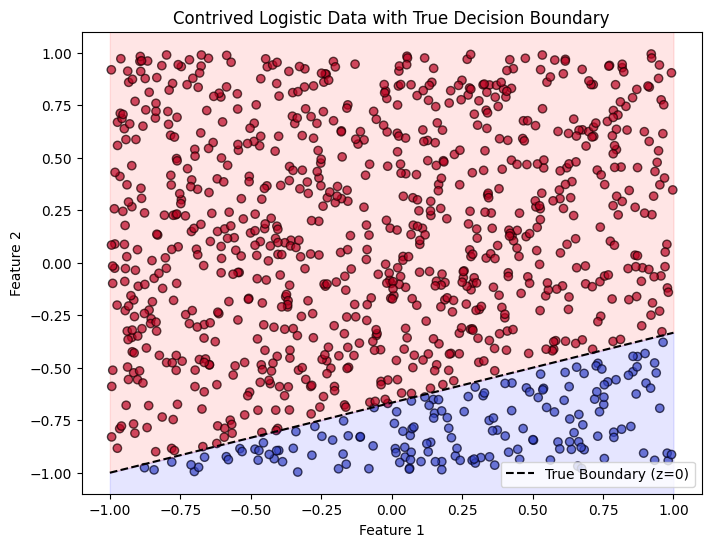

In [2]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
scatter = plt.scatter(data[:, 1], data[:, 2], c=labels.flatten(), cmap='coolwarm', edgecolors='k', alpha=0.7)
plt.legend(*scatter.legend_elements(), title="Labels")

# to draw the boundary
# z1 / z2 == 1 is where logits are equal, in this binary case z1 == 0 
# so multiply both sides and you get 0 == z2, the point x @ true_parameters = 0
# x is two dimensions, x1 and x2, so solve for x2 = -x1 * param1 /param_2 - 1/param2 * bias
# so new equation is m = -x1 * param1 /param_2, b = 1/param2 * bias
# pick two x1 points and plot their x2 and connect it to get the boundary

x_vals = np.array([-1, 1])
# true_parameters[0] is bias, [1] is x1, [2] is x2
m = -true_parameters[1] / true_parameters[2]
b = - true_parameters[0] / true_parameters[2]
y_vals = m * x_vals + b



plt.plot(x_vals, y_vals, '--', color='black', label='True Boundary (z=0)')
plt.fill_between(x_vals, y_vals, 1.5, color='red', alpha=0.1) # Shading Class 1
plt.fill_between(x_vals, y_vals, -1.5, color='blue', alpha=0.1) # Shading Class 0

plt.xlim(-1.1, 1.1)
plt.ylim(-1.1, 1.1)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Contrived Logistic Data with True Decision Boundary")
plt.legend()

So we see the linear decision boundary of this contrived example in the original space of the features.
Let's apply our two optimization strategies to see what we get.

In [3]:
def logistic_regression_solve_gradient_descent(params, learning_rate, data, labels, max_steps=100000):
    params = params.copy()
    gradient = [float("inf")]
    steps = 1
    while np.linalg.norm(gradient) > 0.0000001 and steps < max_steps:
        gradient = (1 / (1 + np.exp(-(data @ params))) - labels).T @ data
        params -= learning_rate*gradient.T
        steps += 1
    return params, steps
found_params, steps = logistic_regression_solve_gradient_descent(np.random.random((3,1)), 0.1, data, labels)

Found parameters[[146.71382599]
 [-73.88447437]
 [219.57390442]]
True parameters[[ 2]
 [-1]
 [ 3]]
Steps 100000
Accuracy: 1.0


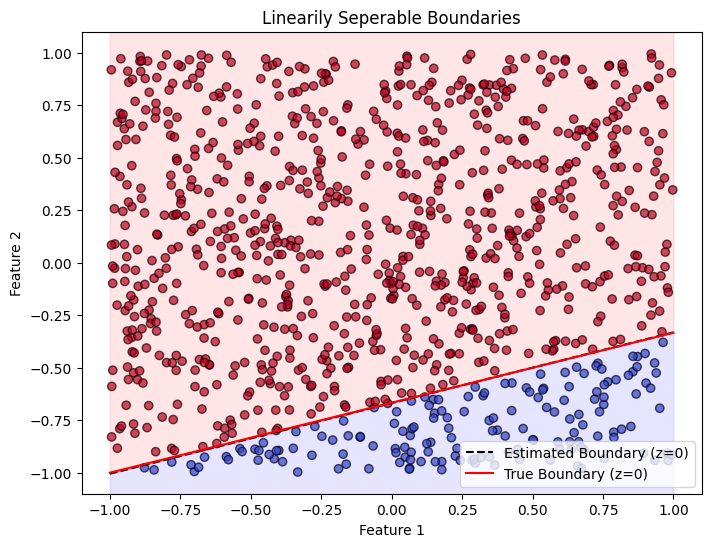

In [4]:
print(f"Found parameters{found_params}")
print(f"True parameters{true_parameters}")
print(f"Steps {steps}")
estimates = (1 / (1 + np.exp(-(data @ found_params))))
print(f"Accuracy: {((estimates > 0.5) == labels).mean()}")

m = -found_params[1] / found_params[2]
b = -found_params[0] / found_params[2]

x_vals = np.array([-1, 1])
y_vals_estimate = m * x_vals + b

plt.figure(figsize=(8, 6))
scatter = plt.scatter(data[:, 1], data[:, 2], c=labels.flatten(), cmap='coolwarm', edgecolors='k', alpha=0.7)
plt.legend(*scatter.legend_elements(), title="Labels")
plt.plot(x_vals, y_vals_estimate, '--', color='black', label='Estimated Boundary (z=0)')
plt.plot(x_vals, y_vals, color='red', label='True Boundary (z=0)')
plt.fill_between(x_vals, y_vals_estimate, 1.5, color='red', alpha=0.1) # Shading Class 1
plt.fill_between(x_vals, y_vals_estimate, -1.5, color='blue', alpha=0.1) # Shading Class 0

plt.xlim(-1.1, 1.1)
plt.ylim(-1.1, 1.1)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Linearily Seperable Boundaries")
plt.legend()
plt.show()

As we can see, the estimated boundary closely matches the true underlying boundary after being trained via Gradient Descent. Even though the raw parameter magnitudes are different, their ratios remain constant. 

This results in an equivalent classification solution because the decision boundary is defined entirely by where the logit equals zero ($z = 0$). Algebraically, if you multiply both sides of an equation equaling zero by any positive scalar constant, the geometric line remains exactly the same. The model simply scaled up the parameters to make the logits larger (creating a steeper sigmoid curve) without changing the location of the boundary itself. Geometrically, the feature coefficients in the hyperplane equation $\vec{w}^T \vec{x} + b = 0$ act as the normal vector orthogonal to the plane; scaling them by a positive value changes their magnitude but preserves their exact direction and the boundary they define.

So the boundary is found but convergence based on gradient norm is not reached (we hit our max steps).
This happens because if the data is linearily seperable, the gradient continues freely to drive the probabilities to 1.0 without penalty of misclassifying other points, eventually getting to infinity.
Let's take a look at this:

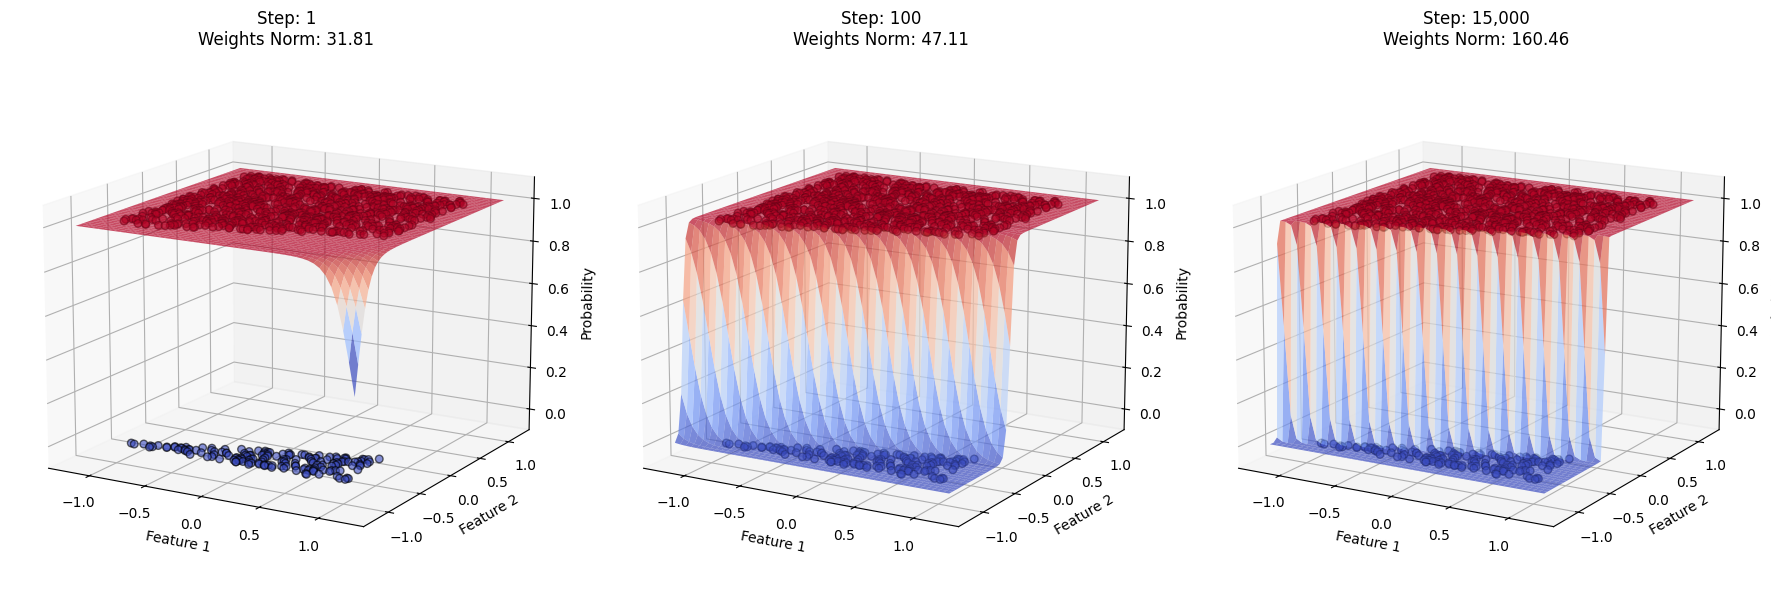

In [5]:
def logistic_regression_solve_gradient_descent_history(params, learning_rate, data, labels, max_steps=20000):
    params = params.copy()
    gradient = np.array([float("inf")])
    steps = 0
    
    # We will save the parameters at these specific iterations
    snapshots = [1, 100, 15000]
    history = []
    
    while np.linalg.norm(gradient) > 0.0000001 and steps < max_steps:
        if steps in snapshots:
            history.append((steps, params.copy()))
            
        predictions = 1 / (1 + np.exp(-(data @ params)))
        gradient = data.T @ (predictions - labels)
        params -= learning_rate * gradient
        steps += 1
        
    return params, history

initial_guess = np.random.random((3,1))
_, history = logistic_regression_solve_gradient_descent_history(initial_guess, 0.1, data, labels)

import matplotlib.pyplot as plt
import numpy as np

fig = plt.figure(figsize=(18, 6))

x1_grid = np.linspace(-1.2, 1.2, 50)
x2_grid = np.linspace(-1.2, 1.2, 50)
X1, X2 = np.meshgrid(x1_grid, x2_grid)

for i, (step, saved_params) in enumerate(history):
    ax = fig.add_subplot(1, 3, i+1, projection='3d')
    
    ax.scatter(data[:, 1], data[:, 2], labels.flatten(), 
               c=labels.flatten(), cmap='coolwarm', edgecolors='k', s=30, alpha=0.6)
    
    w0, w1, w2 = saved_params[0].item(), saved_params[1].item(), saved_params[2].item()
    Z_logits = w0 + w1*X1 + w2*X2
    Z_prob = 1 / (1 + np.exp(-Z_logits))
    
    ax.plot_surface(X1, X2, Z_prob, cmap='coolwarm', alpha=0.7, edgecolor='none')
    
    ax.set_title(f"Step: {step:,}\nWeights Norm: {np.linalg.norm(saved_params):.2f}")
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")
    ax.set_zlabel("Probability")
    ax.set_zlim(-0.1, 1.1)
    ax.view_init(elev=15, azim=-60) # Low elevation to clearly see the steepness

plt.tight_layout()
plt.show()

So the output probability surface keeps getting stretched to push the probability of the label 1 points closer and closer to 1, now lets do this analysis with linearily seperable data:

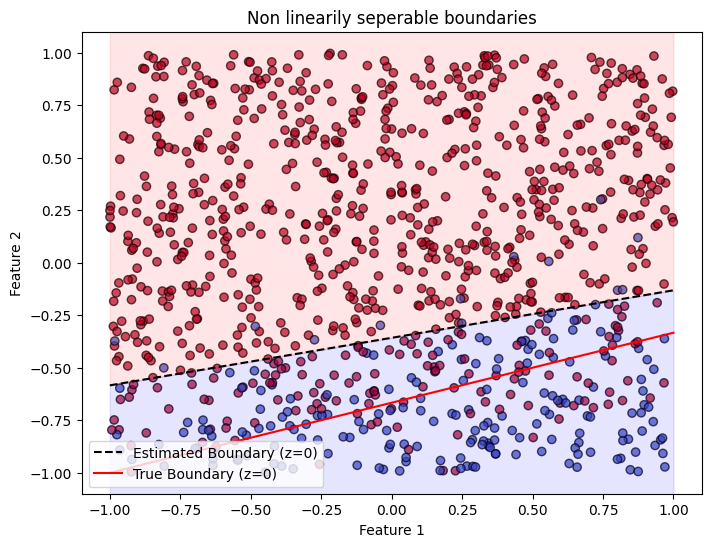

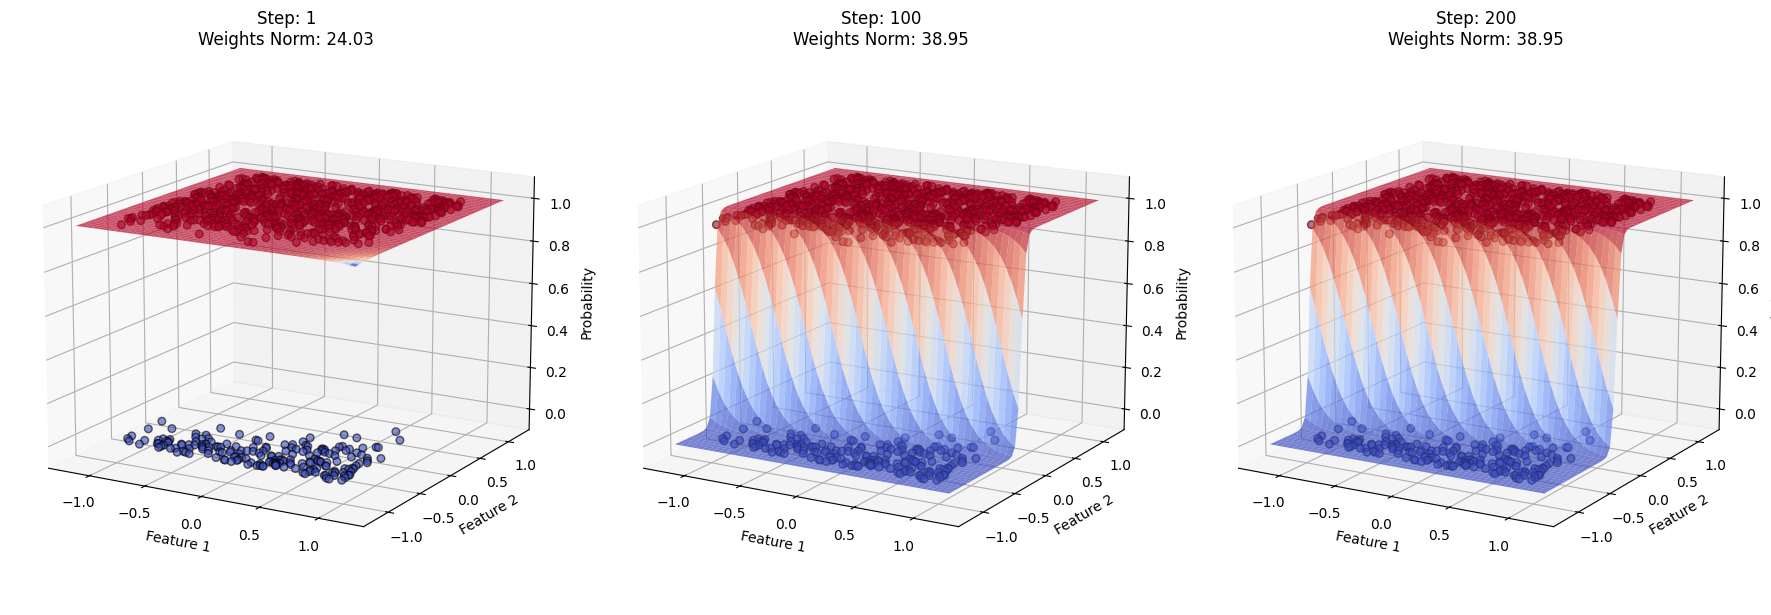

In [6]:
true_coefficients = np.array([-1, 3])
true_bias = np.array([2])

true_parameters = np.hstack([true_bias, true_coefficients]).reshape(-1, 1)

# let's get some data
data = np.hstack([np.ones((1000, 1)), np.random.uniform(-1, 1, (1000, 2))])
logits = data @ true_parameters  + np.random.normal(0, 1, (1000, 1))
labels = (np.exp(logits) / (1 + np.exp(logits)) > 0.5).astype(int)

x_vals = np.array([-1, 1])
m = -true_parameters[1] / true_parameters[2]
b = - true_parameters[0] / true_parameters[2]
y_vals = m * x_vals + b


def logistic_regression_solve_gradient_descent_history(params, learning_rate, data, labels, max_steps=20000):
    params = params.copy()
    gradient = np.array([float("inf")])
    steps = 0
    
    # We will save the parameters at these specific iterations
    snapshots = [1, 100, 200]
    history = []
    
    while np.linalg.norm(gradient) > 0.0000001 and steps < max_steps:
        if steps in snapshots:
            history.append((steps, params.copy()))
            
        predictions = 1 / (1 + np.exp(-(data @ params)))
        gradient = data.T @ (predictions - labels)
        params -= learning_rate * gradient
        steps += 1
        
    return params, history

initial_guess = np.random.random((3,1))
found_params, history = logistic_regression_solve_gradient_descent_history(initial_guess, 0.1, data, labels)

m = -found_params[1] / found_params[2]
b = -found_params[0] / found_params[2]

x_vals = np.array([-1, 1])
y_vals_estimate = m * x_vals + b

plt.figure(figsize=(8, 6))
scatter = plt.scatter(data[:, 1], data[:, 2], c=labels.flatten(), cmap='coolwarm', edgecolors='k', alpha=0.7)
plt.legend(*scatter.legend_elements(), title="Labels")
plt.plot(x_vals, y_vals_estimate, '--', color='black', label='Estimated Boundary (z=0)')
plt.plot(x_vals, y_vals, color='red', label='True Boundary (z=0)')
plt.fill_between(x_vals, y_vals_estimate, 1.5, color='red', alpha=0.1) # Shading Class 1
plt.fill_between(x_vals, y_vals_estimate, -1.5, color='blue', alpha=0.1) # Shading Class 0

plt.xlim(-1.1, 1.1)
plt.ylim(-1.1, 1.1)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Non linearily seperable boundaries")
plt.legend()
plt.show()

import matplotlib.pyplot as plt
import numpy as np

fig = plt.figure(figsize=(18, 6))

x1_grid = np.linspace(-1.2, 1.2, 50)
x2_grid = np.linspace(-1.2, 1.2, 50)
X1, X2 = np.meshgrid(x1_grid, x2_grid)

for i, (step, saved_params) in enumerate(history):
    ax = fig.add_subplot(1, 3, i+1, projection='3d')
    
    ax.scatter(data[:, 1], data[:, 2], labels.flatten(), 
               c=labels.flatten(), cmap='coolwarm', edgecolors='k', s=30, alpha=0.6)
    
    w0, w1, w2 = saved_params[0].item(), saved_params[1].item(), saved_params[2].item()
    Z_logits = w0 + w1*X1 + w2*X2
    Z_prob = 1 / (1 + np.exp(-Z_logits))
    
    ax.plot_surface(X1, X2, Z_prob, cmap='coolwarm', alpha=0.7, edgecolor='none')
    
    ax.set_title(f"Step: {step:,}\nWeights Norm: {np.linalg.norm(saved_params):.2f}")
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")
    ax.set_zlabel("Probability")
    ax.set_zlim(-0.1, 1.1)
    ax.view_init(elev=15, azim=-60) # Low elevation to clearly see the steepness

plt.tight_layout()
plt.show()

If the data is *not* linearly separable (i.e., you can see points crossing over the boundary deep into opposing territory), the competing errors create a natural mathematical balance. The optimizer finds a true minimum, allowing the gradient norm to successfully converge toward zero.

Because we cannot guarantee in advance whether a dataset will be perfectly separable or not, production-level Gradient Descent implementations always use dual stopping criteria: reaching a near-zero gradient norm OR hitting a maximum number of iterations. 

```python
def logistic_regression_solve_gradient_descent(params, learning_rate, data, labels, max_steps=100000):
    params = params.copy()
    gradient = np.array([np.inf]) # Use numpy infinity for consistency
    steps = 1
    
    while np.linalg.norm(gradient) > 0.0000001 and steps < max_steps:
        gradient = (1 / (1 + np.exp(-(data @ params))) - labels).T @ data
        params -= learning_rate * gradient.T
        steps += 1
        
    return params, steps

So now we develop the solver using Newton's Second Order Method. In this example (binary) the gradient is already a vector, and the hessian can is the derivative of this vector, now we could compute this at a point by point level by $H = \sum_{i=1}^{N} p_i*(1-p_i) x_i \cdot {x_i}^T$. A much faster way that iteration is to do the following matrix multiplication:
$X^T D X$ where D is $\text{Diagnol}(p(1-p))$ so every row of X is being scaled by diagnol element of P then multiplied by its transpose! We can also avoid creating a NxN diagnol matrix by simply broadcasting the $p(1-p)$ term on the right matrix.

In [7]:
def logistic_regression_solve_newtons(params, data, labels, max_steps=20):
    params = params.copy()
    update = np.array([np.inf])
    steps = 1
    while np.linalg.norm(update) > 0.0001 and steps < max_steps:
        predictions = (1 / (1 + np.exp(-(data @ params))))
        gradient = (predictions - labels).T @ data
        hessian = data.T @ (predictions * (1- predictions) * data)
        update = np.linalg.inv(hessian) @ gradient.T
        params -= update
        steps += 1
    return params, steps
newton_params, newton_steps = logistic_regression_solve_newtons(np.random.uniform(-1, 1, (3,1)), data, labels)
newton_params, newton_steps

(array([[ 3.82042241],
        [-1.44107468],
        [ 5.99507575]]),
 9)

In [8]:
# get accuracy
predictions = (1 / (1 + np.exp(-data @ newton_params)))
((predictions > 0.5).astype(int) == labels).mean()

np.float64(0.893)

It is important to note how the variance $p(1-p)$ dictates the optimizer's behavior. The Hessian matrix weights each data point by its variance. Points the model is unsure about ($p \approx 0.5$) have the maximum variance, so they heavily influence the Hessian, creating sharp curvature. Points the model is highly confident about ($p \approx 1$ or $0$) have near-zero variance and are practically ignored. 

However, because Newton's Method updates the parameters using the **inverse** of the Hessian ($H^{-1}$), this creates a brilliant dynamic: 
* Where the model is **unsure** (large Hessian), the inverse creates a **small, careful** update step to avoid overshooting the boundary.
* Where the model is **highly confident** (small Hessian), the inverse creates a **massive, aggressive** leap forward.

We will now visualize the loss function and paths these two approaches take.

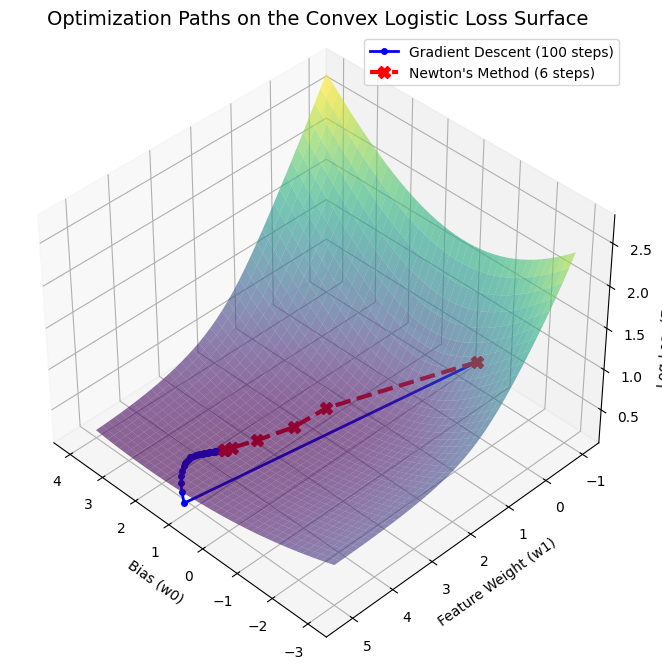

In [9]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
num_samples = 150

x_1d = np.random.uniform(-3, 3, (num_samples, 1))
data_2d = np.hstack([np.ones((num_samples, 1)), x_1d])

true_w = np.array([[1.0], [2.0]])
logits_2d = data_2d @ true_w + np.random.normal(0, 1.5, (num_samples, 1))
labels_2d = (logits_2d > 0).astype(int)


def compute_log_loss(w0, w1):
    w = np.array([[w0], [w1]])
    # Stable logit clipping to prevent overflow
    logits = np.clip(data_2d @ w, -250, 250) 
    preds = 1 / (1 + np.exp(-logits))
    preds = np.clip(preds, 1e-15, 1 - 1e-15) 
    return -np.mean(labels_2d * np.log(preds) + (1 - labels_2d) * np.log(1 - preds))

w0_grid = np.linspace(-3, 4, 40)
w1_grid = np.linspace(-1, 5, 40)
W0, W1 = np.meshgrid(w0_grid, w1_grid)
Loss_Surface = np.zeros_like(W0)

for i in range(W0.shape[0]):
    for j in range(W0.shape[1]):
        Loss_Surface[i, j] = compute_log_loss(W0[i, j], W1[i, j])

initial_guess = np.array([[-1.5], [-0.0]]) 

w_gd = initial_guess.copy()
path_gd = [w_gd.flatten()]
for _ in range(100): 
    logits = np.clip(data_2d @ w_gd, -250, 250)
    preds = 1 / (1 + np.exp(-logits))
    grad = data_2d.T @ (preds - labels_2d) 
    w_gd -= 0.05 * grad 
    path_gd.append(w_gd.flatten())
path_gd = np.array(path_gd)


w_nt = initial_guess.copy()
path_nt = [w_nt.flatten()]
for _ in range(6): 
    logits = np.clip(data_2d @ w_nt, -250, 250)
    preds = 1 / (1 + np.exp(-logits))
    grad = data_2d.T @ (preds - labels_2d)
    
    H = data_2d.T @ (preds * (1 - preds) * data_2d)
    H += np.eye(H.shape[0]) * 1e-4 
    
    w_nt -= np.linalg.inv(H) @ grad
    path_nt.append(w_nt.flatten())
path_nt = np.array(path_nt)

z_gd = [compute_log_loss(w[0], w[1]) for w in path_gd]
z_nt = [compute_log_loss(w[0], w[1]) for w in path_nt]

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(W0, W1, Loss_Surface, cmap='viridis', alpha=0.6, edgecolor='none')

ax.plot(path_gd[:, 0], path_gd[:, 1], z_gd, 
        color='blue', marker='o', markersize=4, linewidth=2, label=f'Gradient Descent ({len(path_gd)-1} steps)')

ax.plot(path_nt[:, 0], path_nt[:, 1], z_nt, 
        color='red', marker='X', markersize=8, linewidth=3, linestyle='--', label=f"Newton's Method ({len(path_nt)-1} steps)")

ax.set_title("Optimization Paths on the Convex Logistic Loss Surface", fontsize=14)
ax.set_xlabel("Bias (w0)")
ax.set_ylabel("Feature Weight (w1)")
ax.set_zlabel("Log-Loss (Error)")
ax.legend()
ax.view_init(elev=40, azim=135) 

plt.show()

As visualized, Newton's Method takes a much more direct and step-efficient path to the global minimum. However, this mathematical efficiency comes at a massive computational cost. 

It requires calculating and inverting the $P \times P$ Hessian matrix at every step, which carries an $O(P^2)$ space complexity and an $O(P^3)$ time complexity. While this is trivial for classical statistics with a few variables, it becomes strictly prohibitive in highly parameterized machine learning models. Furthermore, unlike first-order gradients, matrix inversion is non-trivial to compute in a distributed, multi-node environment. For large-scale problems, Gradient Descent (and its stochastic variants) remains the undisputed standard.

# Two Goals
Next, we will explore the dual objectives of Logistic Regression. In practice, modelers face an inherent tension between Interpretability—isolating and understanding the exact impact of individual features—and Predictive Power—tuning the model to minimize generalization error on new data.

## Interpertability
When our primary goal is interpretability, we want to rigorously understand the relationship between the features and the target label. Specifically, we want to quantify exactly how a one-unit change in a given feature impacts the probability of a positive classification.

The following are the assumptions and how we test and mitigate violations of them (these are assumptions listed in the beginning of this notebook).

### Independence of Observations
Fundamentally, this assumption dictates that every single row in your dataset must be a completely independent entity, with absolutely no relation to any other row. Mathematically, this means that knowing the features or the outcome of Row $A$ gives you zero predictive power about what Row $B$ will look like. 

Every row must represent a discrete, separate event. If you flip a coin twice, the second flip is completely independent. But if you measure a patient's blood pressure on Tuesday, and measure that *same* patient again on Wednesday, those two rows are related. They share an underlying, unmeasured baseline (that specific patient's genetics, diet, and lifestyle). Row 2 is essentially just Row 1 plus a little bit of daily noise. They aren't two separate entities; they are one entity stretched across two rows.

The reason this matters for interpretability is that when we optimize the Negative Log-Likelihood (NLL), the standard error of our coefficients is inversely related to the curvature (steepness) of the NLL "bowl" at its minimum (we will examine this shortly after this assumptions section). The algorithm calculates the overall likelihood by multiplying the probabilities of individual rows, which is mathematically valid only if those events are truly independent. If they are not (e.g., clustered data), the algorithm is multiplying redundant information. This creates a fake NLL curve that is artificially steep. While the bottom of the bowl (the β coefficients) remains in the correct location, the artificial steepness tricks the model into calculating a much smaller Standard Error, destroying the reliability of the p-values.

##### How it is Violated (The 3 Main Culprits)
1. **Repeated Measures:** Measuring the same subject multiple times (e.g., tracking the same patient's heart rate once a month for a year).
2. **Clustered / Hierarchical Data:** Data grouped by a shared environment (e.g., testing students who all share the same teacher, or houses located in the same neighborhood).
3. **Temporal Autocorrelation:** Time-series data where today's value is heavily dependent on yesterday's value (e.g., predicting daily stock market movements).

##### How to Detect It
Unlike other assumptions, independence is primarily checked through **study design and logic** rather than pure math. You must ask: *"How was this data collected?"*
* **Logical Check:** Does a single entity (person, machine, location) appear in multiple rows? 
* **Statistical Check (Time-Series):** You can plot an Autocorrelation Function (ACF) to see if residuals are correlated with past versions of themselves. This is where you test different time shifts (lags) in the residuals, calculate the correlation between the original and the shifted residuals, and plot that correlation against the shift size. In an independent dataset, this plot should look like pure, random white noise. If clear spikes appear at certain lags, it proves the presence of temporal dependencies.
* **Statistical Check (Clusters):** Visualizing Grouped Residuals: This is the single most robust way to detect clustering. By grouping the model's errors (residuals) by the cluster ID, you can see if a cluster is systematically dragging the outcome up or down. This catches all cluster effects, regardless of where they hide.

##### How to Mitigate Violations
If your data is not independent, standard Logistic Regression will yield untrustworthy inference. You must adjust your approach:
1. **Aggregation (The Data Science Fix):** Group the data by the repeating entity. If you have 10 rows for one patient, aggregate them into a single row representing that patient's *average* or *maximum* values. (Trades dataset size for perfect independence).
2. **Cluster-Robust Standard Errors (The Sandwich Estimator):**
You can tell the statistical software to group the standard error calculations by a specific cluster (e.g., `cov_type='cluster'`). This doesn't change the $\hat{\theta}$ coefficients, but it recalculates honest, wider Standard Errors to fix the p-values. It does this by directly factoring the covariance between correlated observations back into the variance calculation using the Huber-White Sandwich Estimator. 

    **The Math:** We will dig in more detail into this as we implement interpertability, but using a first-order Taylor expansion of the gradients, the variance of our coefficients is defined as the "Sandwich": $V[\hat{\theta}] = H^{-1} \cdot V[g] \cdot H^{-1}$. 
    * **If observations are independent:** We can take advantage of the *Information Matrix Equality*, which proves that the variance of the gradients equals the curvature ($V[g] = H$). The matrices cancel out, and the formula beautifully simplifies to the naive variance: $V[\hat{\theta}] = H^{-1}$. 
    * **If observations are clustered:** The Information Matrix Equality breaks ($V[g] \neq H$). Because they are no longer equal, the math does not cancel out. The software must explicitly estimate both the inverse curvature ($H^{-1}$) and the true variance of the grouped gradients ($V[g]$), and manually compute the full equation: $H^{-1} \cdot V[g] \cdot H^{-1}$. To estimate the hessian, you would get second derivative of every point of NLL and add it together (will show later), to estimate the $V[g]$, we take advantage of $E[g] == 0$ but because they're not independent ($V[X + Y] = V[X] + V[Y] + COV[X,Y]$), instead of squaring each row's gradient individually, we sum the gradients within each cluster first, and then square those combined cluster-level gradients then sum across the clusters. This mathematically bakes the hidden covariance right into the variance matrix.
3. **Time Lagged variables:** If you detect ACF, the easiest and most interpretable machine-learning fix is almost always add lagged variables. It directly models the time dynamic rather than just widening the standard errors to hide from it.

4. **Longitudinal Data (Time + Clusters):**
If your data violates both time and cluster independence (e.g., tracking the same patients over multiple days), standard Logistic Regression fails completely. You must upgrade to longitudinal models. 
    * **Generalized Estimating Equations (GEE):** Acts like an advanced Sandwich Estimator. It allows you to specify the exact time-series structure (like AR-1) *inside* your clusters. **Interpretability:** Yields "Population-Average" insights (How a feature affects the overall average population).
    * **Generalized Linear Mixed Models (GLMM):** Also known as Mixed-Effects models. It calculates a unique baseline intercept for every single cluster (Random Effects) alongside the standard feature coefficients (Fixed Effects). **Interpretability:** Yields "Subject-Specific" insights (How a feature affects a specific individual, controlling for their unique genetic/environmental baseline).
> **Note on Scope:** While GEE and GLMM are the mathematically correct solutions for longitudinal data, they represent an entirely different class of advanced econometrics. Because the core focus of this notebook is standard Logistic Regression, we will not be implementing these mixed models here.

In [10]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

# 1. Setup the Illusion: 100 Patients, 10 observations each
n_patients = 100
obs_per_patient = 10
total_N = n_patients * obs_per_patient  # 1000 total rows

np.random.seed(42)

# 2. Engineer the Patient Bias (The hidden cluster effect)
# We assign a strong, hidden log-odds modifier to each specific patient
patient_biases = np.random.normal(loc=0, scale=2.5, size=n_patients)

# 3. Build the dataset
data_clustered = []
patient_ids = []

for patient_id in range(n_patients):
    # Get this specific patient's secret bias
    specific_bias = patient_biases[patient_id]
    
    for _ in range(obs_per_patient):
        # Generate random features for this specific visit
        feat_1 = np.random.normal(0, 1)
        feat_2 = np.random.normal(0, 1)
        
        # LOGIT EQUATION: (True Beta * Feature) + PATIENT BIAS + random noise
        # Notice we make the true beta for feat_2 very weak (0.2)
        logit = (1.5 * feat_1) + (0.2 * feat_2) + specific_bias + np.random.normal(0, 0.5)
        
        # Convert to probability and binary label
        prob = np.exp(logit) / (1 + np.exp(logit))
        label = 1 if prob > 0.5 else 0
        
        data_clustered.append([1.0, feat_1, feat_2, label]) # 1.0 is the Bias/Intercept column
        patient_ids.append(patient_id)

# Convert to DataFrames for statsmodels
df_clustered = pd.DataFrame(data_clustered, columns=['Bias', 'Feature_1', 'Feature_2', 'Label'])
labels_clustered = df_clustered.pop('Label')

In [11]:
print("--- MODEL 1: THE NAIVE MODEL (Assumes 1000 Independent Rows) ---")
naive_model = sm.Logit(labels_clustered, df_clustered).fit(disp=False)
print(naive_model.summary().tables[1])

print("\n--- MODEL 2: THE HONEST MODEL (Corrects for 100 Clusters) ---")
honest_model = sm.Logit(labels_clustered, df_clustered).fit(
    disp=False, 
    cov_type='cluster', 
    cov_kwds={'groups': patient_ids}
)
print(honest_model.summary().tables[1])

--- MODEL 1: THE NAIVE MODEL (Assumes 1000 Independent Rows) ---
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Bias          -0.0619      0.072     -0.862      0.389      -0.203       0.079
Feature_1      1.1619      0.089     13.075      0.000       0.988       1.336
Feature_2      0.1636      0.074      2.212      0.027       0.019       0.309

--- MODEL 2: THE HONEST MODEL (Corrects for 100 Clusters) ---
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Bias          -0.0619      0.176     -0.351      0.726      -0.408       0.284
Feature_1      1.1619      0.130      8.964      0.000       0.908       1.416
Feature_2      0.1636      0.079      2.073      0.038       0.009       0.318


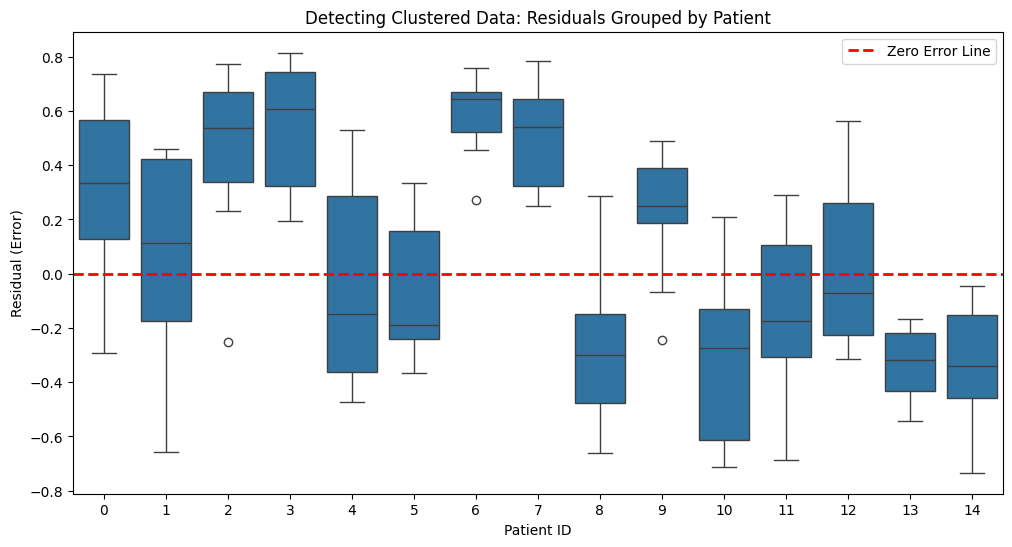

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Get the predictions from our Naive Model
predictions = naive_model.predict(df_clustered)

# 2. Calculate the Residuals (Actual Label - Predicted Probability)
residuals = labels_clustered - predictions

# 3. Create a DataFrame for plotting
df_residuals = pd.DataFrame({
    'Patient_ID': patient_ids,
    'Residual': residuals
})

# 4. Plot the residuals for just the first 15 patients to see the pattern
plt.figure(figsize=(12, 6))
sns.boxplot(x='Patient_ID', y='Residual', data=df_residuals[df_residuals['Patient_ID'] < 15])
plt.axhline(0, color='red', linestyle='--', linewidth=2, label="Zero Error Line")
plt.title("Detecting Clustered Data: Residuals Grouped by Patient")
plt.xlabel("Patient ID")
plt.ylabel("Residual (Error)")
plt.legend()
plt.show()

### Absence of Multicollinearity
We must first ensure our features are not highly correlated with one another. If our features overlap too much, it creates multicollinearity. This confuses the model, causing standard errors to explode and corrupting any p-value-based inference tests we try to run later.

We test for this using the Variance Inflation Factor (VIF). The variance inflation factor looks at how well a feature can be predicted from other features via a ratio of the error in prediction. Specifically, it compares the error if you predicted that feature's average (SST, or total sum of squares) versus if you fit a model using the other features to predict it (SSR, or sum of squared residuals). 

If a VIF is 1, for example, it shows that using the other features is no better than the simple average prediction. But this ratio's size corresponds to how redundant the feature is given the other features. A common rule of thumb is that VIF > 5 indicates problematic multicollinearity, and VIF > 10 indicates severe multicollinearity. This view is mathematically equivalent to $\text{VIF} = 1 / (1 - R^2)$, because $1 - R^2$ is exactly the ratio of $SSR / SST$.

To calculate VIF for categorical variables, they must first be converted into binary dummy variables (0 and 1). We can then use the standard squared-error VIF approach. However, to avoid perfect multicollinearity (a VIF of infinity), we must always drop one reference category (known as avoiding the Dummy Variable Trap).

So we can use VIF as a filter (say above 5, drop iteratively) as a feature selection method for interpretation.


In [13]:
# we will add a third feature thats a linear trasnformation of the second and some noise and get the VIFs to show this.
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

data_redundant = np.concat([data,  (data[:, 2] * 6 + np.random.uniform(-0.1, 0.1, (data.shape[0]))).reshape(-1, 1)],axis=1)
def check_multicollinearity(data, feature_names):
    vif_data = pd.DataFrame()
    vif_data["Feature"] = feature_names
    vif_data["VIF Score"] = [
        variance_inflation_factor(data, i)
        for i in range(data.shape[1])
    ]
    return vif_data
check_multicollinearity(data_redundant, ["bias", "feature_1", "feature_2", "feature_3"])

,Feature,VIF Score
0,bias,1.002629
1,feature_1,1.000468
2,feature_2,3608.303247
3,feature_3,3608.326537


In [14]:
# now lets just get the first 3 features:
check_multicollinearity(data, ["bias", "feature_1", "feature_2"])


,Feature,VIF Score
0,bias,1.000301
1,feature_1,1.000100
2,feature_2,1.000100


As we can see the VIF is reduced once we take out one of the redundant features.


#### Linearity in the Logit
The continuous features must have a linear relationship with the log-odds of the target variable.

This can be tested with visual inspection, plotting each logit with regards to it's log-odds, practically we bin each feature and then compute an average clipped log odds for each group. Then plot these this should roughly be a line. While visual inspection of binned log-odds scales efficiently for large datasets, it requires a sufficient sample size to yield stable probabilities. A standard rule of thumb is to use 10 to 20 bins, ensuring at least 30-50 observations per bin to avoid extreme probability spikes.

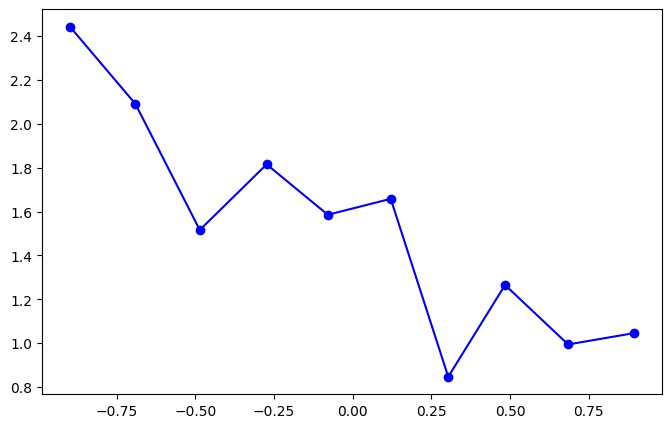

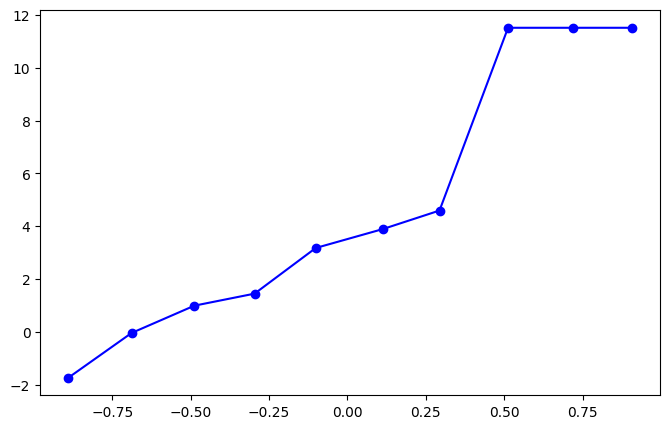

In [15]:
import pandas as pd
# plotting binned class logit versus their labels average clipped logit 
def plot_binned_log_odds_with_label(feature_values, labels, num_bins=10):
    # bin
    data = pd.DataFrame({'x': feature_values.flatten(), 'y': labels.flatten()})
    data["bin"] = pd.qcut(data["x"], q=num_bins)
    grouped = data.groupby('bin', observed=False).agg({'x': 'mean', 'y': 'mean'})
    p = np.clip(grouped["y"], 1e-5, 1 - 1e-5)
    grouped["log_odds"] = np.log(p/(1-p))
    plt.figure(figsize=(8,5))
    plt.plot(grouped["x"], grouped["log_odds"], marker='o', linestyle='-', color='b')
    plt.show()

plot_binned_log_odds_with_label(data[:, 1], labels)

plot_binned_log_odds_with_label(data[:, 2], labels)

As you can see its roughly linear, the max at 12 is clipping.

Another way to test is to use Box-Tidwell test, which adds $Xln(X)$ for each feature as a detector one feature at a time and keeping all the base features (mathematically detects higher power terms when optimized), and look at the p-value for it with the null hypothesis test being it's coefficient is 0. It is crucial to note that the Box-Tidwell test is highly sensitive to multicollinearity. If the original features are highly correlated, their $X \ln(X)$ interaction terms will also be correlated. We must verify the **Absence of Multicollinearity** before we can fully trust our inference tests including the Box-Tildwell, otherwise the multi-colinearity will render our analysis ineffective.

**Note on the Natural Logarithm:** We must be careful when calculating the $X \ln(X)$ interaction terms, as the natural logarithm is mathematically undefined for zero and negative numbers. To safely bypass this, we shift the feature values up by adding a constant to ensure all values are strictly positive. This linear shift is safe to do because Logistic Regression models include a bias (intercept) term, which seamlessly absorbs the constant without altering the feature's coefficient or the underlying geometric shape of the data.

In [16]:
import statsmodels.api as sm

def box_tidwell_test(data, labels):
    base_features = {'Bias': data[:, 0]}
    for j in range(1, data.shape[1]):
        base_features[f'Feature_{j}'] = data[:, j]
        
    for i in range(1, data.shape[1]):
        shifted = data[:, i] - np.min(data[:, i]) + 1
        interaction = shifted * np.log(shifted)
        
        # 3. Copy the base features and add ONLY the current interaction term
        test_features = base_features.copy()
        test_features[f'Interaction_{i}'] = interaction
        
        # 4. Fit the model
        df_bt = pd.DataFrame(test_features)
        bt_model = sm.Logit(labels, df_bt).fit(disp=False)
        
        print(f"\n--- Box-Tidwell Test for Feature {i} ---")
        print(bt_model.summary().tables[1])

# Run it!
box_tidwell_test(data, labels)


--- Box-Tidwell Test for Feature 1 ---
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Bias              4.2532      2.395      1.776      0.076      -0.442       8.948
Feature_1        -0.9480      2.716     -0.349      0.727      -6.271       4.375
Feature_2         5.9991      0.474     12.655      0.000       5.070       6.928
Interaction_1    -0.2948      1.618     -0.182      0.855      -3.467       2.877

--- Box-Tidwell Test for Feature 2 ---
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Bias              7.3937      4.364      1.694      0.090      -1.159      15.946
Feature_1        -1.4580      0.236     -6.183      0.000      -1.920      -0.996
Feature_2         9.7951      4.669      2.098      0.036       0.643      18.947
Interaction_2    -

##### What to do if the Linearity Assumption is Violated
If the tests indicate a significant non-linear relationship (p-value < 0.05), we cannot use the raw continuous feature directly, as it will distort our model's coefficients and ruin interpretability. We can mitigate this using one of three methods:

1. **Transformations:** Apply a non-linear function (e.g., $\log(X)$ or $\sqrt{X}$) to the feature to linearize the relationship.
2. **Polynomial Expansion:** Add higher-order terms (like $X^2$) to the dataset, allowing the model to fit a curve. 
3. **Discretization (Binning):** Convert the continuous feature into categorical bins (e.g., converting continuous "Age" into "Age Brackets"). This removes the linearity requirement entirely by treating different ranges of the feature as independent categories. Note on Discretization: Converting a continuous feature into categorical bins (dummy variables) completely bypasses the linearity assumption. Because each bin receives its own independent coefficient, the model can natively fit non-linear patterns (like U-shapes or sudden spikes) without requiring complex mathematical transformations. However, this comes at the cost of information loss, as all variation within a single bin is smoothed over.

If you transform or polynomial expansion you can run Box-Tidwell again for p-values.



--- Box-Tidwell Test for Feature 1 ---
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Bias             -5.3814      7.769     -0.693      0.489     -20.609       9.846
Feature_1       -12.7770      9.629     -1.327      0.185     -31.649       6.095
Feature_2         0.2835      0.487      0.582      0.561      -0.672       1.239
Interaction_1     6.8298      5.448      1.254      0.210      -3.847      17.507

--- Box-Tidwell Test for Feature 2 ---
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Bias            -30.8686     13.878     -2.224      0.026     -58.069      -3.668
Feature_1        -0.9683      0.547     -1.772      0.076      -2.040       0.103
Feature_2       -40.5621     16.326     -2.484      0.013     -72.561      -8.563
Interaction_2    2

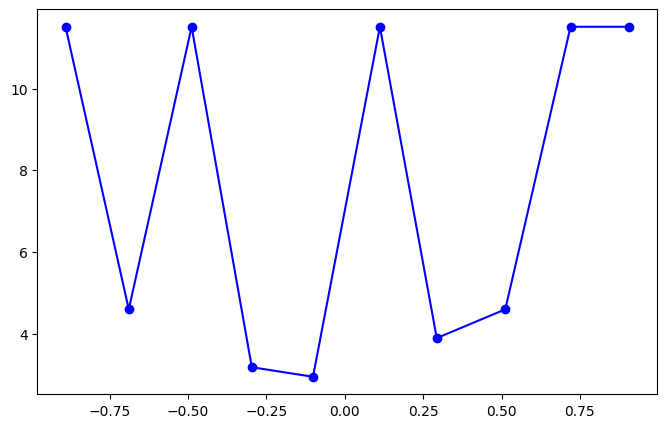

In [17]:
# let's see about adding a sqaured term.
squared = data[:, -1]**2
data_squared = np.hstack([data[:, :-1], squared.reshape(-1, 1)])
logits_squared = data_squared @ true_parameters  + np.random.normal(0, 1, (1000, 1))
labels_squared = (np.exp(logits_squared) / (1 + np.exp(logits_squared)) > 0.5).astype(int)
box_tidwell_test(data, labels_squared)

plot_binned_log_odds_with_label(data[:, 2], labels_squared)


As you can see we have a quadratic like structure which is what we expected, and the interaction has a p-value of 0.009, meaning that we detected that the log-odds are not linear in regards to feature 2.
Let's add the squared term back in and re run our tests.


--- Box-Tidwell Test for Feature 1 ---
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Bias             -5.7515      7.536     -0.763      0.445     -20.522       9.019
Feature_1       -11.9918      9.292     -1.291      0.197     -30.204       6.220
Feature_2         5.7080      2.301      2.481      0.013       1.199      10.217
Interaction_1     6.3738      5.281      1.207      0.227      -3.976      16.723

--- Box-Tidwell Test for Feature 2 ---
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Bias              3.5740      0.462      7.728      0.000       2.668       4.480
Feature_1        -0.9206      0.537     -1.716      0.086      -1.972       0.131
Feature_2       -17.3119     46.051     -0.376      0.707    -107.571      72.947
Interaction_2    1

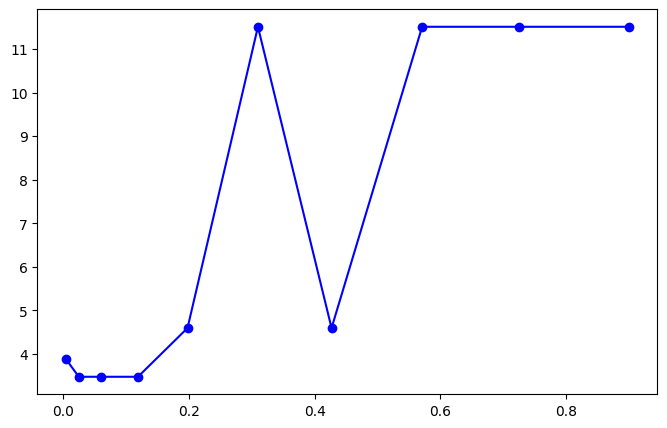

In [18]:
box_tidwell_test(data_squared, labels_squared)

plot_binned_log_odds_with_label(data_squared[:, 2], labels_squared)

As can be seen adding the square back in as the data gives us a more linear plot up to the expected saturation and box-tidwell tests indicate that the log odds are linear with respect to the features (which was a squared version of the original feature).

### No Influential Points
Negative Log Likelihood is sensitive to outliers, if a single point is very confidently wrong the penalty is -$ln(\text{small number})$, which approaches infinity, causing the coefficients to be modified drastically for a single point.
We can detect it by using using **Cook's Distance**, which estimates how wildly the coefficients would change if that specific point was removed. 

Cook's distance is a shortcut to refitting a model $N$ times and seeing how coefficients change.

**The Physics of the Pull (Newton's Method):** Under the hood, Cook's Distance calculates this shift using the physics of **Newton's Second-Order Optimization**. It calculates the distance the $\theta$ coefficients would move by applying Newton's Second Order Method's parameter update step to just the point:

$\theta_{t+1} - \theta_t = -H^{-1} \cdot g$

It's an approximation because the actual Hessian would change without that data point. 


Then a weighted norm (in whitened space) is gotten:

$D_i = \frac{1}{p} (\Delta \theta)^T \cdot \text{Var}(\hat{\theta})^{-1} \cdot (\Delta \theta)$ 

By dividing the shift by the Variance matrix, it standardizes the movement. It severely penalizes outliers that manage to move highly stable, confident coefficients, while forgiving outliers that only shift noisy, uncertain coefficients.


#### The Remedy (Handle with Care)
While the instinct is to simply drop influential points, blindly deleting data to make your model fit better is a statistical sin. When Cook's Distance flags a "black hole," you must investigate *why* it is there before acting:

1. **Is it a Typo? (Data Entry Error):** Someone's age is entered as 450 instead of 45. **Remedy:** Fix it or Drop it.
2. **Is it an Alien? (Different Population):** You are modeling middle-class incomes, and a billionaire is in your dataset. They belong to a fundamentally different data-generating process. **Remedy:** Drop it (and narrow your model's stated scope).
3. **Is it Extreme Reality? (Valid but Heavy):** The point is real; it just has a massive feature value that is dragging the curve. **Remedy:** DO NOT drop it. Apply a mathematical transformation (like taking the `log(x)`) to physically pull the extreme value back toward the center of the universe, or cap the extreme tails.


#### Process
1. Run model, get cook's distance.
2. Investigate points > 4 / N (heuristic), can we drop? Else no influential points.
3. Drop / transform feature, go to 1.

In [19]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

# 1. Generate the Normal Data (20 Students)
np.random.seed(42)
hours_studied = np.random.uniform(1, 10, 20)
# Pass if hours > 5, with a little bit of noise
pass_exam = np.where(hours_studied + np.random.normal(0, 1, 20) > 5, 1, 0)

# 2. Inject "The Alien" (Studied 15 hours, but Failed)
hours_studied = np.append(hours_studied, 15)
pass_exam = np.append(pass_exam, 0)

# Create DataFrame and add intercept
df = pd.DataFrame({'Hours': hours_studied, 'Passed': pass_exam})
df = sm.add_constant(df)

# ==========================================
# MODEL 1: BEFORE (The Black Hole Included)
# ==========================================
glm_before = sm.GLM(df['Passed'], df[['const', 'Hours']], family=sm.families.Binomial()).fit()
cooks_d_before = glm_before.get_influence().cooks_distance[0]
threshold = 4 / len(df)

print("--- BEFORE DROPPING ---")
print(f"Hours Coefficient: {glm_before.params['Hours']:.4f}")
print(f"Max Cook's D: {max(cooks_d_before):.4f} (Threshold: {threshold:.4f})")

# Find the exact row violating the threshold
outlier_index = np.where(cooks_d_before > threshold)[0]
print(f"Row {outlier_index} is pulling the model into a black hole!\n")

# ==========================================
# MODEL 2: AFTER (The Remedy)
# ==========================================
# Drop the specific outlier row identified by Cook's Distance
df_clean = df.drop(index=outlier_index)

glm_after = sm.GLM(df_clean['Passed'], df_clean[['const', 'Hours']], family=sm.families.Binomial()).fit()
cooks_d_after = glm_after.get_influence().cooks_distance[0]
new_threshold = 4 / len(df_clean)

print("--- AFTER DROPPING ---")
print(f"Hours Coefficient: {glm_after.params['Hours']:.4f}")
print(f"Max Cook's D: {max(cooks_d_after):.4f} (Threshold: {new_threshold:.4f})")

--- BEFORE DROPPING ---
Hours Coefficient: 0.4204
Max Cook's D: 2.2018 (Threshold: 0.1905)
Row [20] is pulling the model into a black hole!

--- AFTER DROPPING ---
Hours Coefficient: 1.4465
Max Cook's D: 0.6021 (Threshold: 0.2000)


### Interpreting the Results
Now that we've established the required assumptions for the model's interpretability, we can transition to statistical inference. We will look at how to calculate standard errors to build coefficient confidence intervals, derive $p$-values for hypothesis testing, and generate confidence intervals for our final predictions.

#### Standard Errors and Fisher Information
Unlike standard Linear Regression, Logistic Regression does not have a closed-form algebraic solution. Because we must find the coefficients using an iterative optimization algorithm, we cannot simply take the variance of a straightforward equation. Instead, we must derive the standard errors using the curvature of the optimization landscape (the Hessian) via the **Information Matrix Equality**.

**1. The Expected Score is Zero**
We start with the fundamental law of probability—the area under the curve is $1$:
$$\int f(x|\theta) dx = 1$$

If we take the derivative with respect to our parameters $\theta$, the constant becomes $0$:
$$\int \frac{\partial f}{\partial \theta} dx = 0$$

We then apply the **Log-Derivative Trick** ($\frac{\partial f}{\partial \theta} = f \cdot \frac{\partial \ln f}{\partial \theta}$):
$$\int f(x|\theta) \cdot \frac{\partial \ln f(x|\theta)}{\partial \theta} dx = 0$$

Because the integral of a PDF multiplied by a function is the Expected Value, we prove that the Expected Value of the Gradient (or "Score", $g$) is exactly zero:
$$E[g] = 0$$

**2. The Information Matrix Equality**
To find the variance, we take the second derivative of that same equation using the **Product Rule**:
$$\int \left[ f \cdot \frac{\partial^2 \ln f}{\partial \theta^2} + \frac{\partial f}{\partial \theta} \cdot \frac{\partial \ln f}{\partial \theta} \right] dx = 0$$

Applying the Log-Derivative trick a second time to the right-hand term:
$$\int \left[ f \cdot \frac{\partial^2 \ln f}{\partial \theta^2} + f \cdot \left(\frac{\partial \ln f}{\partial \theta}\right)^2 \right] dx = 0$$

We factor out the PDF $f(x|\theta)$ to convert the integrals back into Expected Values:
$$E\left[ \frac{\partial^2 \ln f}{\partial \theta^2} \right] + E\left[ \left(\frac{\partial \ln f}{\partial \theta}\right)^2 \right] = 0$$

Substituting our notation for the Hessian ($H$) and the Gradient ($g$):
$$E[H] + E[g^2] = 0 \implies E[g^2] = -E[H]$$

Since the variance of a variable is $E[X^2] - (E[X])^2$, and we proved $E[g] = 0$, then $E[g^2]$ is exactly the Variance of the Gradient. This yields the **Fisher Information Equality**:
$$V[g] = -E[H] = I(\theta)$$

**3. The Asymptotic Variance of the Coefficients**
To find the variance of our estimated coefficients ($\hat{\theta}$), we recognize that at the maximum likelihood estimate, the gradient is zero ($g(\hat{\theta}) = 0$). Using a Taylor Expansion (Delta Method), we can approximate the variance of the coefficients as:
$$V[\hat{\theta}] \approx V\left[ \frac{-g(\theta)}{H} \right]$$

Written in matrix algebra format:
$$V[\hat{\theta}] = H^{-1} \cdot V[g] \cdot H^{-1}$$

By substituting our Information Matrix Equality ($V[g] = -H$):
$$V[\hat{\theta}] = H^{-1} \cdot (-H) \cdot H^{-1} = -H^{-1}$$

**4. Application to Logistic Regression**
For Logistic Regression, the negative Expected Hessian (the Fisher Information Matrix) is defined algebraically as:
$$-E[H] = X^T W X$$
*(Where $W$ is a diagonal matrix of the binomial variances: $W = \text{diag}(p_i(1-p_i))$).*

Therefore, the **Variance-Covariance matrix** for our Logistic Regression coefficients is exactly the inverse Fisher Information matrix:
$$V[\hat{\theta}] = (X^T W X)^{-1}$$

To get the final Standard Errors for our summary table, we simply take the square roots of the diagonal elements of this matrix.

Let's get these on some sample data:

In [20]:
data = np.hstack([np.ones((1000, 1)), np.random.uniform(-1, 1, (1000, 2))])
logits = data @ true_parameters  + np.random.logistic(0, 1, (1000, 1))
labels = (np.exp(logits) / (1 + np.exp(logits)) > 0.5).astype(int)

params, _ = logistic_regression_solve_gradient_descent(np.random.random((3, 1)), 0.01, data=data, labels=labels)

predictions = 1 / (1 + np.exp(-data @ params))

((predictions > 0.5) == labels).mean()

np.float64(0.836)

In [21]:
W = np.diag((predictions * (1 - predictions)).reshape(-1))

In [22]:
variance = np.linalg.inv(data.T @ W @ data)
variance, params

(array([[ 0.01657658, -0.00615523,  0.01991857],
        [-0.00615523,  0.02669715, -0.01026576],
        [ 0.01991857, -0.01026576,  0.05072646]]),
 array([[ 1.99760855],
        [-1.04940232],
        [ 2.92566896]]))

In [23]:
import statsmodels.api as sm

sm_model = sm.Logit(labels, data).fit(disp=0)

sm_variance = sm_model.cov_params()

print("--- Statsmodels Variance Matrix ---")
print(np.round(sm_variance, 6))

print("\n--- Your Manual Variance Matrix ---")
print(np.round(variance, 6))

--- Statsmodels Variance Matrix ---
[[ 0.016577 -0.006155  0.019919]
 [-0.006155  0.026697 -0.010266]
 [ 0.019919 -0.010266  0.050726]]

--- Your Manual Variance Matrix ---
[[ 0.016577 -0.006155  0.019919]
 [-0.006155  0.026697 -0.010266]
 [ 0.019919 -0.010266  0.050726]]


Verifying stats models standard errors. We will now use this variance matrix to make some inferences.

#### Confidence Intervals for our Coefficients (Odds Ratios)
One could, at their own peril assume the exponentiated coefficient ($e^{\theta}$) represents the **Odds Ratio**. 
* **For a continuous feature:** It is the multiplicative change in the odds for every one-unit increase in the feature.
* **For a categorical feature:** It is the ratio of the odds compared to the baseline reference class.

**Calculating the Interval:**
Statisticians proved that as N→∞, MLE estimators automatically become Normally distributed, centered on the true parameter, with a variance equal to the Inverse Fisher Information Matrix. Because Logistic Regression relies on Maximum Likelihood Estimation (MLE), it benefits from **Asymptotic Normality**. Because we derived our Standard Errors (SE), we can construct $95\%$ confidence intervals, then lock in the odds ratio by exponentiating those bounds (since the errors are on the parameters not the odds ratio itself).

1. **Calculate the CI for the Log-Odds ($\theta$):** $$\text{CI}_{\text{Logit}} = \theta \pm (1.96 \cdot \text{SE})$$
2. **Convert to the Odds Ratio CI:** Exponentiate both the lower and upper bounds:
   $$\text{CI}_{\text{Odds}} = \left[ e^{\theta - 1.96 \cdot \text{SE}}, \ e^{\theta + 1.96 \cdot \text{SE}} \right]$$

Typical standard errors and confidence intervals:
* +/- 1 Standard error ~ 65% confidence interval
* +/- 2 Standard errors ~ 95% confidence interval
* +/- 3 standard errors ~ 99.7% confidence interval

In [24]:
standard_errors = np.sqrt(np.diag(variance))
params.reshape(-1) - 2 * standard_errors, params.reshape(-1) + 2 * standard_errors, true_parameters.reshape(-1), params.reshape(-1)

(array([ 1.74010837, -1.37618758,  2.47521827]),
 array([ 2.25510872, -0.72261705,  3.37611964]),
 array([ 2, -1,  3]),
 array([ 1.99760855, -1.04940232,  2.92566896]))

In [25]:
np.exp(params.reshape(-1) - 2 * standard_errors), np.exp(params.reshape(-1) + 2 * standard_errors), np.exp(true_parameters.reshape(-1)), np.exp(params.reshape(-1))

(array([ 5.69796089,  0.25253951, 11.88430079]),
 array([ 9.53633004,  0.48548006, 29.25702286]),
 array([ 7.3890561 ,  0.36787944, 20.08553692]),
 array([ 7.37140663,  0.35014696, 18.64669568]))

As you can see we were able to get between the confidence interval for the true parameters.
There is an issue however, consider if the noise wasn't logistic noise but instead it was normal:

In [26]:
data = np.hstack([np.ones((1000, 1)), np.random.uniform(-1, 1, (1000, 2))])
logits = data @ true_parameters  + np.random.normal(0, 1, (1000, 1))
labels = (np.exp(logits) / (1 + np.exp(logits)) > 0.5).astype(int)

params, _ = logistic_regression_solve_gradient_descent(np.random.random((3, 1)), 0.01, data=data, labels=labels)

predictions = 1 / (1 + np.exp(-data @ params))

((predictions > 0.5) == labels).mean()

np.float64(0.893)

In [27]:
sm_model = sm.Logit(labels, data).fit(disp=0)

sm_variance = sm_model.cov_params()
standard_errors = np.sqrt(np.diag(variance))
params.reshape(-1) - 2 * standard_errors, params.reshape(-1) + 2 * standard_errors, true_parameters.reshape(-1), params.reshape(-1)

(array([ 3.4438823 , -2.16647294,  5.07324471]),
 array([ 3.95888264, -1.51290241,  5.97414608]),
 array([ 2, -1,  3]),
 array([ 3.70138247, -1.83968768,  5.5236954 ]))

##### The Latent Scale Trap (Why we missed the true parameters)
Notice that our model estimated `[3.70, -1.83, 5.52]`, which completely misses our true parameters of `[2.0, -1.0, 3.0]`. It looks like the model failed, but it actually worked perfectly. 

**Why did this happen?**
In this run, we generated our data using **Normal noise** ($\sigma = 1$). However, Logistic Regression mathematically rigidly assumes the noise follows a **Logistic distribution** ($\sigma \approx 1.81$). To force our Normal data to fit its Logistic assumption, the model had to stretch our coefficients by the ratio of those standard deviations ($\approx 1.81x$):

The logistic model assumes a logistic distribution and uses the inverse CDF function of the logistic distribution (going from "log"-it space to probability space):

$$P(Y=1 | X) = \frac{1}{1 + e^{-(\theta) X}}$$

Because the model cannot observe the true physical effect ($\beta$) or the true noise ($\sigma_{\text{true}}$) separately, it is forced to estimate a single scaled parameter, $\theta$. To make its wider Logistic curve perfectly overlap our narrower Normal data, the model must mathematically multiply the true effect by the ratio of their standard deviations:

$$\theta = \beta \cdot \left(\frac{\sigma_{\text{logistic}}}{\sigma_{\text{true}}}\right)$$

Since our true noise was Normal ($\sigma_{\text{true}} = 1$) and the Logistic standard deviation is $\sigma_{\text{logistic}} \approx 1.81$, the formula collapses to:

$$\theta = \beta \cdot 1.81$$

So it cannot seperate the true coefficients from the noise itself, and all gets put into $\theta$, which we simply treat as coefficients. Notice that $2.0 \times 1.81 \approx 3.62$. The model found the exact right answer, just on an inflated scale!

Therefore in actuality coefficients individually cannot be trusted, but we can trust the relative importance of features or ratio of $\theta$ to measure how many more times one feature impacts the log-odds than another (since the ratio cancels out noise scaling).

When it comes to reporting impact, we turn to a more robust tool (that isn't impacted by noise in this determental way) called AME or Average Marginal Effects.

#### Average Marginal Effects
To bypass the latent scale and translate our coefficients into an actionable business metric, we calculate the **Average Marginal Effect**. 

Instead of dealing with "Log-Odds," we take the calculus derivative of the Sigmoid function with respect to our feature $X$. This gives us the instantaneous rate of change in probability ($\Delta P$). 

$$\frac{\partial P}{\partial X_k} = P \cdot (1 - P) \cdot \theta_k$$

Because this effect changes depending on where a person is on the S-Curve, we calculate this derivative for *every single observation* in our dataset, and then take the mean. 
*(Notice that because we use the model's final probabilities $P$, which are immune to the scale problem, the AME safely collapses the inflated $\theta$ back into absolute reality).*


In [28]:
(predictions * (1 - predictions) * params.T).mean(axis=0)

array([ 0.28835159, -0.14331858,  0.43031661])

So on average a unit increase in our first feature (coefficient of -1) is associated with an 11 percentage point decrease, and a unit increase in our second feature (coefficient 3) is associated with a 39.5 increase of percentage points.

### Significance Tests
Significance tests and their p-values are hypothesis testing, where the null hypothesis is that the coefficient is 0 (that is has no association with the output) and the alternative hypothesis is that it does ($\theta \neq 0$).

We assume the normal distribution (Central Limit Theorem) cenetered at the true values for the coefficients and use our observed variance to see whats the chance given the null is true to observe the coefficients we got and the p-value is the chance of seeing that data or higher.

Given the previous failure to draw out true interpertable coefficients, are then significance tests whereby we see whether feature is significant or not ruined?
No - Because the latent noise scales *both* the coefficient ($\theta$) and the Standard Error ($SE$) by the exact same amount, the scale factor cancels out when we calculate our Z-statistic ($Z = \frac{\theta \cdot 1.81}{SE \cdot 1.81}$). Therefore, **our p-values and statistical significance remain 100% accurate.**

In [29]:
import numpy as np

z_scores = params.reshape(-1) / standard_errors
print(z_scores)

import scipy.stats as stats

2*(1 - stats.norm.cdf(np.abs(z_scores)))

[ 28.74858236 -11.25930624  24.52519466]


array([0., 0., 0.])

In [30]:
data = np.hstack([np.ones((1000, 1)), np.random.uniform(-1, 1, (1000, 2))])
logits = data @ true_parameters  + np.random.logistic(0, 1, (1000, 1))
labels = (np.exp(logits) / (1 + np.exp(logits)) > 0.5).astype(int)

params, _ = logistic_regression_solve_gradient_descent(np.random.random((3, 1)), 0.01, data=data, labels=labels)

predictions = 1 / (1 + np.exp(-data @ params))

print(((predictions > 0.5) == labels).mean())

variance = np.linalg.inv(data.T @ W @ data)
print(variance, params)
standard_errors = np.sqrt(np.diag(variance))

0.833
[[ 0.00860165 -0.0001192   0.00085834]
 [-0.0001192   0.02581568  0.00111292]
 [ 0.00085834  0.00111292  0.02562909]] [[ 2.05502312]
 [-1.32814282]
 [ 3.08889841]]


In [31]:
import numpy as np

z_scores = params.reshape(-1) / standard_errors
print(z_scores)

import scipy.stats as stats

2*(1 - stats.norm.cdf(np.abs(z_scores)))

[22.15775905 -8.26614525 19.29465589]


array([0.00000000e+00, 2.22044605e-16, 0.00000000e+00])

Effectively 0% chance of seeing the data if the coefficients were 0! We see very similiar z-scores irregardless of the noise.

### Output Confidence Intervals
We can build confidence intervals on the output and because we transform it to the probability space, it bypasses latent noise concerns of interpreting coefficients directly, since we pass it through the sigmoid.

As we saw the variance of the output is directly tied to the variance of the coefficients:

$$ V[\hat{y}] = \vec{x}V[\hat{\theta}]\vec{x}^T $$

In [32]:
predictions = 1 / (1 + np.exp(-data @ params))

W = np.diag((predictions * (1 - predictions)).reshape(-1))

variance = np.linalg.inv(data.T @ W @ data)
variance, params

(array([[ 0.01873123, -0.00757148,  0.02299649],
        [-0.00757148,  0.02978673, -0.0100755 ],
        [ 0.02299649, -0.0100755 ,  0.05349382]]),
 array([[ 2.05502312],
        [-1.32814282],
        [ 3.08889841]]))

In [33]:
example_point = np.array([[1,.1,.1]])
se = np.sqrt(example_point @ variance @ example_point.T).reshape(-1)

lower, higher = example_point @ params + 2 * se, example_point @ params - 2 * se
1 / (1 + np.exp(-lower)), 1 / (1 + np.exp(-higher))

(array([[0.9262695]]), array([[0.87340968]]))

### Predictive Power
In the previous sections, we focused entirely on **Inference**—tearing apart the mathematical engine to understand exactly *why* features impact our target. Now, we pivot to the second culture of statistical modeling: **Prediction**. Here, our primary objective is strictly to maximize the model's out-of-sample performance on unseen data.

While modern Machine Learning is dominated by highly parameterized models (like Gradient Boosting or Deep Learning), these complex algorithms are incredibly susceptible to overfitting—especially when data is limited. Logistic Regression provides two massive predictive advantages:

1. **The Bias-Variance Tradeoff:** Logistic Regression introduces a strong inductive bias (the rigid assumption of linearity in the Log-Odds). When dealing with noisy or limited data, this high bias acts as a natural anchor, drastically reducing model variance and preventing severe overfitting.
2. **The Ultimate Baseline:** Model complexity comes with heavy computational, deployment, and maintenance costs. Logistic Regression is computationally lightning-fast and serves as the industry-standard baseline. It defines the performance-complexity floor: if a massive, expensive neural network cannot significantly outperform this logistic baseline, the complex model is discarded.

To optimize this model for predictive power, we will apply methods for estimating True Risk (our out of sample error), and explore mathematical techniques to explicitly control the bias-variance tradeoff within the logistic framework itself to maximize the out-of-sample performance (or reduction of true risk).

### Estimating Out-of-Sample Performance
See the [README.md file](../../../../README.md) at the root of the repository for a discussion around estimating the risk or it's inverse out of sample performance. Because computationally logistic regression is low parameter model that can be computed easily, K-fold validation is the gold standard for it a validation set risk estimator for tuning and model selection.

In [34]:
from typing import Protocol, Callable, Any
import numpy as np

class Estimator(Protocol):
    def fit(self, X: np.ndarray, Y: np.ndarray) -> Any:
        ...
    def predict(self, X: np.ndarray) -> np.ndarray:
        ...

class MetricValidator(Protocol):
    def __call__(self, y_true: np.ndarray, y_pred: np.ndarray):
        ...

def perform_k_fold_validation(estimator: Estimator, data: np.ndarray, k: int, validator: MetricValidator) -> Any:
    '''
    Assumes last column on axis == 1 is label
    Assumes you're passing in entire dataset
    '''
    folds = np.array_split(data, k, axis=0)
    scores = {}
    for fold_index in range(k):
        training = np.concat(folds[:fold_index] + folds[fold_index + 1:])
        validation = folds[fold_index]
        estimator.fit(training[:, :-1], training[:, -1])
        estimates = estimator.predict(validation[:, :-1])
        score = validator(validation[:, -1], estimates)
        scores[fold_index] = score
    return scores

In [35]:
class LogisticRegression(Estimator):
    ''' Expects bias in first column == 1'''
    def __init__(self):
        self.params = None
    def fit(self, X: np.ndarray, Y: np.ndarray):
        self.params, _ = logistic_regression_solve_gradient_descent(np.random.random((X.shape[1], 1)), 0.1, X, Y.reshape(-1, 1))
    def predict(self, X: np.ndarray):
        if self.params is None:
            raise Exception("Model needs to be .fit first!")
        return 1 / ( 1 + np.exp(-X @ self.params))

def accuracy(y_true: np.ndarray, y_estimated: np.ndarray):
    return ((y_estimated.squeeze() > 0.5) == y_true).mean()

In [36]:
samples = np.random.uniform(-1, 1, (1000, 3))
samples = np.concat([np.ones((1000, 1)), samples], axis=1)
true_params = np.array([3, 1, -2, -3]).T
labels = (1 / (1 + np.exp(-(samples @ true_params + np.random.normal(0, .5, size=(1000)))))> 0.5) * 1
labels.mean()

np.float64(0.899)

In [37]:
data = np.concat([samples, labels.reshape(-1,1)], axis=1)
logistic_estimator = LogisticRegression()
k_scores = perform_k_fold_validation(logistic_estimator, data, 10, accuracy)

In [38]:
np.mean([v for k,v in k_scores.items()]), k_scores

(np.float64(0.952),
 {0: np.float64(0.94),
  1: np.float64(0.97),
  2: np.float64(0.97),
  3: np.float64(0.93),
  4: np.float64(0.95),
  5: np.float64(0.98),
  6: np.float64(0.96),
  7: np.float64(0.99),
  8: np.float64(0.92),
  9: np.float64(0.91)})

So ~96% in this case is the expected accuracy for new data using this set up since we didnt do any feature selection or model selection.

## Balancing the Bias-Variance Tradeoff in Logistic Regression

As established in the [repository root README](../../../../README.md), a model's generalization error can be mathematically decomposed into **Bias** (the rigidity of the model's assumptions) and **Variance** (its sensitivity to the specific training data). 

To extract the maximum predictive power from Logistic Regression, we can apply specific mathematical techniques to explicitly control this tradeoff. We will use **K-Fold Cross-Validation** to evaluate how these different modeling choices affect the model's bias and variance, allowing us to find the exact configuration that maximizes out-of-sample performance.

Because we are using cross-validation to tune these techniques (hyperparameter tuning), we are actively introducing **optimism bias** into our validation scores. Once we find the optimal configuration, we must retrain the final model on the entire working dataset and evaluate it against a locked **Test Set** to obtain a mathematically pure, unbiased estimate of the True Expected Risk.

As also discussed in the [repository root README](../../../../README.md), we can look at regularization (increasing the bias) as a Maximum A Posteriori Estimate (MAP) instead of a Maximum Likelihood Estimate (MLE), where we have a specific (non flat) prior.

Also as discussed in the [repository root README](../../../../README.md) we look at basis expansion as fundamentally altering our core structural assumption to reduce bias and increase variance. Standard logistic regression strictly assumes the log-odds are a linear combination of the inputs (XΘ). By projecting our features into a higher-dimensional space ϕ(X)—using techniques like Natural Cubic Splines or adding polynomial terms —we mathematically relax this rigid assumption. Statistically, we are expanding our hypothesis space, allowing the likelihood function to capture complex, non-linear realities in the data-generating process. If regularization is our brake pedal (increasing bias to prevent overfitting), basis expansion is our gas pedal (increasing variance to prevent underfitting).

### Regularization

We do regularization for feature coefficients, not the bias because the bias is how the model represents the base rate or the class imbalance, and a prior of zero says they're balanced, which is almost never the case.

Standardizing the input features is essential because the regularization prior blindly penalizes coefficient magnitudes. Without scaling, the penalty unfairly attacks weights that are naturally large just because their corresponding features use small numerical units. By transforming all features to the same scale, the prior becomes logical—forcing the penalty to shrink weights based on their actual predictive importance. Additionally, standardization provides major optimization benefits: it equalizes the feature variances, making the loss landscape isotropic (symmetric). This allows gradient descent to traverse the space efficiently, stepping smoothly and directly toward the minimum instead of zigzagging through a distorted valley.

Our regular MLE estimate (corresponds to flat improper prior):
$$
\text{MLE} = argmax_{\theta}(\prod_{i=1}^{N}P(y_i |\vec{x}_i,\theta))
$$

The MAP estimate:
$$
\text{MAP} = argmax_{\theta}(\prod_{i=1}^{N}P(y_i |\vec{x}_i,\theta) * P(\theta))
$$

Two common choices for the prior lead to these two different types of regularization:

#### L2 Regularization (Ridge)

If we assume a zero-centered **Matrix Normal prior** on the model weights (we inherently believe they should be close to zero), and assume they are independent and homoscedastic across both features and classes, we get L2 Regularization:

$$
\text{MAP} = \arg\max_{\mathbf{\Theta}}\left(\prod_{i=1}^{N}P(y_i \mid \vec{x}_i, \mathbf{\Theta}) \cdot \text{pdf}_{\mathcal{MN}}(\mathbf{\Theta})\right)
$$

We apply a rank-preserving (monotonic) natural logarithm transformation to prevent computational underflow and ensure gradient health 💫 :

$$
\begin{aligned}
\text{MAP} &= \arg\max_{\mathbf{\Theta}}\left(\sum_{i=1}^{N}\ln(P(y_i \mid \vec{x}_i, \mathbf{\Theta})) + \ln(\text{pdf}_{\mathcal{MN}}(\mathbf{\Theta}))\right) \\
\text{MAP} &= \arg\max_{\mathbf{\Theta}}\left(\sum_{i=1}^{N}\ln(P(y_i \mid \vec{x}_i, \mathbf{\Theta})) - \frac{1}{2} \text{Tr}(\mathbf{\Theta}^T\Sigma^{-1}\mathbf{\Theta}) + \text{constants}\right)
\end{aligned}
$$

*(Note: Because $\mathbf{\Theta}$ is a $P \times C$ matrix, $\mathbf{\Theta}^T\Sigma^{-1}\mathbf{\Theta}$ results in a $C \times C$ matrix. The Matrix Normal distribution uses the **Trace operator** ($\text{Tr}$) to sum the diagonal of this matrix, mathematically collapsing the penalty down into a valid scalar).*

If we put a negative in front of the expression, we can frame it as minimizing our modified Expected Risk (Negative Log-Likelihood + Penalty). Assuming independent and homoscedastic variance ($\Sigma = \sigma^2 \mathbf{I}$), the trace simplifies beautifully: $\text{Tr}(\mathbf{\Theta}^T \mathbf{\Theta})$ is mathematically identical to the sum of all squared elements, known as the **squared Frobenius norm** ($\|\mathbf{\Theta}\|_F^2$).

$$
\text{NLL} = -\sum_{i=1}^{N} \vec{y}_i^T \ln(\vec{p}(\vec{x}_i)) + \frac{\lambda}{2} \|\mathbf{\Theta}_{\text{masked}}\|_F^2
$$

*Where:*
* $\lambda$ (Lambda) is our hyperparameter controlling the strength of the penalty — it is mathematically equal to $\frac{1}{\sigma^2}$.
* $\|\mathbf{\Theta}_{\text{masked}}\|_F^2$ is the squared Frobenius norm of the feature weights. Crucially, this matrix **masks out the intercept ($\theta_0$) row**. Penalizing the intercept would improperly force the model's baseline prediction toward 50%, destroying its ability to handle imbalanced base rates.

**The Gradient:**
To maintain dimensional alignment during gradient descent, we define $\mathbf{\Theta}_{\text{masked}}$ as our $P \times C$ parameter matrix where the top row (the intercepts) is replaced with 0s. 

For the Multi-Class (Multinomial) case, the gradient becomes the sum of the outer products of our features and prediction errors:

$$
\nabla_{\mathbf{\Theta}} \text{NLL} = \sum_{i=1}^N \left( \vec{x}_i ( \vec{p}(\vec{x}_i) - \vec{y}_i)^T \right) + \lambda \mathbf{\Theta}_{\text{masked}}
$$

This formulation elegantly updates each of the weights. For every sample, computing the outer product between the feature vector ($P \times 1$) and the prediction error vector ($1 \times C$) yields a $P \times C$ matrix. The error for each class scales the feature vector, determining the exact directional adjustment needed for that class's weights. We then sum these contributions across all $N$ data points.

**The Fully Vectorized Form:**
We can vectorize this completely by eliminating the summation loop and computing the entire dataset simultaneously using matrices:

$$
\nabla_{\mathbf{\Theta}} \text{NLL} = \mathbf{X}^T (\mathbf{P}(\mathbf{X}) - \mathbf{Y}) + \lambda \mathbf{\Theta}_{\text{masked}}
$$

In this highly optimized operation, $\mathbf{X}^T$ is $(P \times N)$ and the prediction error matrix is $(N \times C)$. The inner $N$ dimension collapses during matrix multiplication, naturally summing the error-weighted features across all samples and returning the final $P \times C$ gradient matrix in a single step!

In [39]:
import numpy as np

def softmax_risk_overflow(x, params):
    '''
    softmax with a risk of overflow
    params: (C x P) matrix
    x: (N x P) matrix
    '''
    x = x @ params.T
    x = np.exp(x)
    sums = np.sum(x, axis=1).reshape(-1, 1)
    x /= sums
    return x

def softmax_safe(x, params):
    '''
    safe softmax, subtracting the max
    params: (C x P) matrix
    x: (N x P) matrix
    '''
    x = x @ params.T
    x -= np.max(x, axis=1).reshape(-1, 1)
    x = np.exp(x)
    sums = np.sum(x, axis=1).reshape(-1,1)
    x /= sums
    return x

def softmax_safe_noise(x, params, scale=1):
    '''
    safe softmax, subtracting the max
    params: (C x P) matrix
    x: (N x P) matrix
    '''
    x = x @ params.T + np.random.normal(scale=scale, size=(x.shape[0], params.shape[0]))
    x -= np.max(x, axis=1).reshape(-1, 1)
    x = np.exp(x)
    sums = np.sum(x, axis=1).reshape(-1,1)
    x /= sums
    return x


def solve_l2_logistic_regression(params, x, y, l2_penalty=0.01, max_iter=1e5, learning_rate=1e-1):
    '''
    params: (C x P) matrix
    x: (N x P) matrix
    y: (N x C) matrix
    '''
    gradient = [np.inf]
    i = 0
    while np.linalg.norm(gradient) > 0.0001 and i < max_iter:
        estimates = softmax_safe(x, params)
        masked_params = np.zeros_like(params)
        masked_params[:, 1:] = params[:, 1:]
        gradient = (estimates - y).T @ x / float(estimates.shape[0]) + l2_penalty * masked_params # dividing by N for average risk does not change the argmin and helps keep penalties and learning rate from being dataset size dependent. 
        params -= gradient * learning_rate
        i += 1
    return params



In [40]:
dataset = np.ones(shape=(1000, 5))
dataset[:, 1:] = np.random.uniform(-3, 3, (1000, 4))
true_parameters = np.array([[-8, 6, -9, 10, 3], [-5, 6, 7, -8, 9], [6, -4, -3, 4, 8]]) # bias first column

distributions = softmax_safe(dataset, true_parameters)

np.unique_counts(distributions.argmax(axis=1))

UniqueCountsResult(values=array([0, 1, 2]), counts=array([232, 357, 411]))

Not a bad distribution across 3 classes.

In [41]:
y = np.eye(3, dtype=int)[distributions.argmax(axis=1)] # selects eye row over and over again! so cool!
print(y.shape)


(1000, 3)


In [42]:
estimated_parameters = solve_l2_logistic_regression(np.random.random(size=(true_parameters.shape)), dataset, y, 0)
estimated_distributions = softmax_safe_noise(dataset, estimated_parameters, scale=8)
estimated_labels = estimated_distributions.argmax(axis=1)
(estimated_labels == distributions.argmax(axis=1)).mean()

np.float64(0.865)

In [43]:
k_scores

{0: np.float64(0.94),
 1: np.float64(0.97),
 2: np.float64(0.97),
 3: np.float64(0.93),
 4: np.float64(0.95),
 5: np.float64(0.98),
 6: np.float64(0.96),
 7: np.float64(0.99),
 8: np.float64(0.92),
 9: np.float64(0.91)}

In [44]:
class RegularizedLogisticRegression(Estimator):
    def __init__(self, l2_penalty, num_classes):
        self.params = None
        self.l2_penalty = l2_penalty
        self.num_classes = num_classes

    def fit(self, X: np.ndarray, Y: np.ndarray):
        ''' Expects bias in first column == 1'''
        Y = np.eye(self.num_classes, dtype=int)[Y.astype(int)] 
        self.params = solve_l2_logistic_regression(np.random.random(size=(self.num_classes, X.shape[1])), X, Y, self.l2_penalty)

    def predict(self, X: np.ndarray):
        ''' Expects bias in first column == 1'''
        if self.params is None:
            raise Exception("Model needs to be .fit first!")
        return softmax_safe(X, self.params).argmax(axis=1)

def accuracy(y_true: np.ndarray, y_estimated: np.ndarray):
    return (y_estimated== y_true).mean()

In [45]:
### we will now split our dataset and perform k-fold validation and grid search to find the ideal l2_penalty and test it on the test set drawn from our noisy labels
train_samples = dataset[:800]
train_var = np.var(train_samples, axis=0)
train_mean = np.mean(train_samples, axis=0)

train_samples[:, 1:] = (train_samples [:, 1:] - train_mean[1:]) / np.sqrt(train_var[1:] + 0.01)

train_labels = estimated_distributions.argmax(axis=1)[:800]

test_samples = dataset[800:]
test_samples[:, 1:]  = (test_samples[:, 1:]  - train_mean[1:]) / np.sqrt(train_var[1:] + 0.01)
test_labels = estimated_distributions.argmax(axis=1)[800:]

regularized_logistic_estimator = RegularizedLogisticRegression(0, 3)

k_scores = perform_k_fold_validation(regularized_logistic_estimator, np.concat([train_samples, train_labels.reshape(-1, 1)], axis=1), 10, accuracy)

In [46]:
def grid_search(estimator_params, data, estimator, metric):
    best = None
    best_val = -np.inf
    for estimator_param in estimator_params:
        regularized_logistic_estimator = estimator(**estimator_param)
        k_scores = perform_k_fold_validation(regularized_logistic_estimator, data, 5, metric)
        mean_score = np.mean([v for k,v in k_scores.items()])
        if mean_score > best_val:
            best = estimator_param
            best_val = mean_score
    return best, best_val

best_args, score, = grid_search([{"l2_penalty": v, "num_classes": 3} for v in np.logspace(-4, 3, 10)], np.concat([train_samples, train_labels.reshape(-1, 1)], axis=1), RegularizedLogisticRegression, accuracy)



/tmp/ipykernel_83629/2426701118.py:54: RuntimeWarning: overflow encountered in multiply
  gradient = (estimates - y).T @ x / float(estimates.shape[0]) + l2_penalty * masked_params # dividing by N for average risk does not change the argmin and helps keep penalties and learning rate from being dataset size dependent.
/tmp/ipykernel_83629/2426701118.py:21: RuntimeWarning: invalid value encountered in matmul
  x = x @ params.T
/tmp/ipykernel_83629/2426701118.py:22: RuntimeWarning: invalid value encountered in subtract
  x -= np.max(x, axis=1).reshape(-1, 1)


In [47]:
best_args, score

({'l2_penalty': np.float64(0.003593813663804626), 'num_classes': 3},
 np.float64(0.8600000000000001))

In [48]:
regularized_logistic_estimator = RegularizedLogisticRegression(**best_args)
regularized_logistic_estimator.fit(train_samples, train_labels)

estimates = regularized_logistic_estimator.predict(test_samples)
(estimates == test_labels).mean()

np.float64(0.895)


#### L1 Regularization (Lasso)

While L2 Regularization smoothly shrinks all coefficients toward zero, it rarely forces them to exactly zero. If our dataset contains hundreds of noisy, irrelevant features, L2 will keep them all around as tiny decimals, which still adds slight variance to the model.

To induce sparsity (automatic feature selection), we swap our Gaussian prior for a **Laplace prior**. The Laplace distribution has a much sharper peak at zero and heavier tails. 

Assuming our feature weights are independent and identically distributed under a zero-centered Laplace distribution with scale parameter $b$:

$$
\text{MAP} = \arg\max_{\theta}\left(\prod_{i=1}^{N}P(y_i \mid \vec{x}_i, \theta) \cdot \prod_{j=1}^{F} \frac{1}{2b} \exp\left(-\frac{|\theta_j|}{b}\right) \right)
$$

By the rules of exponents, the product of the Laplace priors becomes a sum inside a single exponential. When we apply the natural logarithm transformation, the exponential cancels out entirely:

$$
\text{MAP} = \arg\max_{\theta}\left(\sum_{i=1}^{N}\ln(P(y_i \mid \vec{x}_i, \theta)) - \frac{1}{b} \sum_{j=1}^F |\theta_j| + \text{constants}\right)
$$

Multiplying by $-1$ to convert this to our modified Expected Risk (Negative Log-Likelihood + Penalty), we obtain **L1 Regularization (Lasso)**:

$$
\text{NLL} = -\sum_{i=1}^{N} \vec{y}_i^T \ln(\vec{p}(\vec{x}_i)) + \lambda \|\vec{\theta}_{\text{masked}}\|_1
$$

Or fully vectorized:

$$
\text{NLL} = - \text{Tr}[\mathbf{Y}^T \cdot ln(\text{SM}(\mathbf{X} \Theta , \text{axis=1}))] + \lambda \| \Theta_{masked} \|_1
$$

*Where:*
* $\lambda$ corresponds to $\frac{1}{b}$.
* $\|\vec{\theta}_{\text{masked}}\|_1$ is the **L1 Norm** (the sum of the absolute values) of the feature weights, explicitly masking out (ignoring) the intercept $\theta_0$.


In this case the gradient becomes:

$$
\nabla_{\Theta} \text{NLL}_{\text{unregularized}} = \mathbf{X}^T(\mathbf{P} - \mathbf{Y})
$$

To apply the $L_1$ penalty, we might intuitively add its derivative: $\lambda \cdot \text{sign}(\Theta_{\text{masked}})$. 

However, because the slope of the absolute value is technically undefined at $0$, using the raw `sign` operator creates a constant force that causes the weights to violently oscillate back and forth across $0$, never achieving true sparsity.

To solve this and prevent thrashing, solvers abandon the raw derivative and instead use a two-step process called **Proximal Gradient Descent** (specifically applying **Soft Thresholding**).

**Step 1: The Unregularized Update**
First, we calculate where the weight *wants* to go based strictly on the data loss, producing an intermediate weight matrix:

$$
\Theta_{\text{temp}} = \Theta_{\text{old}} - \alpha \cdot \nabla_{\Theta} \text{NLL}_{\text{unregularized}}
$$

**Step 2: The Soft Thresholding Step**
Next, we apply the $L_1$ penalty by softly shrinking the magnitude of that intermediate weight. If the penalty is larger than the weight's magnitude, it is safely clamped to exactly $0$:

$$
\Theta_{\text{new}} = \text{sign}(\Theta_{\text{temp}}) \max(0, |\Theta_{\text{temp}}| - \tau)
$$

*Where $\tau = \alpha \lambda$ (the regularization strength $\lambda$ explicitly scaled by the learning rate $\alpha$).*


**The Geometric Advantage (Sparsity):**
Because the derivative of an absolute value is a constant (rather than shrinking proportionally to the weight's size like in L2), the L1 penalty aggressively drives the coefficients of less important features to exactly `0.0`. 

This yields a *sparse* model. It acts as an algorithmic bouncer, explicitly telling the business which features actually matter and which can be safely dropped from the data engineering pipeline.

If we look at the geometry of Logistic Regression, the unregularized optimization space is a convex bowl where concentric, elliptical contour lines represent areas of equal loss. 

Regularization can be viewed through Lagrangian Duality as a hard geometric constraint—a physical boundary centered at the origin that the optimizer cannot step outside of. The two penalties create fundamentally different constraint shapes:

* **$L_2$ Regularization (Ridge):** $w_1^2 + w_2^2 \le t$. This forms a smooth **Circle** (or Hypersphere).
* **$L_1$ Regularization (Lasso):** $|w_1| + |w_2| \le t$. This forms a sharp **Diamond** (or Cross-Polytope) with vertices lying exactly on the coordinate axes.

**The Sparsity Collision:**
The optimizer must find the point where the expanding elliptical loss contours first touch the constraint boundary. 
Because the $L_1$ diamond has sharp corners that jut out precisely along the axes, the expanding contour is overwhelmingly likely to intersect the constraint exactly at a corner. Hitting a corner means the parameter on the opposite axis is exactly $0.0$, yielding a sparse configuration. 

In contrast, the $L_2$ circle has no corners. The expanding contours will almost always touch the smooth curved edge, effectively shrinking the magnitude of all weights, but rarely forcing any of them to exactly zero.



In [49]:
def solve_l1_logistic_regression(params, x, y, l1_penalty=0.01, max_iter=1e5, learning_rate=1e-1, tol=1e-4):
    '''
    params: (C x P) matrix
    x: (N x P) matrix
    y: (N x C) matrix
    '''
    gradient = [np.inf]
    i = 0
    while i < max_iter:
        estimates = softmax_safe(x, params)
        gradient = (estimates - y).T @ x / float(estimates.shape[0])
        params_old = params.copy()
        params -= gradient * learning_rate
        # soft thresholding
        weights = params[:, 1:]
        params[:, 1:] = np.sign(weights) * np.maximum(0, np.abs(weights) - learning_rate * l1_penalty)
        if np.linalg.norm(params - params_old) < tol:
            break
        i += 1
    return params

In [50]:
class RegularizedL1LogisticRegression(Estimator):
    def __init__(self, l1_penalty, num_classes):
        self.params = None
        self.l1_penalty = l1_penalty
        self.num_classes = num_classes

    def fit(self, X: np.ndarray, Y: np.ndarray):
        ''' Expects bias in first column == 1'''
        Y = np.eye(self.num_classes, dtype=int)[Y.astype(int)] 
        self.params = solve_l1_logistic_regression(np.random.random(size=(self.num_classes, X.shape[1])), X, Y, self.l1_penalty)

    def predict(self, X: np.ndarray):
        ''' Expects bias in first column == 1'''
        if self.params is None:
            raise Exception("Model needs to be .fit first!")
        return softmax_safe(X, self.params).argmax(axis=1)

In [51]:

best_args, score, = grid_search([{"l1_penalty": v, "num_classes": 3} for v in np.logspace(-4, 3, 10)], np.concat([train_samples, train_labels.reshape(-1, 1)], axis=1), RegularizedL1LogisticRegression, accuracy)

In [52]:
best_args, score


({'l1_penalty': np.float64(0.0001), 'num_classes': 3},
 np.float64(0.8587499999999999))

In [53]:
regularized_logistic_estimator = RegularizedL1LogisticRegression(**best_args)
regularized_logistic_estimator.fit(train_samples, train_labels)
estimates = regularized_logistic_estimator.predict(test_samples)
(estimates == test_labels).mean()

np.float64(0.875)

In [54]:
model = RegularizedL1LogisticRegression(num_classes=3, l1_penalty=100)
model.fit(train_samples, train_labels)

In [55]:
model.params

array([[-0.17249134,  0.        , -0.        ,  0.        , -0.        ],
       [ 0.22647389,  0.        ,  0.        , -0.        ,  0.        ],
       [ 0.40048853, -0.        , -0.        ,  0.        ,  0.        ]])

### Basis Expansion: Natural Cubic Splines
In this section, we will perform basis expansion using a **Natural Cubic Spline** for each continuous feature. This technique is highly effective when the strict *linear log-odds assumption* of standard logistic regression is violated. Splines can adapt to a vast variety of non-linear relationships; in fact, under a penalized sum-of-squares loss function, they are mathematically proven to be the optimal global interpolator. 

The primary limitation of this 1D spline method is that it does not natively capture interactions between different features. It assumes the non-linear effects of each feature are strictly additive. To model feature dependencies, explicit interaction terms (e.g., $x_1 \times x_2$) must be added to the design matrix separately.

Fundamentally, a cubic spline is a piecewise third-degree polynomial divided by a series of breakpoints called **knots**. They are engineered for perfect smoothness, guaranteeing that the function value, its first derivative (slope), and its second derivative (curvature) remain perfectly continuous across every knot. 

What makes a spline **Natural** is an additional boundary constraint: the function is forced to become completely linear beyond the outermost boundary knots. This critical constraint prevents the wild, high-variance tail oscillations (Runge's phenomenon) that typically plague standard polynomial expansion, allowing us to safely model complex curves in the center of our data distribution.

The underlying mathematics of constructing the spline basis matrix using truncated power functions is in supporting documentation in [the natural cubic splines notebook](../../../../feature-engineering/natural_cubic_splines.ipynb).

In this section we will use sci-kit learn's implementation here to show how with a highly non linear log odds relationship with its label (and non-independent features) can benefit from basis expansion (via natural cubic spline and tensor product spline).

In [56]:
import numpy as np
bias_coefficients_non_linear = np.array([[3, -6, 8], [7, 10, -20], [-3, 2, 1]])
dataset = np.ones(shape=(1000,3))
dataset[:, 1:] = np.random.uniform(-1, 1, (1000, 2))

scores = np.exp(np.cos(dataset @ bias_coefficients_non_linear))

scores_sum = scores.sum(axis=1, keepdims=True)

scores /= scores_sum

labels = np.argmax(scores, axis=1)
np.unique_counts(labels)

UniqueCountsResult(values=array([0, 1, 2]), counts=array([333, 324, 343]))

In [57]:
logistic_estimator = RegularizedLogisticRegression(num_classes=3, l2_penalty=0)

logistic_estimator.fit(dataset, labels)

(logistic_estimator.predict(dataset) == labels).mean()

np.float64(0.335)

As we can see a simple softmax model lacks the power to even overfit.

In [58]:
from sklearn.preprocessing import SplineTransformer

x_features = dataset[:800, 1:]
spline_builder = SplineTransformer(n_knots=800, degree=3, extrapolation='linear', include_bias=False)
x_expanded = spline_builder.fit_transform(x_features)
dataset_spline = np.concat([np.ones((800, 1)), x_expanded], axis=1)

spline_estimator = RegularizedL1LogisticRegression(num_classes=3, l1_penalty=0.00025)
spline_estimator.fit(dataset_spline, labels[:800])

# 6. Score it!
spline_accuracy = (spline_estimator.predict(dataset_spline) == labels[:800]).mean()
print(f"Spline Accuracy: {spline_accuracy:.3f}")

Spline Accuracy: 0.971


In [59]:
x_features = dataset[800:, 1:]
x_expanded = spline_builder.transform(x_features)
dataset_spline = np.concat([np.ones((200, 1)), x_expanded], axis=1)
spline_accuracy = (spline_estimator.predict(dataset_spline) == labels[800:]).mean()
print(f"Val Spline Accuracy: {spline_accuracy:.3f}")

Val Spline Accuracy: 0.475


So we get some improvement from just a 1d expansion of each feature, now what if we cross our new features together, so the localized model captures localized interactions? This is called a tensor spline:

In [60]:
from sklearn.preprocessing import SplineTransformer, PolynomialFeatures

X_features = dataset[:800, 1:]

spline_builder = SplineTransformer(n_knots=20, degree=3, extrapolation="linear", include_bias=False)
X_spline = spline_builder.fit_transform(X_features) 


tensor_builder = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_tensor = tensor_builder.fit_transform(X_spline)

dataset_tensor_spline = np.concat([np.ones((800, 1)), X_tensor], axis=1)


tensor_estimator = RegularizedL1LogisticRegression(num_classes=3, l1_penalty=0)
tensor_estimator.fit(dataset_tensor_spline, labels[:800])

tensor_accuracy = (tensor_estimator.predict(dataset_tensor_spline) == labels[:800]).mean()
print(f"Tensor Spline Matrix Shape: {dataset_tensor_spline.shape}")
print(f"Ultimate Tensor Spline Accuracy: {tensor_accuracy:.3f}")

Tensor Spline Matrix Shape: (800, 904)
Ultimate Tensor Spline Accuracy: 0.980


In [61]:
x_features = dataset[800:, 1:]
x_expanded = spline_builder.transform(x_features)
x_expanded = tensor_builder.transform(x_expanded)
dataset_spline = np.concat([np.ones((200, 1)), x_expanded], axis=1)
spline_accuracy = (tensor_estimator.predict(dataset_spline) == labels[800:]).mean()
print(f"Val Spline Accuracy: {spline_accuracy:.3f}")

Val Spline Accuracy: 0.855


As demonstrated above, a standard 1D spline basis expansion fails to capture the true underlying data-generating process. Even when pushing the model to a extreme degrees of freedom ($n_{\text{knots}} = 800$), the 1D splines are structurally constrained to bend strictly along independent axes. This forces the model to violently overfit the training partitions ($97.0\%$) while completely failing to generalize to unseen validation data ($42.0\%$). 

To resolve this without transitioning to a non-linear classifier, we construct a **Tensor Product Spline**. By extracting a conservative number of localized 1D basis functions ($n_{\text{knots}} = 20$) and computing their pairwise cross-products using polynomial basis features, we map every localized interval of $x_1$ directly against every localized interval of $x_2$. 

This expands our feature space into a comprehensive 2D coordinate surface (resulting in an $800 \times 904$ design matrix), granting the linear model the structural capacity to capture localized, non-linear interactions. As a result, the model recovers the true entangled topology—boosting validation accuracy to **$87.0\%$** while simultaneously drastically reducing optimization training latency.

### The Curse of Dimensionality

**The Scaling Catastrophe**
While the Tensor Product Spline flawlessly captures complex 2D interactions, it introduces a massive structural bottleneck: the curse of dimensionality. If we allocate $k$ basis functions per feature across $F$ features, computing just the pairwise interactions results in a feature space that grows at $O((k \times F)^2)$. For a modest dataset with 50 features and 10 knots each, our design matrix explodes into hundreds of thousands of columns. If you wanted to model k knots of F features it scales as $O(k^F), exponentially. For example If you have a very normal tabular dataset with just 20 features, and you want to map the deep, full-surface interactions between all of them using just 5 knots: $5^{20} = 95 \text{Trillion}$ parameters. 

In reality, the vast majority of these localized regional tiles contain no predictive signal—they are empty space or pure noise. If its computationally feasible, we can subject this massive design matrix to strict **$L_1$ Regularization (Lasso)**.

Because the $L_1$ penalty structurally forces coefficients to exactly `0.0`, it acts as an aggressive feature selector. It sweeps through the massive tensor grid, collapsing the useless regional tiles and preserving only the specific localized interactions that contain genuine predictive power. By combining basis expansion (increasing Variance) with heavy $L_1$ regularization (increasing Bias), we achieve a highly sparse, interpretable model that generalizes perfectly.

## Industry Standard Recipes and Standard Libraries

### Interpretability

For interpretability, we want to understand exactly how features affect the probability of an outcome. In this case we can:

1. Handle missing values and correct data errors.
2. Do feature engineering to better conform to assumptions.** For Logistic Regression, this particularly means ensuring the *linearity of the log-odds* and strictly avoiding multi-collinearity (which inflates variance and destroys coefficient interpretability).
3. Perform statistical analysis. We examine the coefficients (converting them to Odds Ratios for human readability), standard errors, z-scores, and p-values to determine statistical significance.

For this, the following libraries are standard:

* `pandas` - For exploration and data manipulation.
* `matplotlib` / `seaborn` - For visualizations.
* `scikit-learn` - For preprocessing (scaling, encoding).
* `statsmodels` (`sm.Logit`) - For fitting, training, and generating rigorous statistical summaries.

Note: Typically, one would sample the data (if it is a massive dataset) and stick to single-machine analysis with these libraries to work out interpretability. Additional data beyond tens of thousands of representative samples rarely changes the underlying statistical inferences.

### Prediction Performance Optimization

For pure prediction, our goal shifts from understanding the system to explicitly reducing the generalization error (log-loss/cross-entropy). In this case we can:

1. Handle missing values and correct data errors.
2. Perform hyperparameter tuning. For Logistic Regression, this primarily involves testing the regularization type ($L_1$ Lasso vs. $L_2$ Ridge) and the regularization strength (the `C` parameter in `scikit-learn`), as well as polynomial basis expansions.

For prediction on a single machine:

* `pandas` - For exploration.
* `matplotlib` - For visualizations.
* `scikit-learn` (`LogisticRegression`) - For preprocessing, training and and cross-validation.

For scaling to massive, out-of-memory datasets, the industry relies on a prototype-to-cluster workflow:

1. Sample and Prototype: Use the single-machine libraries above on a down-sampled dataset to engineer features and validate the model pipeline.
2. Scale Out (Distributed Cluster): Submit the job to **SparkML** (via PySpark). SparkML distributes the logistic regression gradient descent calculations across a cluster, allowing you to train on billions of rows efficiently.

## Small Scale

We'll be looking at interpertability and generalization performance for this dataset: https://www.kaggle.com/datasets/blastchar/telco-customer-churn.
Before that let's explore it.

In [62]:
import pandas as pd

dataset_url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(dataset_url)
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


So no nulls to deal with, now lets look at each column and examine distributions.

In [64]:
print(df['customerID'].str.len().value_counts())
df['customerID'].head(2)

customerID
10    7043
Name: count, dtype: int64


0    7590-VHVEG
1    5575-GNVDE
Name: customerID, dtype: object

Unique customer IDs 10 digits all.

In [65]:
print(df['gender'].value_counts())
df['gender'].head(2)

gender
Male      3555
Female    3488
Name: count, dtype: int64


0    Female
1      Male
Name: gender, dtype: object

Roughly even split in gender.

In [66]:
print(df['SeniorCitizen'].value_counts())

SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64


So skewed a bit on senior citizenship but not in a concerning way. Theres no clear definition of what is meant by senior.

In [67]:
print(df['Partner'].value_counts())

Partner
No     3641
Yes    3402
Name: count, dtype: int64


Pretty even split, so nothing to do here.

In [68]:
print(df["Dependents"].value_counts())

Dependents
No     4933
Yes    2110
Name: count, dtype: int64


So mostly people that do not have children or other legal dependents, a little skewed but nothing concerning.

count    7043.000000
mean       32.371149
std        24.559481
min         0.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64

<Axes: >

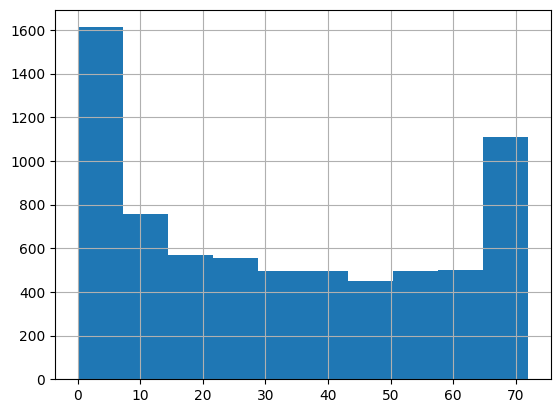

In [69]:
display(df["tenure"].describe())
df["tenure"].hist()

Tenure is number of months with the company, so 6 years as a maximum and 0 years is a a minimum. Its concentrated at the tails and uniform in the middle, which is interesting to me? I'd expect it to maybe be pareto.

In [70]:
print(df["PhoneService"].value_counts())

PhoneService
Yes    6361
No      682
Name: count, dtype: int64


Overwhelmingly yes which is expected for a telco company, its ~10% Nos, or 682 which is decent enough examples. I had to look to make sure but it does do other services too and churn captures "leaving the company", which for lack of clarity I assume means discontinue all services.

In [71]:
print(df["MultipleLines"].value_counts())

MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64


I am an exact here with the phone service, I think we should drop phone service entirely as this captures that information and more.

In [72]:
((df["PhoneService"] == "No") ==  (df["MultipleLines"] == "No phone service")).mean()

np.float64(1.0)

Not inconsistent at all so we'll drop it from analysis

In [73]:
df = df.drop(columns=["PhoneService"])

In [74]:
print(df["InternetService"].value_counts())

InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64


Even split among type, though this feature conceptually mixes the concept of type of internet as well as whether there is one or not as seems to be the style in this dataset (heirarchical).

In [75]:
print(df["OnlineSecurity"].value_counts())

OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64


In [76]:
print(df["OnlineBackup"].value_counts())

OnlineBackup
No                     3088
Yes                    2429
No internet service    1526
Name: count, dtype: int64


In [77]:
print(df["DeviceProtection"].value_counts())

DeviceProtection
No                     3095
Yes                    2422
No internet service    1526
Name: count, dtype: int64


In [78]:
print(df["TechSupport"].value_counts())

TechSupport
No                     3473
Yes                    2044
No internet service    1526
Name: count, dtype: int64


In [79]:
print(df["StreamingTV"].value_counts())

StreamingTV
No                     2810
Yes                    2707
No internet service    1526
Name: count, dtype: int64


In [80]:
print(df["StreamingMovies"].value_counts())

StreamingMovies
No                     2785
Yes                    2732
No internet service    1526
Name: count, dtype: int64


These are the descendent features of internet service (hierarchy), they're evenly split but there maybe we can merge these in a conceptually helpful (for interpretability) way, maybe something like number of add-ons for internet or something.

In [81]:
print(df["Contract"].value_counts())

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64


Good porportions, intuitively seems like a good predictor, since month to month valued the ability to switch.

In [82]:
print(df["PaperlessBilling"].value_counts())

PaperlessBilling
Yes    4171
No     2872
Name: count, dtype: int64


Good porportions, I don't expect massive predictive power but lets see.

In [83]:
print(df["PaymentMethod"].value_counts())

PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64


Good porportions.

In [84]:
print(df["MonthlyCharges"].describe())
df["MonthlyCharges"].isna().sum()

count    7043.000000
mean       64.761692
std        30.090047
min        18.250000
25%        35.500000
50%        70.350000
75%        89.850000
max       118.750000
Name: MonthlyCharges, dtype: float64


np.int64(0)

<Axes: >

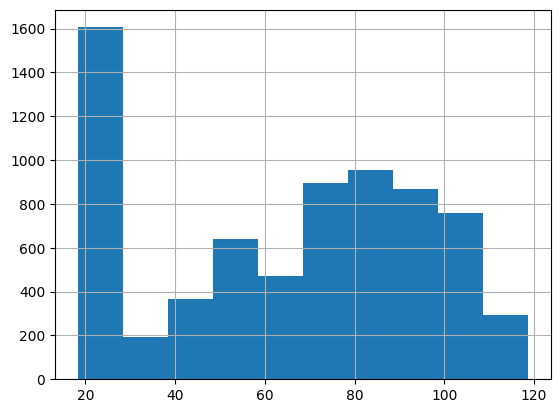

In [85]:
df["MonthlyCharges"].hist()

Seems clean no invalid data, and ranges seem appropriate

In [86]:
print(df["TotalCharges"].describe())

count     7043
unique    6531
top           
freq        11
Name: TotalCharges, dtype: object


In [87]:
# we should convert the total charges to number, NAN where not possible or blank
pd.to_numeric(df["TotalCharges"], errors='coerce').isna().sum()

np.int64(11)

11 were invalid. This is 11/ 7043 is 0.1 % of the dataset, lets look at the clean first.

In [88]:
total_charges_converted = pd.to_numeric(df["TotalCharges"], errors='coerce')

count    7032.000000
mean     2283.300441
std      2266.771362
min        18.800000
25%       401.450000
50%      1397.475000
75%      3794.737500
max      8684.800000
Name: TotalCharges, dtype: float64


<Axes: >

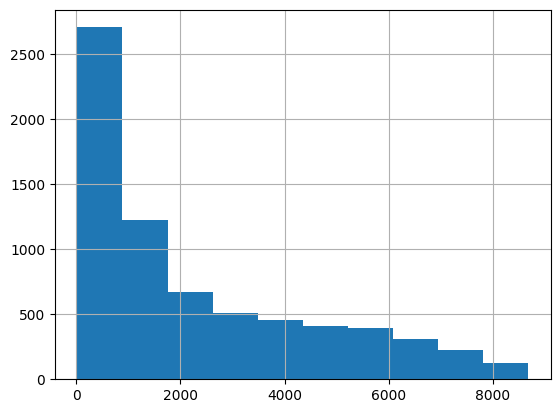

In [89]:
print(total_charges_converted.dropna(ignore_index=True).describe())
total_charges_converted.hist()

Seems clean enough though those are some big bills and a huge range. The metadata says the total amount charged to customer. I thought it was yearly but 12 * 118 is 1.4k, which misses the mark, but considering the max tenure is 72 * 118 is $8500, which makes sense with what we're seeing, so this is total over the lifetime of the customer's relationship with the telco company (suspecting monthly_charges * tenure), lets see.

In [90]:
difference = df["tenure"] * df["MonthlyCharges"] - total_charges_converted

count    7032.000000
mean       -0.153193
std        67.255326
min      -373.250000
25%       -28.700000
50%         0.000000
75%        28.650000
max       370.850000
dtype: float64


<Axes: >

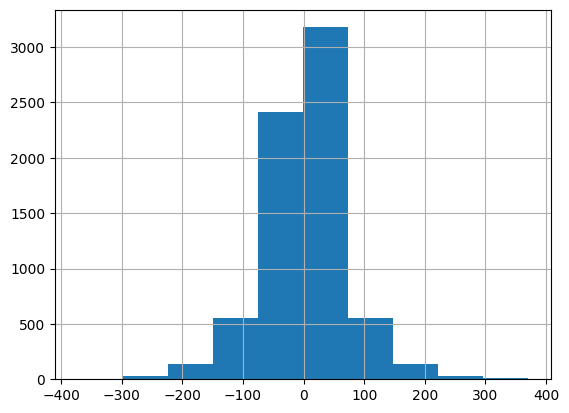

In [91]:
print(difference.describe())
difference.hist()

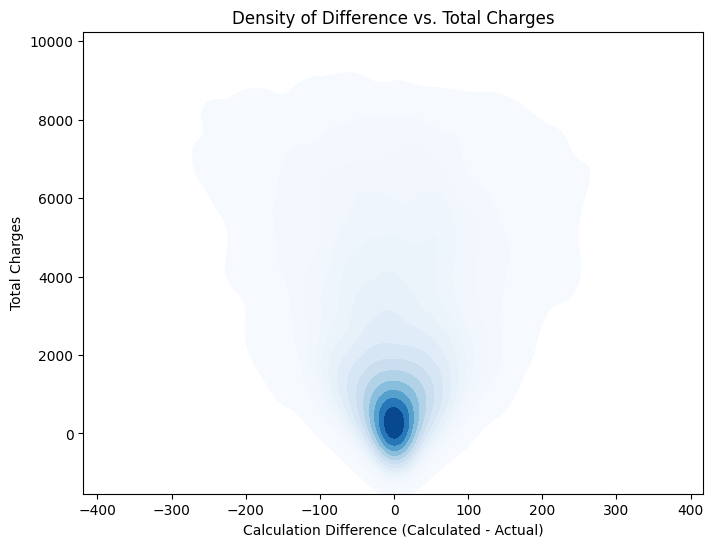

In [92]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8, 6))

# 'Blues' blends nicely with the white background, 'levels=15' makes the contours smoother
sns.kdeplot(x=difference, y=total_charges_converted, fill=True, cmap="Blues", thresh=0.01, levels=15)

plt.title("Density of Difference vs. Total Charges")
plt.xlabel("Calculation Difference (Calculated - Actual)") # Fixed the 'None' label
plt.ylabel("Total Charges")
plt.show()

So most of the data is just the monthly times the tenure, but as the projected bill gets bigger there is a higher variance on this estimate.
This can be converted into a useful feature though, like if theres variance in the estimate could indicate recent bill changes.

Now lets see whats common about the ones with NA.

In [93]:
df[total_charges_converted.isna()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [94]:
(df[df["tenure"] == 0].index == df[total_charges_converted.isna()].index).mean()

np.float64(1.0)

In [95]:
total_charges_converted.loc[df["tenure"] == 0] = 0

So it looks like we could replace with 0s.

In [96]:
df["TotalCharges"] = total_charges_converted

In [97]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Label looks clean enough, and relatively well balanced though not exactly, with a majority No (expected.)

### Interpretability
Given our model assumptions, we need to experiment and think about how to best engineer features that fit those assumptions.

In [98]:
df_interpertability = df.copy()
df_interpertability.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


Lets start with customer ID, it's a non generalizable feature, so we drop it.

In [99]:
df_interpertability = df_interpertability.drop(columns=["customerID"])

Gender is balanced and mutually exclusive, so lets one hot encode it and make the female baseline:

In [100]:
df_interpertability["gender"].value_counts()

gender
Male      3555
Female    3488
Name: count, dtype: int64

In [101]:
isMaleNotFemaleSeries = df_interpertability["gender"] == "Male"
isMaleNotFemaleSeries.mean()

np.float64(0.504756495811444)

In [102]:
df_interpertability["isMaleNotFemale"] = isMaleNotFemaleSeries.astype(int)
df_interpertability = df_interpertability.drop(columns=["gender"])

SeniorCitizen is okay balanced (16%) and mutually exclusive, so lets one hot encode it and make the non senior citizen baseline:

In [103]:
isSeniorCitizenNotRegular = df_interpertability["SeniorCitizen"] == 1
df_interpertability["isSeniorCitizenNotRegular"] = isSeniorCitizenNotRegular.astype(int)
print(isSeniorCitizenNotRegular.mean())
df_interpertability = df_interpertability.drop(columns="SeniorCitizen")

0.1621468124378816


Partner and dependents:

In [104]:
hasPartner = df_interpertability["Partner"] == "Yes"
df_interpertability["hasPartner"] = hasPartner.astype(int)
print(hasPartner.mean())
df_interpertability = df_interpertability.drop(columns="Partner")

0.4830327985233565


In [105]:
hasDependents = df_interpertability["Dependents"] == "Yes"
df_interpertability["hasDependents"] = hasDependents.astype(int)
print(hasDependents.mean())
df_interpertability = df_interpertability.drop(columns="Dependents")

0.2995882436461735


May be some correlation between dependents and has partner:

In [106]:
hasDependents.corr(hasPartner)

np.float64(0.4526762829294647)

This is relatively high correlation here - let's combine these into a household status.

In [107]:
import numpy as np
conditions = [
    (df_interpertability["hasPartner"] == 0) & (df_interpertability["hasDependents"] == 0),
    (df_interpertability["hasPartner"] == 1) & (df_interpertability["hasDependents"] == 0),
    (df_interpertability["hasPartner"] == 0) & (df_interpertability["hasDependents"] == 1),
    (df_interpertability["hasPartner"] == 1) & (df_interpertability["hasDependents"] == 1)
]

choices = ["Single", "PartnerOnly", "DependentsOnly", "Family"]

df_interpertability["HouseholdStatus"] = np.select(conditions, choices, default="Unknown")
df_interpertability = df_interpertability.drop(columns=["hasPartner", "hasDependents"])


In [108]:
df_interpertability["PartnerOnlyNotSingle"] = (df_interpertability["HouseholdStatus"] == "PartnerOnly").astype(int)
df_interpertability["DependentsOnlyNotSingle"] = (df_interpertability["HouseholdStatus"] == "DependentsOnly").astype(int)
df_interpertability["FamilyNotSingle"] = (df_interpertability["HouseholdStatus"] == "Family").astype(int)

df_interpertability = df_interpertability.drop(columns=["HouseholdStatus"])

Tenure is fine as is I suspect.

Multiple lines we have a clean mutually exclusive categorical. The most common is 1 line so that will be the reference class.

In [109]:
df_interpertability["NoPhoneServiceNotOneLine"] = (df_interpertability["MultipleLines"] == "No phone service").astype(int)
df_interpertability["MultipleLinesNotOneLine"] = (df_interpertability["MultipleLines"] == "Yes").astype(int)

df_interpertability = df_interpertability.drop(columns=["MultipleLines"])

In [110]:
df_interpertability["MultipleLinesNotOneLine"].corr(df_interpertability["PartnerOnlyNotSingle"]), df_interpertability["MultipleLinesNotOneLine"].corr(df_interpertability["DependentsOnlyNotSingle"]), df_interpertability["MultipleLinesNotOneLine"].corr(df_interpertability["FamilyNotSingle"])

(np.float64(0.16057405360933358),
 np.float64(-0.06425324545207602),
 np.float64(0.00679197679232229))

Suspected correlation between multiple lines and house hold status but its pretty small.

Now we get into an interesting set of features, along with internet service, we have addons features with a category of no internet service. There will be severe multi collinearity if we take a simple approach (like simply one hot encoding each add on and internet service generally), which would bring unreliable inferences (inflating standard errors due to small determinants (or inverted small eigenvalues) used in calculating the standard errors.)

So we are going to create mutually exclusive classes with no overlap and leave the no internet service as a reference class - lets see how much data we have for each possible combination and number of add ons (as I doubt we will have every possible combination).

In [111]:
counts = (df_interpertability["OnlineSecurity"] == "Yes").astype(int) + (df_interpertability["OnlineBackup"] == "Yes") + (df_interpertability["DeviceProtection"] == "Yes") + (df_interpertability["TechSupport"] == "Yes") + (df_interpertability["StreamingMovies"] == "Yes") + (df_interpertability["StreamingTV"] == "Yes")

df_interpertability["InternetAddOnCount"] = counts

In [112]:
df_interpertability["InternetServices"] = "HasInternet" + df_interpertability["InternetService"] + "With" + df_interpertability["InternetAddOnCount"].astype(str) + "ExtraServices"
df_interpertability["InternetServices"].value_counts()

InternetServices
HasInternetNoWith0ExtraServices             1526
HasInternetFiber opticWith3ExtraServices     643
HasInternetFiber opticWith2ExtraServices     579
HasInternetFiber opticWith1ExtraServices     551
HasInternetFiber opticWith4ExtraServices     493
HasInternetDSLWith3ExtraServices             475
HasInternetDSLWith2ExtraServices             454
HasInternetDSLWith1ExtraServices             415
HasInternetFiber opticWith0ExtraServices     399
HasInternetDSLWith4ExtraServices             359
HasInternetDSLWith0ExtraServices             294
HasInternetFiber opticWith5ExtraServices     290
HasInternetDSLWith5ExtraServices             281
HasInternetDSLWith6ExtraServices             143
HasInternetFiber opticWith6ExtraServices     141
Name: count, dtype: int64

In [113]:
df_interpertability = pd.concat([df_interpertability, pd.get_dummies(df_interpertability["InternetServices"]).astype(int).drop(columns="HasInternetNoWith0ExtraServices")], axis=1)
df_interpertability = df_interpertability.drop(columns=["InternetAddOnCount", "InternetServices", "InternetService", "OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"])

So we combined it counts look good (>50 for each category)

The following are categorical and no overlap standard pick reference class (usually largest) and one hot encode rest.

In [114]:
df_interpertability["Contract_Two_Year_Not_Month_To_Month"] = (df_interpertability["Contract"] == "Two year").astype(int)
df_interpertability["Contract_One_Year_Not_Month_To_Month"] = (df_interpertability["Contract"] == "One year").astype(int)

In [115]:
df_interpertability = df_interpertability.drop(columns=["Contract"])

In [116]:
df_interpertability["NoPaperlessBilling"] = (df_interpertability["PaperlessBilling"] == "No").astype(int)
df_interpertability = df_interpertability.drop(columns=["PaperlessBilling"])

In [117]:
df_interpertability["MailedCheckNotECheck"] = (df_interpertability["PaymentMethod"] == "Mailed check").astype(int)
df_interpertability["AutoBankTransferNotECheck"] = (df_interpertability["PaymentMethod"] == "Bank transfer (automatic)").astype(int)
df_interpertability["AutoCreditCardNotECheck"] = (df_interpertability["PaymentMethod"] == "Credit card (automatic)").astype(int)

In [118]:
df_interpertability = df_interpertability.drop(columns=["PaymentMethod"])

Already processed monthly and total charges, now lets look at the label.

In [119]:
df_interpertability["Churn"] = (df_interpertability["Churn"] == "Yes").astype(int)

In [120]:
df_interpertability.head()

,tenure,MonthlyCharges,TotalCharges,Churn,isMaleNotFemale,isSeniorCitizenNotRegular,PartnerOnlyNotSingle,DependentsOnlyNotSingle,FamilyNotSingle,NoPhoneServiceNotOneLine,...,HasInternetFiber opticWith3ExtraServices,HasInternetFiber opticWith4ExtraServices,HasInternetFiber opticWith5ExtraServices,HasInternetFiber opticWith6ExtraServices,Contract_Two_Year_Not_Month_To_Month,Contract_One_Year_Not_Month_To_Month,NoPaperlessBilling,MailedCheckNotECheck,AutoBankTransferNotECheck,AutoCreditCardNotECheck
0,1,29.85,29.85,0,0,0,1,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1,34,56.95,1889.50,0,1,0,0,0,0,0,...,0,0,0,0,0,1,1,1,0,0
2,2,53.85,108.15,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,45,42.30,1840.75,0,1,0,0,0,0,1,...,0,0,0,0,0,1,1,0,1,0
4,2,70.70,151.65,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [121]:
df_interpertability.describe()

,tenure,MonthlyCharges,TotalCharges,Churn,isMaleNotFemale,isSeniorCitizenNotRegular,PartnerOnlyNotSingle,DependentsOnlyNotSingle,FamilyNotSingle,NoPhoneServiceNotOneLine,...,HasInternetFiber opticWith3ExtraServices,HasInternetFiber opticWith4ExtraServices,HasInternetFiber opticWith5ExtraServices,HasInternetFiber opticWith6ExtraServices,Contract_Two_Year_Not_Month_To_Month,Contract_One_Year_Not_Month_To_Month,NoPaperlessBilling,MailedCheckNotECheck,AutoBankTransferNotECheck,AutoCreditCardNotECheck
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,...,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304,0.265370,0.504756,0.162147,0.234701,0.051257,0.248332,0.096834,...,0.091296,0.069999,0.041176,0.020020,0.240664,0.209144,0.407781,0.228880,0.219225,0.216101
std,24.559481,30.090047,2266.794470,0.441561,0.500013,0.368612,0.423842,0.220536,0.432076,0.295752,...,0.288050,0.255163,0.198710,0.140078,0.427517,0.406726,0.491457,0.420141,0.413751,0.411613
min,0.000000,18.250000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,9.000000,35.500000,398.550000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,29.000000,70.350000,1394.550000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,55.000000,89.850000,3786.600000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
max,72.000000,118.750000,8684.800000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


We have ourselves a good looking dataset to perform inference on.

In [122]:
import statsmodels.api as sm

y = df_interpertability["Churn"]
x = df_interpertability.drop(columns=["Churn"])
x = sm.add_constant(x)

model = sm.Logit(y, x).fit()

model.summary()

Optimization terminated successfully.
         Current function value: 0.415155
         Iterations 8


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                  Churn   No. Observations:                 7043
Model:                          Logit   Df Residuals:                     7012
Method:                           MLE   Df Model:                           30
Date:                Mon, 13 Jul 2026   Pseudo R-squ.:                  0.2825
Time:                        16:00:42   Log-Likelihood:                -2923.9
converged:                       True   LL-Null:                       -4075.1
Covariance Type:            nonrobust   LLR p-value:                     0.000
============================================================================================================
                                               coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------
const                                       -2.1185      0.304     -6.977      0.000      -2.714      -1.523
tenure                                      -0.0551      0.007     -8.017      0.000      -0.069      -0.042
MonthlyCharges                               0.0757      0.012      6.096      0.000       0.051       0.100
TotalCharges                                 0.0003   8.09e-05      3.239      0.001       0.000       0.000
isMaleNotFemale                             -0.0220      0.065     -0.339      0.734      -0.149       0.105
isSeniorCitizenNotRegular                    0.2322      0.084      2.753      0.006       0.067       0.397
PartnerOnlyNotSingle                        -0.0028      0.086     -0.033      0.974      -0.171       0.165
DependentsOnlyNotSingle                     -0.2136      0.154     -1.382      0.167      -0.516       0.089
FamilyNotSingle                             -0.1383      0.094     -1.475      0.140      -0.322       0.046
NoPhoneServiceNotOneLine                     2.1779      0.272      8.014      0.000       1.645       2.711
MultipleLinesNotOneLine                     -0.1091      0.102     -1.074      0.283      -0.308       0.090
HasInternetDSLWith0ExtraServices            -1.0865      0.345     -3.146      0.002      -1.763      -0.410
HasInternetDSLWith1ExtraServices            -1.7044      0.413     -4.131      0.000      -2.513      -0.896
HasInternetDSLWith2ExtraServices            -2.4094      0.498     -4.841      0.000      -3.385      -1.434
HasInternetDSLWith3ExtraServices            -3.1291      0.594     -5.271      0.000      -4.293      -1.966
HasInternetDSLWith4ExtraServices            -3.4140      0.686     -4.979      0.000      -4.758      -2.070
HasInternetDSLWith5ExtraServices            -4.0464      0.786     -5.150      0.000      -5.586      -2.506
HasInternetDSLWith6ExtraServices            -5.0414      1.091     -4.623      0.000      -7.179      -2.904
HasInternetFiber opticWith0ExtraServices    -2.2420      0.630     -3.559      0.000      -3.477      -1.007
HasInternetFiber opticWith1ExtraServices    -2.7968      0.716     -3.908      0.000      -4.199      -1.394
HasInternetFiber opticWith2ExtraServices    -3.5077      0.815     -4.302      0.000      -5.106      -1.910
HasInternetFiber opticWith3ExtraServices    -4.0533      0.900     -4.505      0.000      -5.817      -2.290
HasInternetFiber opticWith4ExtraServices    -4.3618      0.981     -4.445      0.000      -6.285      -2.438
HasInternetFiber opticWith5ExtraServices    -5.0338      1.058     -4.757      0.000      -7.108      -2.960
HasInternetFiber opticWith6ExtraServices    -5.6718      1.161     -4.887      0.000      -7.946      -3.397
Contract_Two_Year_Not_Month_To_Month        -1.4486      0.181     -8.004      0.000      -1.803      -1.094
Contract_One_Year_Not_Month_To_Month        -0.6960      0.108     -6.438      0

In [123]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor

def redundancy_check(x):
    print("Rule of thumb: < 30 is good, > 100 indicates severe multicollinearity.\n")
    vif_data = pd.DataFrame()
    vif_data["Feature"] = x.columns
    vif_data["VIF"] = [variance_inflation_factor(x.values, i) for i in range(x.shape[1])]
    vif_data = vif_data[vif_data["Feature"] != "const"].sort_values(by="VIF", ascending=False)
    print("--- Top 10 Variance Inflation Factors ---")
    print(vif_data.head(10))
redundancy_check(x)

Rule of thumb: < 30 is good, > 100 indicates severe multicollinearity.

--- Top 10 Variance Inflation Factors ---
                                     Feature         VIF
2                             MonthlyCharges  140.279774
21  HasInternetFiber opticWith3ExtraServices   67.159855
22  HasInternetFiber opticWith4ExtraServices   63.263808
20  HasInternetFiber opticWith2ExtraServices   50.048470
23  HasInternetFiber opticWith5ExtraServices   45.002897
19  HasInternetFiber opticWith1ExtraServices   36.939069
24  HasInternetFiber opticWith6ExtraServices   26.202575
16          HasInternetDSLWith5ExtraServices   21.573855
18  HasInternetFiber opticWith0ExtraServices   21.193467
15          HasInternetDSLWith4ExtraServices   20.896046


Looks like Monthly Charges is redundant information given the services, which makes sense all things considered. Let's drop it and total charges as we want to see what features effect the output.

In [124]:
x_no_charges = x.drop(columns=["MonthlyCharges", "TotalCharges"])
redundancy_check(x_no_charges)

Rule of thumb: < 30 is good, > 100 indicates severe multicollinearity.

--- Top 10 Variance Inflation Factors ---
                                     Feature       VIF
1                                     tenure  2.757418
23      Contract_Two_Year_Not_Month_To_Month  2.683077
19  HasInternetFiber opticWith3ExtraServices  1.716629
26                      MailedCheckNotECheck  1.672006
18  HasInternetFiber opticWith2ExtraServices  1.666269
17  HasInternetFiber opticWith1ExtraServices  1.644494
24      Contract_One_Year_Not_Month_To_Month  1.640606
20  HasInternetFiber opticWith4ExtraServices  1.554252
28                   AutoCreditCardNotECheck  1.511991
27                 AutoBankTransferNotECheck  1.501395


In [125]:
model = sm.Logit(y, x_no_charges).fit()
model.summary()


Optimization terminated successfully.
         Current function value: 0.419136
         Iterations 8


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                  Churn   No. Observations:                 7043
Model:                          Logit   Df Residuals:                     7014
Method:                           MLE   Df Model:                           28
Date:                Mon, 13 Jul 2026   Pseudo R-squ.:                  0.2756
Time:                        16:00:43   Log-Likelihood:                -2952.0
converged:                       True   LL-Null:                       -4075.1
Covariance Type:            nonrobust   LLR p-value:                     0.000
============================================================================================================
                                               coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------
const                                       -0.7069      0.137     -5.174      0.000      -0.975      -0.439
tenure                                      -0.0357      0.002    -15.139      0.000      -0.040      -0.031
isMaleNotFemale                             -0.0156      0.065     -0.242      0.809      -0.142       0.111
isSeniorCitizenNotRegular                    0.2550      0.084      3.032      0.002       0.090       0.420
PartnerOnlyNotSingle                        -0.0044      0.085     -0.052      0.959      -0.172       0.163
DependentsOnlyNotSingle                     -0.2299      0.154     -1.494      0.135      -0.532       0.072
FamilyNotSingle                             -0.1599      0.093     -1.713      0.087      -0.343       0.023
NoPhoneServiceNotOneLine                     0.6122      0.127      4.826      0.000       0.364       0.861
MultipleLinesNotOneLine                      0.3327      0.078      4.265      0.000       0.180       0.486
HasInternetDSLWith0ExtraServices             0.8857      0.167      5.298      0.000       0.558       1.213
HasInternetDSLWith1ExtraServices             0.7213      0.160      4.514      0.000       0.408       1.034
HasInternetDSLWith2ExtraServices             0.5082      0.171      2.970      0.003       0.173       0.844
HasInternetDSLWith3ExtraServices             0.3750      0.190      1.971      0.049       0.002       0.748
HasInternetDSLWith4ExtraServices             0.6155      0.232      2.650      0.008       0.160       1.071
HasInternetDSLWith5ExtraServices             0.5467      0.308      1.777      0.076      -0.056       1.150
HasInternetDSLWith6ExtraServices             0.1772      0.738      0.240      0.810      -1.269       1.624
HasInternetFiber opticWith0ExtraServices     1.6335      0.159     10.285      0.000       1.322       1.945
HasInternetFiber opticWith1ExtraServices     1.6579      0.151     11.014      0.000       1.363       1.953
HasInternetFiber opticWith2ExtraServices     1.6217      0.152     10.645      0.000       1.323       1.920
HasInternetFiber opticWith3ExtraServices     1.6912      0.155     10.881      0.000       1.387       1.996
HasInternetFiber opticWith4ExtraServices     2.0131      0.172     11.738      0.000       1.677       2.349
HasInternetFiber opticWith5ExtraServices     1.9058      0.216      8.810      0.000       1.482       2.330
HasInternetFiber opticWith6ExtraServices     1.8722      0.348      5.374      0.000       1.189       2.555
Contract_Two_Year_Not_Month_To_Month        -1.4574      0.179     -8.138      0.000      -1.808      -1.106
Contract_One_Year_Not_Month_To_Month        -0.6889      0.107     -6.425      0.000      -0.899      -0.479
NoPaperlessBilling                          -0.3839      0.074     -5.210      0.000      -0.528      -0.239
MailedCheckNotECheck                        -0.4317      0.095     -4.565      0

So we will now do average marginal effects, lets check continous for roughly linear log odds.

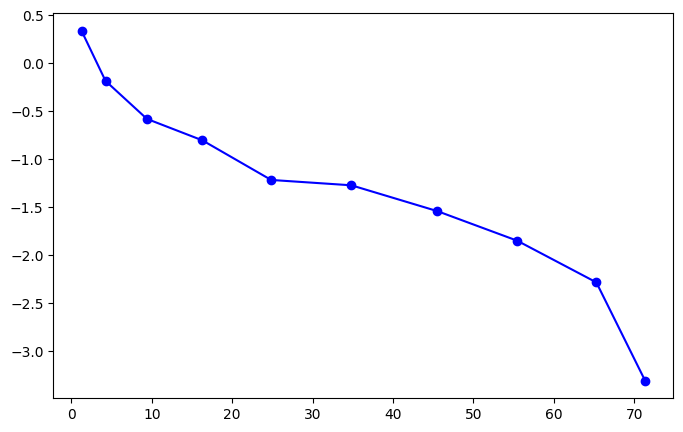

In [126]:
plot_binned_log_odds_with_label(x_no_charges["tenure"].to_numpy(), y.to_numpy())

Looks pretty good, though drop off from linear at edges, we'll keep it.

In [127]:
ame = model.get_margeff(at="overall", method="dydx")
print(ame.summary())

        Logit Marginal Effects       
Dep. Variable:                  Churn
Method:                          dydx
At:                           overall
                                              dy/dx    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------
tenure                                      -0.0049      0.000    -16.270      0.000      -0.005      -0.004
isMaleNotFemale                             -0.0021      0.009     -0.242      0.809      -0.019       0.015
isSeniorCitizenNotRegular                    0.0350      0.011      3.041      0.002       0.012       0.058
PartnerOnlyNotSingle                        -0.0006      0.012     -0.052      0.959      -0.024       0.022
DependentsOnlyNotSingle                     -0.0315      0.021     -1.496      0.135      -0.073       0.010
FamilyNotSingle                             -0.0219      0.013     -1.714      0.087 

So after all the hard lets see what we found (I am ignoring high p-values since they fail to have significant association with our label (0.05 cut off)).
0. Holding everything else constant, on average every month of tenure that a customer is with the company is associated with an half percent point decrease in their churn probability.
1. Holding everything else constant, on average being a senior citizen is associated with a 3.5 percentage point higher probability of churn.
2. Holding everything else constant, on average not having phone service from a baseline of one line is associated with a 8.4 percentage point increase in churn probability and having multiple lines a 4.5 percentage point increase. 
3. Holding everyting else constant, on average having DSL internet from a baseline of no internet is associated with a 5-12 percentage point increase in churn probability depending on how many extra services, with more services tending to be on the lower end of the increase.
4. Holding everyting else constant, on average having Fiber Optic internet from a baseline of no internet is associated with a 22-26 percentage point in churn probability increase depending on how many extra services, with more services tending to be on the higher end of the increase.
5. Holding everything else constant, on average having a two year contract over a baseline of month to month leads to a 20 percentage point decrease in churn probability, and a one year has a 10% percentage point decrease association.
6. Holding everything else constant, on average not having paperless billing is associated with a 5 percentage point decrease in churn probability.
7. Holding everything else constant, on average paying with mailed checks not Echecks is associated with a 6 percentage point decrease in churn probability.
8. Holding everything else constant, on average haivng automatic bank tranfers not Echecks is associated with a 5 percentage point decrease in churn probability.
9. Holding everything else constant, on average haivng automatic credit card charges not Echecks is associated with a 6.4 percentage point decrease in churn probability.

This is where these discovered associations could be used to estimate ROI on business decisions, for example helping price the contracts knowing the associated churn rate reduction on average or a discount if they go with auto pay.

### Inference Performance
Now we explore how to maximize our generalization performance on this problem. Let's train an unregularized logistic model on raw features as a baseline - see validation performance and adjust bias and variance to find our optimal generalization performance.
Lets have a hold out set of 10%, then since training is generally cheaply k-fold validation scores to compare all our models.

In [128]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [129]:
df_inference = df.drop(columns=["customerID"])
df_inference["Churn"] = (df_inference["Churn"] == "Yes").astype(int)
df_inference = pd.concat([df_inference, pd.get_dummies(df_inference["gender"]).astype(int)], axis=1)
df_inference = df_inference.drop(columns=["gender"])
df_inference["Partner"] = (df_inference["Partner"] == "Yes").astype(int)
df_inference["Dependents"] = (df_inference["Dependents"] == "Yes").astype(int)
df_inference = pd.concat([df_inference, pd.get_dummies(df_inference["MultipleLines"], prefix="MultipleLines").astype(int)], axis=1)
df_inference = df_inference.drop(columns="MultipleLines")
df_inference = pd.concat([df_inference, pd.get_dummies(df_inference["InternetService"], prefix="InternetService").astype(int)], axis=1)
df_inference = df_inference.drop(columns="InternetService")
df_inference = pd.concat([df_inference, pd.get_dummies(df_inference["OnlineSecurity"], prefix="OnlineSecurity").astype(int)], axis=1)
df_inference = df_inference.drop(columns="OnlineSecurity")
df_inference = pd.concat([df_inference, pd.get_dummies(df_inference["OnlineBackup"], prefix="OnlineBackup").astype(int)], axis=1)
df_inference = df_inference.drop(columns="OnlineBackup")
df_inference = pd.concat([df_inference, pd.get_dummies(df_inference["DeviceProtection"], prefix="DeviceProtection").astype(int)], axis=1)
df_inference = df_inference.drop(columns="DeviceProtection")
df_inference = pd.concat([df_inference, pd.get_dummies(df_inference["TechSupport"], prefix="TechSupport").astype(int)], axis=1)
df_inference = df_inference.drop(columns="TechSupport")
df_inference = pd.concat([df_inference, pd.get_dummies(df_inference["StreamingTV"], prefix="StreamingTV").astype(int)], axis=1)
df_inference = df_inference.drop(columns="StreamingTV")
df_inference = pd.concat([df_inference, pd.get_dummies(df_inference["StreamingMovies"], prefix="StreamingMovies").astype(int)], axis=1)
df_inference = df_inference.drop(columns="StreamingMovies")
df_inference = pd.concat([df_inference, pd.get_dummies(df_inference["Contract"], prefix="Contract").astype(int)], axis=1)
df_inference = df_inference.drop(columns="Contract")
df_inference["PaperlessBilling"] = (df_inference["PaperlessBilling"] == "Yes").astype(int)
df_inference = pd.concat([df_inference, pd.get_dummies(df_inference["PaymentMethod"], prefix="PaymentMethod").astype(int)], axis=1)
df_inference = df_inference.drop(columns="PaymentMethod")

In [130]:
from sklearn.model_selection import train_test_split

x = df_inference.drop(columns=["Churn"])
y = df_inference["Churn"]

x_train, x_test, y_train, y_test = train_test_split(x, y, stratify=y, test_size=0.1)
x_train.head()

,SeniorCitizen,Partner,Dependents,tenure,PaperlessBilling,MonthlyCharges,TotalCharges,Female,Male,MultipleLines_No,...,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
678,0,0,0,3,0,107.95,313.60,0,1,0,...,0,0,1,1,0,0,0,0,0,1
231,0,0,0,50,1,93.50,4747.50,0,1,1,...,0,0,1,1,0,0,0,1,0,0
847,0,1,1,12,0,33.15,444.75,1,0,0,...,1,0,0,0,1,0,0,1,0,0
4500,0,1,1,61,0,103.90,6449.15,0,1,1,...,0,0,1,0,1,0,0,1,0,0
1326,0,1,1,43,1,51.25,2151.60,1,0,0,...,1,0,0,0,1,0,1,0,0,0


In [131]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate

model = LogisticRegression(penalty=None, solver='lbfgs', max_iter=10000)
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True)

cross_validate(model, x_train, y_train, cv=cv_strategy, scoring=["accuracy", "average_precision", "roc_auc", "f1"], return_train_score=True)

{'fit_time': array([0.2525413 , 0.73922563, 0.29694819, 0.70993018, 0.57998013]),
 'score_time': array([0.00349402, 0.00652289, 0.00376868, 0.0036509 , 0.00842214]),
 'test_accuracy': array([0.80362776, 0.80914826, 0.79416404, 0.79242305, 0.81610103]),
 'train_accuracy': array([0.80394477, 0.80236686, 0.80571992, 0.80753303, 0.80220864]),
 'test_average_precision': array([0.64518277, 0.66396075, 0.62758173, 0.64060187, 0.67797847]),
 'train_average_precision': array([0.66418111, 0.65620327, 0.66277727, 0.66087323, 0.65177982]),
 'test_roc_auc': array([0.84448926, 0.8576082 , 0.82449235, 0.83552632, 0.85350174]),
 'train_roc_auc': array([0.84665738, 0.8436537 , 0.85210718, 0.84928339, 0.84478893]),
 'test_f1': array([0.59380098, 0.61341853, 0.59282371, 0.56093489, 0.61359867]),
 'train_f1': array([0.5982215 , 0.59268293, 0.60266236, 0.60740145, 0.5924421 ])}

In [132]:
y_train.value_counts(normalize=True)

Churn
0    0.734617
1    0.265383
Name: proportion, dtype: float64

Accuracy is slightly better than baseline guessing the major class (6% higher accuracy). And theres only a small gap between them for accuracy and other stats are similar gaps, lets start by basis expansion to give more flexbility to the model (higher variance).

In [133]:
from sklearn.preprocessing import SplineTransformer, PolynomialFeatures, StandardScaler
from sklearn.feature_selection import VarianceThreshold

tenure_data = x_train[["tenure"]]

spline_maker = SplineTransformer(n_knots=3, degree=3, extrapolation='linear', include_bias=False).set_output(transform="pandas")

spline_data = spline_maker.fit_transform(tenure_data)

scaler = StandardScaler().set_output(transform="pandas")

x_train_basis_expansion = pd.concat([x_train.drop(columns=["tenure"]), spline_data], axis=1)

polynomial_feature_maker = PolynomialFeatures(degree=3, include_bias=False, interaction_only=True).set_output(transform="pandas")
x_train_basis_expansion =polynomial_feature_maker.fit_transform(x_train_basis_expansion)
variance_filter = VarianceThreshold(threshold=0.0).set_output(transform="pandas")
x_train_basis_expansion = variance_filter.fit_transform(x_train_basis_expansion)
x_train_basis_expansion =  scaler.fit_transform(x_train_basis_expansion)
x_train_basis_expansion.head()

,SeniorCitizen,Partner,Dependents,PaperlessBilling,MonthlyCharges,TotalCharges,Female,Male,MultipleLines_No,MultipleLines_No phone service,...,PaymentMethod_Mailed check tenure_sp_0 tenure_sp_1,PaymentMethod_Mailed check tenure_sp_0 tenure_sp_2,PaymentMethod_Mailed check tenure_sp_0 tenure_sp_3,PaymentMethod_Mailed check tenure_sp_1 tenure_sp_2,PaymentMethod_Mailed check tenure_sp_1 tenure_sp_3,PaymentMethod_Mailed check tenure_sp_2 tenure_sp_3,tenure_sp_0 tenure_sp_1 tenure_sp_2,tenure_sp_0 tenure_sp_1 tenure_sp_3,tenure_sp_0 tenure_sp_2 tenure_sp_3,tenure_sp_1 tenure_sp_2 tenure_sp_3
678,-0.439486,-0.969233,-0.657754,-1.201779,1.432619,-0.870309,-0.988080,0.988080,-0.960089,-0.327813,...,2.989609,2.934787,-0.144024,1.652781,-0.303167,-0.281755,1.619707,-0.512050,-0.563085,-0.780549
231,-0.439486,-0.969233,-0.657754,0.832100,0.952266,1.089646,-0.988080,0.988080,1.041570,-0.327813,...,-0.347282,-0.390568,-0.290142,-0.462686,-0.314504,-0.282220,-0.780007,-0.628671,-0.601319,0.548831
847,-0.439486,1.031744,1.520326,-1.201779,-1.053912,-0.812336,1.012064,-1.012064,-0.960089,3.050523,...,-0.347282,-0.390568,-0.290142,-0.462686,-0.314504,-0.282220,0.625912,1.868582,1.046906,-0.575651
4500,-0.439486,1.031744,1.520326,-1.201779,1.297987,1.841841,-0.988080,0.988080,1.041570,-0.327813,...,-0.347282,-0.390568,-0.290142,-0.462686,-0.314504,-0.282220,-0.780007,-0.628671,-0.601319,-0.627621
1326,-0.439486,1.031744,1.520326,0.832100,-0.452225,-0.057842,1.012064,-1.012064,-0.960089,3.050523,...,-0.347282,-0.390568,-0.290142,-0.462686,-0.314504,-0.282220,-0.780007,-0.628671,-0.601319,1.643566


In [134]:
model = LogisticRegression(solver="liblinear", penalty='l1', C=0.0225)
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True)
cross_validate(model, x_train_basis_expansion, y_train, cv=cv_strategy, scoring=["accuracy", "average_precision", "roc_auc", "f1"], return_train_score=True)

{'fit_time': array([1.48740387, 1.3122859 , 1.30861187, 1.29851818, 1.2965107 ]),
 'score_time': array([0.04004622, 0.04767513, 0.0471549 , 0.03713822, 0.03255987]),
 'test_accuracy': array([0.80283912, 0.79337539, 0.80362776, 0.81136543, 0.79558011]),
 'train_accuracy': array([0.81380671, 0.81577909, 0.81282051, 0.80871623, 0.81620982]),
 'test_average_precision': array([0.65974973, 0.67580334, 0.65311093, 0.65308514, 0.66751345]),
 'train_average_precision': array([0.69833958, 0.6950149 , 0.7025372 , 0.69838173, 0.69876087]),
 'test_roc_auc': array([0.85574258, 0.84141522, 0.83707414, 0.84819351, 0.84571441]),
 'train_roc_auc': array([0.86239762, 0.86577341, 0.86648157, 0.86328011, 0.86548501]),
 'test_f1': array([0.57627119, 0.57605178, 0.5786802 , 0.59145299, 0.55726496]),
 'train_f1': array([0.59554413, 0.6134106 , 0.60042105, 0.58967851, 0.60641892])}

So i did some tuning this was the best I could get varying regularization strength.
Honestly maybe a few points which is nice - but to go to 9k features (> number of training examples), its hardly worth it.
This tells us we're probably brushing up against the irreducible error rate (which looking through Kaggle ~81% accuracy seems to be the most anyones done).

## High scale
For a higher scale problem we will look at Avazu click through rate prediction.

It is a Mobile Advertising dataset. The goal is binary classification: predicting whether a user will tap on a mobile ad (click = 1) or ignore it (click = 0).

In [141]:
from pathlib import Path
output_dir = Path('./.data/')
output_dir.mkdir(exist_ok=True)

!wget -p .data/ -c https://zenodo.org/records/2594012/files/Avazu.zip

--2026-07-13 16:30:40--  http://.data/
Resolving .data (.data)... failed: Name or service not known.
wget: unable to resolve host address ‘.data’
--2026-07-13 16:30:40--  https://zenodo.org/records/2594012/files/Avazu.zip
Resolving zenodo.org (zenodo.org)... 188.184.98.114, 137.138.52.235, 188.184.103.118, ...
Connecting to zenodo.org (zenodo.org)|188.184.98.114|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1362361557 (1.3G) [application/octet-stream]
Saving to: ‘zenodo.org/records/2594012/files/Avazu.zip’

cords/2594012/files   0%[                    ]   3.26M   562KB/s    eta 41m 53s^C


In [ ]:
import zipfile

print("Unzipping Avazu...")
with zipfile.ZipFile(".data/Avazu.zip", 'r') as zip_ref:
    zip_ref.extractall(".data/")
    
print("Unzipped successfully!")

Unzipping Avazu...
Unzipped successfully!


Some info from unzipped PDF:

train - Training set. 10 days of click-through data, ordered chronologically. Non-clicks and clicks are subsampled according to
diﬀerent strategies.


test - Test set. 1 day of ads to for testing your model predictions.

I also saw an unlabeled about same size of train - I am going to simply remove it as we're really only interested in labeled data for the sake of CTR prediction.

In [2]:
!rm -rf .data/unlabeled.csv
!rm -rf .data/Avazu.zip

In [5]:
import pandas as pd
training_df = pd.read_csv(".data/train.csv")

: 

So we can't even load it, with our standard tools.

We can use our spark cluster to sample the dataset and build our prototypical pipeline to then scale it on our cluster.

### High Scale with Spark
To scale beyond the single machine set up, spark is the standard production grade technology. Here we will spin up a spark cluster and run a job to do gradient descent.

In [ ]:
# TODO: sample!
from pyspark.sql import SparkSession
import os

spark = SparkSession.builder.appName("Sampler") \
    .master(f"spark://spark-master:7077") \
    .getOrCreate()

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/10/08 15:55:42 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [ ]:
full_dataset_path = f"./.data/*parquet"
full_df = spark.read.parquet(full_dataset_path)
full_df.count()

39656098

In [ ]:
# 39 million rows cool
# we will sample to get 40k for local pipeline prototyping

In [ ]:
sample_df = full_df.sample(fraction=0.001, seed=42)
sample_df.count()

39759

In [ ]:
sample_df.coalesce(1).write.mode("overwrite").option("header", "true").csv("./.data/sample.csv")

In [ ]:
import pandas as pd
import glob
file_path = glob.glob("./.data/sample.csv/*.csv")[0]
df_sample = pd.read_csv(file_path)

In [ ]:
df_sample.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
0,1,2022-01-01T01:18:08.000,2022-01-01T01:40:49.000,2.0,5.70,1.0,N,249,49,1,20.0,3.0,0.5,4.75,0.0,0.3,28.55,2.5,0.0
1,2,2022-01-01T01:28:57.000,2022-01-01T01:39:49.000,1.0,2.42,1.0,N,79,233,1,10.0,0.5,0.5,4.14,0.0,0.3,17.94,2.5,0.0
2,1,2022-01-01T01:17:49.000,2022-01-01T01:35:19.000,1.0,2.60,1.0,N,90,148,1,13.0,3.0,0.5,2.00,0.0,0.3,18.80,2.5,0.0
3,1,2022-01-01T01:18:09.000,2022-01-01T01:31:23.000,3.0,0.90,1.0,N,48,50,1,9.0,3.0,0.5,1.00,0.0,0.3,13.80,2.5,0.0
4,1,2022-01-01T02:29:31.000,2022-01-01T02:41:54.000,2.0,4.10,1.0,N,80,97,1,14.0,0.5,0.5,10.00,0.0,0.3,25.30,0.0,0.0


In [ ]:
# lets check for nas per feature
df_sample.describe()

,VendorID,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
count,39759.000000,38375.000000,39759.000000,38375.000000,39759.000000,39759.000000,39759.000000,3.975900e+04,39759.000000,39759.000000,3.975900e+04,39759.000000,39759.000000,39759.000000,38375.000000,38375.000000
mean,1.720944,1.394163,3.506174,1.384469,165.078372,162.578661,1.193491,-1.103459e+03,1.015568,0.488941,1.121088e+03,0.555897,0.315861,21.726851,2.288404,0.095733
std,0.486212,0.961660,4.491675,5.461048,65.316916,70.443291,0.527776,2.229917e+05,1.267327,0.091646,2.229917e+05,2.086336,0.127626,18.132061,0.737235,0.335834
min,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,-4.446377e+07,-4.500000,-0.500000,-8.600000e-01,-11.750000,-1.000000,-250.300000,-2.500000,-1.250000
25%,1.000000,1.000000,1.100000,1.000000,132.000000,113.000000,1.000000,7.000000e+00,0.000000,0.500000,8.200000e-01,0.000000,0.300000,12.300000,2.500000,0.000000
50%,2.000000,1.000000,1.900000,1.000000,162.000000,162.000000,1.000000,1.050000e+01,0.500000,0.500000,2.160000e+00,0.000000,0.300000,15.960000,2.500000,0.000000
75%,2.000000,1.000000,3.560000,1.000000,234.000000,234.000000,1.000000,1.650000e+01,2.500000,0.500000,3.390000e+00,0.000000,0.300000,23.160000,2.500000,0.000000
max,6.000000,7.000000,75.790000,99.000000,265.000000,265.000000,4.000000,5.000000e+02,9.750000,0.800000,4.446379e+07,65.580000,1.000000,500.300000,2.500000,1.250000


In [ ]:
df_sample.isna().sum(axis=0)

VendorID                    0
tpep_pickup_datetime        0
tpep_dropoff_datetime       0
passenger_count          1384
trip_distance               0
RatecodeID               1384
store_and_fwd_flag       1384
PULocationID                0
DOLocationID                0
payment_type                0
fare_amount                 0
extra                       0
mta_tax                     0
tip_amount                  0
tolls_amount                0
improvement_surcharge       0
total_amount                0
congestion_surcharge     1384
airport_fee              1384
dtype: int64

In [ ]:
# let's identify a good response.
# vendor id is categorical for company managing the tracking system in the cab.
# tpep times are official times from the tracking system.
# passenger count is self explanatory.
# trip_distance is in miles
# RatecodeID rate code at END of the trip - different from just distance, perhaps flat charge or otherwise
# store_and_fwd_flag is whether or not was cached locally then sent or sent upon creation of record
# PU/DO location is pick up drop off ids
# fare_amount time and distance meter based
# tip cash not included
# other charges 

In [ ]:
# seems like fare amount seems the best option - total amount should just be a sum of others so we should remove it as well.
# let's split up our data properly
from sklearn.model_selection import train_test_split
df_sample, df_sample_test = train_test_split(df_sample, test_size=0.2)

In [ ]:
df_sample.shape, df_sample_test.shape

((31807, 19), (7952, 19))

In [ ]:
# VendorID seems irrelevant to the task so I will drop it
# as well as response and surcharges, taxes, payment type that may be leakage

from sklearn.pipeline import FunctionTransformer, Pipeline

def drop_columns(df):
    df_new = df.copy()
    df_new = df_new.drop(columns=["total_amount", "VendorID", "tip_amount", "tolls_amount", "payment_type", "extra", "mta_tax", "improvement_surcharge", "congestion_surcharge", "airport_fee"])
    return df_new

pipeline = Pipeline(steps=[
    ("dropper", FunctionTransformer(drop_columns))
])

In [ ]:
df_sample = pipeline.fit_transform(df_sample)

In [ ]:
df_sample.columns

Index(['tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count',
       'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID',
       'DOLocationID', 'fare_amount'],
      dtype='object')

In [ ]:
# lets handle tpep_pickup_datetime and tpep_dropoff_datetime, naturally time
df_sample_analysis = df_sample.copy()
df_sample_analysis["tpep_dropoff_datetime_converted"] = pd.to_datetime(df_sample_analysis['tpep_dropoff_datetime'])
df_sample_analysis["tpep_pickup_datetime_converted"] = pd.to_datetime(df_sample_analysis['tpep_pickup_datetime'])

In [ ]:
df_sample_analysis["trip_minutes"] = (df_sample_analysis["tpep_dropoff_datetime_converted"] - df_sample_analysis["tpep_pickup_datetime_converted"]).dt.total_seconds() / 60

In [ ]:
df_sample_analysis["trip_minutes"].describe()

count    31807.000000
mean        17.539643
std         52.270067
min         -0.583333
25%          7.383333
50%         12.250000
75%         19.933333
max       2345.166667
Name: trip_minutes, dtype: float64

<Axes: >

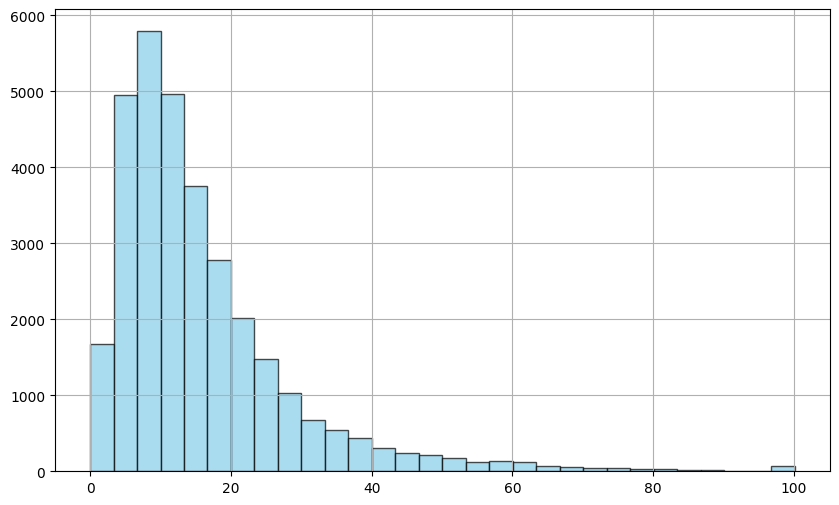

In [ ]:
# we want to drop impossible values and clip to some reasonable quantile
df_sample_analysis = df_sample_analysis[df_sample_analysis["trip_minutes"] >= 0].copy()
upper_threshold_duration = df_sample_analysis['trip_minutes'].quantile(0.998)

df_sample_analysis['trip_minutes'] = df_sample_analysis['trip_minutes'].clip(upper=upper_threshold_duration)

df_sample_analysis["trip_minutes"].hist(
    bins=30,         # Number of bins (adjust as needed)
    figsize=(10, 6),  # Figure size (width, height) in inches
    color='skyblue',   # Color of the bars
    edgecolor='black',  # Color of the bar edges
    alpha=0.7       # Transparency of the bars (0.0 to 1.0)
)


In [ ]:
df_sample.shape[0] - df_sample_analysis.shape[0]

6

In [ ]:
# lost 126 error rows - no big deal though
# let's now make into pipeline
def create_duration(df, upper_threshold):
    df_out = df.copy()
    df_out["tpep_dropoff_datetime_converted"] = pd.to_datetime(df_out['tpep_dropoff_datetime'])
    df_out["tpep_pickup_datetime_converted"] = pd.to_datetime(df_out['tpep_pickup_datetime'])
    df_out["trip_minutes"] = (df_out["tpep_dropoff_datetime_converted"] - df_out["tpep_pickup_datetime_converted"]).dt.total_seconds() / 60
    df_out = df_out[df_out["trip_minutes"] >= 0].copy()
    df_out['trip_minutes'] = df_out['trip_minutes'].clip(upper=upper_threshold)
    df_out = df_out.drop(columns=["tpep_dropoff_datetime_converted", "tpep_pickup_datetime_converted", "tpep_dropoff_datetime", "tpep_pickup_datetime"])
    return df_out

pipeline = Pipeline(steps=[
    ('create_dureation', FunctionTransformer(create_duration, kw_args={"upper_threshold": upper_threshold_duration}))
])
df_sample = pipeline.fit_transform(df_sample)

In [ ]:
df_sample.isna().sum()

passenger_count       1081
trip_distance            0
RatecodeID            1081
store_and_fwd_flag    1081
PULocationID             0
DOLocationID             0
fare_amount              0
trip_minutes             0
dtype: int64

In [ ]:
df_sample_analysis = df_sample.copy()
# passenger count
## imputation doesn't sound too bad for passenger to be honest - median.
df_sample_analysis["passenger_count"] = df_sample_analysis["passenger_count"].fillna(df_sample_analysis["passenger_count"].median())
df_sample_analysis["RatecodeID"] = df_sample_analysis["RatecodeID"].fillna(df_sample_analysis["RatecodeID"].mode()[0])
df_sample_analysis["store_and_fwd_flag"] = df_sample_analysis["store_and_fwd_flag"].fillna(df_sample_analysis["store_and_fwd_flag"].mode()[0])

In [ ]:
df_sample = df_sample_analysis
# as ref:

"""
1 = Standard rate
2 = JFK
3 = Newark
4 = Nassau or Westchester
5 = Negotiated fare
6 = Group ride
99 = Null/unknown
 """
df_sample_analysis["RatecodeID"].value_counts()

RatecodeID
1.0     30102
2.0      1211
5.0       251
3.0       105
99.0       95
4.0        37
Name: count, dtype: int64

In [ ]:
df_sample_analysis["store_and_fwd_flag"].value_counts()

store_and_fwd_flag
N    31405
Y      396
Name: count, dtype: int64

In [ ]:
pc_median = df_sample_analysis["passenger_count"].median()
rate_code_mode = df_sample_analysis["RatecodeID"].mode()[0]
store_and_fwd_mode = df_sample_analysis["store_and_fwd_flag"].mode()[0]

In [ ]:
def impute_values(df, pc_median, rate_code_mode, store_and_fwd_mode):
    df_out = df.copy()
    df_out["passenger_count"] = df_out["passenger_count"].fillna(pc_median)
    df_out["RatecodeID"] = df_out["RatecodeID"].fillna(rate_code_mode)
    df_out["store_and_fwd_flag"] = df_out["store_and_fwd_flag"].fillna(store_and_fwd_mode)
    return df_out

pipeline = Pipeline(
    steps= [
        ("impute_values", FunctionTransformer(impute_values, kw_args={'pc_median': pc_median, 'rate_code_mode': rate_code_mode, 'store_and_fwd_mode': store_and_fwd_mode}))
    ]
)
df_sample = pipeline.fit_transform(df_sample)

In [ ]:
df_sample["store_and_fwd_flag"].value_counts()

store_and_fwd_flag
N    31405
Y      396
Name: count, dtype: int64

In [ ]:
df_sample["trip_distance"].describe()

count    31801.000000
mean         3.512499
std          4.474950
min          0.000000
25%          1.100000
50%          1.900000
75%          3.590000
max         71.700000
Name: trip_distance, dtype: float64

In [ ]:
outlier = df_sample['trip_distance'].quantile(0.9999)
outlier

np.float64(52.80679999999513)

In [ ]:
def drop_outlier_milage(df, upper_threshold):
    return df[df["trip_distance"] <= upper_threshold].copy()

pipeline = Pipeline(
    steps= [
        ('drop_outlier_mileage', FunctionTransformer(drop_outlier_milage, kw_args={"upper_threshold": 100}))
    ]
)

df_sample = pipeline.fit_transform(df_sample)

In [ ]:
df_sample["trip_distance"].describe()

count    31801.000000
mean         3.512499
std          4.474950
min          0.000000
25%          1.100000
50%          1.900000
75%          3.590000
max         71.700000
Name: trip_distance, dtype: float64

In [ ]:
# examine
df_sample["RatecodeID"].value_counts(normalize=True)

RatecodeID
1.0     0.946574
2.0     0.038081
5.0     0.007893
3.0     0.003302
99.0    0.002987
4.0     0.001163
Name: proportion, dtype: float64

In [ ]:
df_sample.isna().sum()

passenger_count       0
trip_distance         0
RatecodeID            0
store_and_fwd_flag    0
PULocationID          0
DOLocationID          0
fare_amount           0
trip_minutes          0
dtype: int64

In [ ]:
df_sample["DOLocationID"].value_counts(normalize=True)

DOLocationID
236    0.042797
237    0.041288
161    0.037892
230    0.029779
170    0.028270
         ...   
84     0.000031
21     0.000031
94     0.000031
248    0.000031
53     0.000031
Name: proportion, Length: 235, dtype: float64

In [ ]:
df_sample["PULocationID"].value_counts(normalize=True)

PULocationID
132    0.047514
237    0.046288
236    0.043458
161    0.039213
162    0.033238
         ...   
20     0.000031
194    0.000031
51     0.000031
139    0.000031
126    0.000031
Name: proportion, Length: 183, dtype: float64

In [ ]:
# group ride such a small porportion, could easily just ignore it but having it doesn't necessarily hurt and scaled to 40m * porportion is 700 examples, which isn't that bad.
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(
    handle_unknown='ignore', # Handle unseen categories in test data
    drop='first',            # Create k-1 dummies, dropping the first category
    sparse_output=False      # Output a dense numpy array
)

featuresToEncode = ["RatecodeID", "store_and_fwd_flag", "PULocationID", "DOLocationID"]
encoder.fit(df_sample[featuresToEncode])

encoded_categorical_data = encoder.transform(df_sample[featuresToEncode])
encoded_feature_names = encoder.get_feature_names_out()
encoded_categorical_df = pd.DataFrame(
    encoded_categorical_data, 
    columns=encoded_feature_names, 
    index=df_sample.index
)
encoded_categorical_df

df_sample_analysis = pd.concat([
    df_sample[[item for item in df_sample.columns if item not in featuresToEncode]],
    encoded_categorical_df,
], axis=1)

In [ ]:
df_sample_analysis.columns

Index(['passenger_count', 'trip_distance', 'fare_amount', 'trip_minutes',
       'RatecodeID_2.0', 'RatecodeID_3.0', 'RatecodeID_4.0', 'RatecodeID_5.0',
       'RatecodeID_99.0', 'store_and_fwd_flag_Y',
       ...
       'DOLocationID_256', 'DOLocationID_257', 'DOLocationID_258',
       'DOLocationID_259', 'DOLocationID_260', 'DOLocationID_261',
       'DOLocationID_262', 'DOLocationID_263', 'DOLocationID_264',
       'DOLocationID_265'],
      dtype='object', length=426)

In [ ]:
def encode_categorical_features(df, encoder):
    featuresToEncode = ["RatecodeID", "store_and_fwd_flag", "PULocationID", "DOLocationID"]
    df_out = df.copy()
    encoded_categorical_data = encoder.transform(df_out[featuresToEncode])
    encoded_feature_names = encoder.get_feature_names_out()
    encoded_categorical_df = pd.DataFrame(
        encoded_categorical_data, 
        columns=encoded_feature_names, 
        index=df_out.index
    )
    return pd.concat([
        df_out[[item for item in df_out.columns if item not in featuresToEncode]],
        encoded_categorical_df,
    ], axis=1)

pipeline = Pipeline(
    steps = [
        ('encode_categorical_features', FunctionTransformer(encode_categorical_features, kw_args={"encoder": encoder}))
    ]
)

df_sample = pipeline.fit_transform(df_sample)


In [ ]:
(df_sample["fare_amount"] < 0).mean()
# wierd fare amount thing but less than 1 percent of the data, I think i should just ignore these for training and test
pipeline = Pipeline(
    steps=[
        ('ignore_negative_fare', FunctionTransformer(lambda x: x[x["fare_amount"] > 0].copy()))
    ]
)
df_sample = pipeline.fit_transform(df_sample)

In [ ]:
df_sample["fare_amount"].describe()

count    31580.000000
mean        15.070941
std         14.269372
min          0.010000
25%          7.000000
50%         10.500000
75%         16.500000
max        400.000000
Name: fare_amount, dtype: float64

In [ ]:
# 400 seems like a lot to be honest.
print(df_sample["fare_amount"].quantile(.995))
# sounds like we should cut perhaps the top off for training purposes. like > 100 seems fair outlier detection
pipeline = Pipeline(
    steps=[
        ('fare_remove_outliers', FunctionTransformer(lambda x: x[x["fare_amount"] <= 100].copy()))
    ]
)
pipeline.fit_transform(df_sample).shape, df_sample.shape

72.5


((31532, 426), (31580, 426))

In [ ]:
df_sample = pipeline.fit_transform(df_sample)
# for training only this step but yeah
# todadile forget it tho in pipeline lul

In [ ]:
# now lets build the complete pipeline
pipeline_inference = Pipeline(
    steps=[
        ("dropper", FunctionTransformer(drop_columns)),
        (
            "create_duration",
            FunctionTransformer(
                create_duration, kw_args={"upper_threshold": upper_threshold_duration}
            ),
        ),
        (
            "impute_values",
            FunctionTransformer(
                impute_values,
                kw_args={
                    "pc_median": pc_median,
                    "rate_code_mode": rate_code_mode,
                    "store_and_fwd_mode": store_and_fwd_mode,
                },
            ),
        ),
        (
            "drop_outlier_mileage",
            FunctionTransformer(drop_outlier_milage, kw_args={"upper_threshold": 100}),
        ),
        (
            "encode_categorical_features",
            FunctionTransformer(
                encode_categorical_features, kw_args={"encoder": encoder}
            ),
        ),
        (
            "ignore_negative_fare",
            FunctionTransformer(lambda x: x[x["fare_amount"] > 0].copy()),
        ),
    ]
)

df_sample_test = pipeline_inference.fit_transform(df_sample_test)

/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [2, 3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [ ]:
pipeline_inference

,steps,"[('dropper', ...), ('create_duration', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,func,<function dro...xffff0fa95360>
,inverse_func,None
,validate,False
,accept_sparse,False
,check_inverse,True
,feature_names_out,None
,kw_args,None


In [ ]:
# fare amount transformation test
## lets see if a basic model will do better with log or no log
from sklearn.linear_model import LinearRegression
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error

trainX = df_sample[[col for col in df_sample.columns if col != "fare_amount"]]
trainY = df_sample["fare_amount"]

testX, testY = df_sample_test[[col for col in df_sample_test.columns if col != "fare_amount"]], df_sample_test["fare_amount"]

model_raw = LinearRegression()
model_raw.fit(trainX, trainY)

# Get predictions on the test set (already in dollars)
y_pred_raw = model_raw.predict(testX)

# Calculate R2 and RMSE on the original dollar scale
r2_raw = r2_score(testY, y_pred_raw)
rmse_raw = np.sqrt(mean_squared_error(testY, y_pred_raw))

print("--- Model 1 Results (Predicting fare_amount) ---")
print(f"Test R²: {r2_raw:.4f}")
print(f"Test RMSE: ${rmse_raw:,.2f}")


# --- Model 2: Trained on Log Scale, Evaluated on Original Scale ---
model_log = LinearRegression()
# Fit the model on the log of the training target
model_log.fit(trainX, np.log(trainY))

# Get predictions on the test set (these will be on the log scale)
y_pred_log_scale = model_log.predict(testX)

# Back-transform the predictions to the original dollar scale
y_pred_dollar_scale = np.exp(y_pred_log_scale)

# Calculate R2 and RMSE using the back-transformed predictions and the original testY
r2_log = r2_score(testY, y_pred_dollar_scale)
rmse_log = np.sqrt(mean_squared_error(testY, y_pred_dollar_scale))

print("\n--- Model 2 Results (Predicting log(fare_amount)) ---")
print(f"Test R² (back-transformed): {r2_log:.4f}")
print(f"Test RMSE (back-transformed): ${rmse_log:,.2f}")

print("\n--- Comparison ---")
if rmse_log < rmse_raw:
    print("The model trained on log(fare_amount) has a lower RMSE and is the better predictive model.")
else:
    print("The model trained on the raw fare_amount has a lower RMSE and is the better predictive model.")

--- Model 1 Results (Predicting fare_amount) ---
Test R²: 0.7888
Test RMSE: $6.85

--- Model 2 Results (Predicting log(fare_amount)) ---
Test R² (back-transformed): -544.9549
Test RMSE (back-transformed): $348.35

--- Comparison ---
The model trained on the raw fare_amount has a lower RMSE and is the better predictive model.


In [ ]:
# log looks terrible - we will stick to fare_amount raw as response.
# let's try standardization

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

scaler = StandardScaler()

scaling_columns = [x for x in trainX.columns if x[:2] not in ['Ra', 'DO', 'PU', 'st']]
trainXScaled = trainX.copy()

trainXScaled[scaling_columns] = scaler.fit_transform(trainX[scaling_columns])

model_scaled = LinearRegression()
model_scaled.fit(trainXScaled, trainY)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [ ]:
testXScaled = testX.copy()
testXScaled[scaling_columns] = scaler.transform(testXScaled[scaling_columns])
model_scaled.score(testXScaled, testY)


0.7887919931204369

In [ ]:
# not much better from an R^2 point of view (as expected, didn't change underlying relationship) so we should search with ridge regression and scaling CV for generalization performance.
# so lets build the entire pipeline from raw data to a hyper parameter tuned linear regression model with cross validation - then run it on our test set - this will serve as the model process we will scale to spark.
## we will have a raw data to feature pipeline and then include it in a training data to hyper parameter tuned model (and give us some pointers on ranges to try to scale up to all the data)
## raw data to features

def scale_continous(df, scaler, columns):
    df_out = df.copy()
    df_out[columns] = scaler.transform(df_out[columns])
    return df_out

raw_data_to_features_pipeline = Pipeline(
    steps=[
        ("dropper", FunctionTransformer(drop_columns)),
        (
            "create_duration",
            FunctionTransformer(
                create_duration, kw_args={"upper_threshold": upper_threshold_duration}
            ),
        ),
        (
            "impute_values",
            FunctionTransformer(
                impute_values,
                kw_args={
                    "pc_median": pc_median,
                    "rate_code_mode": rate_code_mode,
                    "store_and_fwd_mode": store_and_fwd_mode,
                },
            ),
        ),
        (
            "drop_outlier_mileage",
            FunctionTransformer(drop_outlier_milage, kw_args={"upper_threshold": 100}),
        ),
        (
            "encode_categorical_features",
            FunctionTransformer(
                encode_categorical_features, kw_args={"encoder": encoder}
            ),
        ),
        (
            "ignore_negative_fare",
            FunctionTransformer(lambda x: x[x["fare_amount"] > 0].copy()),
        ),
        (
            "scale_continous",
            FunctionTransformer(scale_continous, kw_args={"scaler": scaler, "columns": scaling_columns}),
        ),
    ]
)

In [ ]:
# rebuild from raw
df_sample = pd.read_csv(file_path)
from sklearn.model_selection import train_test_split
df_sample, df_sample_test = train_test_split(df_sample, test_size=0.8)

In [ ]:

from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import Ridge
from scipy.stats import loguniform

df_sample = raw_data_to_features_pipeline.fit_transform(df_sample)

full_modeling_pipeline = Pipeline(steps=[
    ('regressor', Ridge())
])


param_distributions = {
    'regressor__alpha': loguniform(0.0000001, 1000), 
}

grid_search = RandomizedSearchCV(
    estimator=full_modeling_pipeline,
    param_distributions=param_distributions,
    n_iter=1000,  
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=1,
)

grid_search.fit(df_sample[[col for col in df_sample.columns if col != "fare_amount"]], df_sample["fare_amount"])

Fitting 5 folds for each of 1000 candidates, totalling 5000 fits


/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [2, 3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


,estimator,"Pipeline(step...r', Ridge())])"
,param_distributions,{'regressor__alpha': <scipy.stats....xffff0decf490>}
,n_iter,1000
,scoring,'neg_root_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [ ]:
best_model = grid_search.best_estimator_
print("\nThe Best Model Pipeline:")
print(best_model)
best_cv_score = grid_search.best_score_
print(f"Best Cross-Validated Score: {best_cv_score:.4f}")


The Best Model Pipeline:
Pipeline(steps=[('regressor', Ridge(alpha=np.float64(13.123436152443631)))])
Best Cross-Validated Score: -6.5384


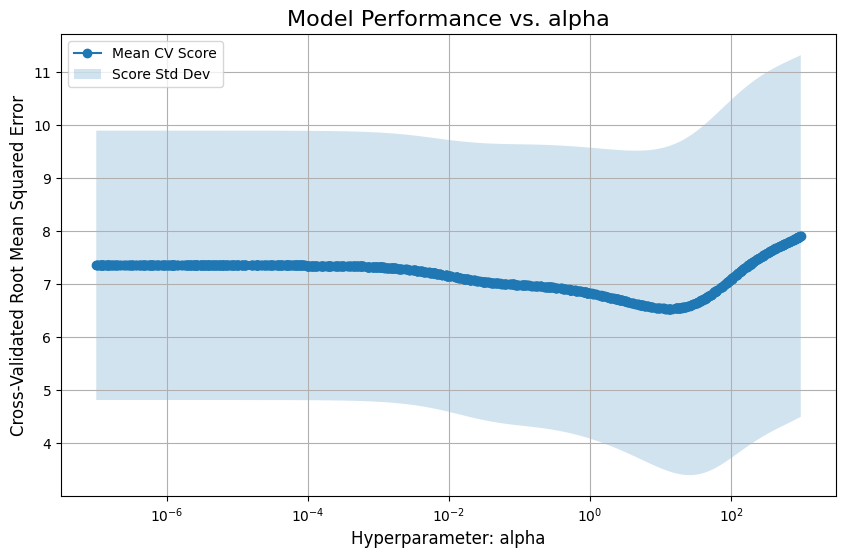

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def plot_random_search_results_1d(random_search, param_name, log_scale=True):
    """
    Plots the results of a 1D RandomizedSearchCV, sorting the values
    to create a clean line plot.

    Args:
        random_search: The fitted RandomizedSearchCV object.
        param_name (str): The name of the hyperparameter that was tuned.
        log_scale (bool): Whether to plot the hyperparameter on a log scale.
    """
    # Extract results into a DataFrame
    cv_results = pd.DataFrame(random_search.cv_results_)

    # --- THE KEY FIX: Sort the DataFrame by the hyperparameter value ---
    param_col_name = f'param_{param_name}'
    cv_results = cv_results.sort_values(by=param_col_name)
    # --------------------------------------------------------------------

    # Get the mean and standard deviation of the validation scores
    mean_scores = cv_results['mean_test_score']
    std_scores = cv_results['std_test_score']
    
    # Get the sorted hyperparameter values
    params = cv_results[param_col_name]

    # Flip the sign of the scores if they are negative
    if random_search.scoring.startswith('neg_'):
        mean_scores = -mean_scores
        score_label = random_search.scoring[4:].replace('_', ' ').title()
    else:
        score_label = random_search.scoring.replace('_', ' ').title()

    plt.figure(figsize=(10, 6))
    
    # Now that 'params' and 'mean_scores' are sorted, the plot will be a clean line
    plt.plot(params, mean_scores, 'o-', label='Mean CV Score')
    
    # Plot the uncertainty band
    plt.fill_between(params, mean_scores - std_scores, mean_scores + std_scores, 
                     alpha=0.2, label='Score Std Dev')

    plt.title(f"Model Performance vs. {param_name.split('__')[-1]}", fontsize=16)
    plt.xlabel(f"Hyperparameter: {param_name.split('__')[-1]}", fontsize=12)
    plt.ylabel(f"Cross-Validated {score_label}", fontsize=12)
    
    if log_scale:
        plt.xscale('log')
        
    plt.legend()
    plt.grid(True)
    plt.show()

# --- Example Usage ---
# Assuming 'grid_search' is your fitted RandomizedSearchCV object from the Ridge model
# and you tuned 'regressor__alpha'
if 'grid_search' in locals():
    plot_random_search_results_1d(grid_search, 'regressor__alpha', log_scale=True)

In [ ]:
# interesting the optimal looks around 0.01 to 100, probably a good place to check. in full run
df_sample_test = raw_data_to_features_pipeline.transform(df_sample_test)

/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [2, 3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [ ]:
from sklearn.metrics import root_mean_squared_error
y_test_predicted = grid_search.best_estimator_.predict(df_sample_test[[col for col in df_sample_test.columns if col != "fare_amount"]])
-1 * root_mean_squared_error(df_sample_test["fare_amount"], y_test_predicted)

-5.369997830982376

In [ ]:
# since I tested the sample it can be the seed starting point for the pipeline to scale up, then I can explore different things (like what if I drop, what if I change imputation strategy)
# if i run into an error or something else I can debug and decide it then, sample should have taken care of most of snags though
# we should build seperate pipelines for data splitter (test set vs training),  feature engineering (produce features, and statistics for inference/training pipeline) , then model training, then a pipeline for inference.

In [ ]:
spark.stop()

In [ ]:
from pyspark.sql import SparkSession
import os

spark = SparkSession.builder.appName("DatasetSplitter") \
    .master(f"spark://spark-master:7077") \
    .config("spark.executor.memory", "2g") \
    .getOrCreate()

In [ ]:
def create_train_test_split(spark, config):
    """
    Reads the full raw dataset, performs a train/test split,
    and writes the splits back to a persistent location.

    Args:
        spark (SparkSession): The active SparkSession.
        config (dict): A dictionary containing configuration parameters like
                       input_path, train_output_path, test_output_path, etc.
    """
    print("--- Starting Data Splitting Job ---")

    # --- 1. Load the Full Raw Dataset ---
    print(f"Reading full dataset from: {config['input_path']}")
    full_df = spark.read.parquet(config['input_path']).repartition(500)
    
    total_count = full_df.count()
    print(f"Successfully loaded full dataset with {total_count:,} rows.")

    # --- 3. Perform the Train/Test Split ---
    train_fraction = config.get('train_fraction', 0.8)
    test_fraction = 1.0 - train_fraction
    seed = config.get('seed', 42)
    
    print(f"Splitting data into {train_fraction*100}% train and {test_fraction*100}% test sets...")
    
    train_df, test_df = full_df.randomSplit([train_fraction, test_fraction], seed=seed)
    

    full_df.unpersist()
    

    print(f"\nWriting training data to: {config['train_output_path']}")
    train_df.write.mode("overwrite").parquet(config['train_output_path'])
    
    print(f"Writing test data to: {config['test_output_path']}")
    test_df.write.mode("overwrite").parquet(config['test_output_path'])

    print("\n--- Data Splitting Job Finished Successfully! ---")

create_train_test_split(spark, {
    "input_path": "/home/jovyan/workspace/.data/*parquet",
    "train_output_path": "/home/jovyan/workspace/.data/out_train_raw/",
    "test_output_path": "/home/jovyan/workspace/.data/out_test_raw/"
})

--- Starting Data Splitting Job ---
Reading full dataset from: /home/jovyan/workspace/.data/*parquet


Successfully loaded full dataset with 39,656,098 rows.
Splitting data into 80.0% train and 19.999999999999996% test sets...

Writing training data to: /home/jovyan/workspace/.data/out_train_raw/


Writing test data to: /home/jovyan/workspace/.data/out_test_raw/



--- Data Splitting Job Finished Successfully! ---


In [188]:
spark.stop()

In [189]:
!mkdir -p .data/inference

In [190]:
%%writefile .data/inference/custom_transformers.py
import pandas as pd
import json
import os

from pyspark.ml import Estimator, Model, Transformer, Pipeline
from pyspark.ml.param.shared import *
from pyspark.ml.util import DefaultParamsReadable, DefaultParamsWritable, MLReadable, MLReader, MLWritable, DefaultParamsWriter, MLWriter, DefaultParamsReader
from pyspark.sql import functions as F
from pyspark.sql.types import StructType
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler, StandardScaler
from pyspark.sql import SparkSession

class RawFeatureCalculator(Transformer,  DefaultParamsReadable, DefaultParamsWritable):
    """
    A stateless Transformer that performs initial calculations and creates a
    raw data quality report as a side effect.
    """

    def __init__(self):
        super(RawFeatureCalculator, self).__init__()

    def _transform(self, dataset):
        print("--- Stage 1: Calculating Raw Features ---")
        
        # --- A. Perform stateless calculations ---
        df_out = dataset.withColumn("trip_minutes",
            (F.unix_timestamp(F.col("tpep_dropoff_datetime")) - F.unix_timestamp(F.col("tpep_pickup_datetime"))) / 60.0
        )
        
        return df_out

# ==============================================================================
# STAGE 2: Stateful Data Cleaner and Imputer (Estimator + Model)
# ==============================================================================

# Helper class for writing JSON with NumPy types if Spark returns them
class NpEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, np.integer): return int(obj)
        if isinstance(obj, np.floating): return float(obj)
        if isinstance(obj, np.ndarray): return obj.tolist()
        return super(NpEncoder, self).default(obj)

class DataCleanerAndImputerModelWriter(MLWriter):
    def __init__(self, instance):
        super(DataCleanerAndImputerModelWriter, self).__init__()
        self.instance = instance

    def saveImpl(self, path):
        # 1. Use the default writer to save standard metadata and ANY PARAMS.
        DefaultParamsWriter(self.instance).save(path)
        
        # 2. Define a path for our custom, learned attributes (the state).
        custom_data_path = os.path.join(path, "custom_model_data")
        os.makedirs(custom_data_path, exist_ok=True)
        
        # 3. Create a dictionary of all the state we need to save.
        state_to_save = {
            "imputation_values": self.instance.imputation_values,
            "clipping_bounds": self.instance.clipping_bounds
            # NOTE: We don't save the config params here, the default writer handles them.
        }
        
        # 4. Save the state as a JSON file.
        with open(os.path.join(custom_data_path, "learned_state.json"), "w") as f:
            json.dump(state_to_save, f, indent=4, cls=NpEncoder)

# ==============================================================================
# The Custom Reader for our Model
# ==============================================================================
class DataCleanerAndImputerModelReader(MLReader):
    def __init__(self, cls):
        super(DataCleanerAndImputerModelReader, self).__init__()
        self.cls = cls

    def load(self, path):
        # 1. Use the default reader to load metadata and instantiate the class with its saved PARAMS.
        instance = DefaultParamsReader(self.cls).load(path)
        
        # 2. Define the path to our custom data.
        custom_data_path = os.path.join(path, "custom_model_data", "learned_state.json")
        
        # 3. Load our custom state from the JSON file.
        with open(custom_data_path, "r") as f:
            loaded_state = json.load(f)
            
        # 4. Populate the instance with the loaded state.
        instance.imputation_values = loaded_state["imputation_values"]
        instance.clipping_bounds = loaded_state["clipping_bounds"]

        return instance
# --- The "Model" part (the Transformer that gets produced by .fit()) ---
class DataCleanerAndImputerModel(Model, MLWritable, MLReadable, HasOutputCol):
    """
    The fitted Transformer. This version is fully serializable AND correctly
    handles both learned attributes and configuration parameters.
    """
    # --- STEP 1: DEFINE THE PARAMS ---
    # All configuration passed from the Estimator must be defined here as a Param.
    filterCondition = Param(Params._dummy(), "filterCondition", "SQL string for filtering")
    labelCol = Param(Params._dummy(), "labelCol", "Name of the target/label column")
    labelFilterCondition = Param(Params._dummy(), "labelFilterCondition", "Filter for the label")
    invalidRecordsPath = Param(Params._dummy(), "invalidRecordsPath", "Path for invalid records")
    transformReportPath = Param(Params._dummy(), "transformReportPath", "Path for transform report")


    def __init__(self, imputation_values=None, clipping_bounds=None, **kwargs):
        super(DataCleanerAndImputerModel, self).__init__()
        
        # --- STEP 2: HANDLE LEARNED ATTRIBUTES ---
        # These are regular Python attributes, not Params.
        self.imputation_values = imputation_values or {}
        self.clipping_bounds = clipping_bounds or {}
        
        # --- STEP 3: SET THE PARAMS ---
        # Initialize the Params with default values
        self._setDefault(filterCondition=None, labelCol=None, labelFilterCondition=None,
                         invalidRecordsPath=None, transformReportPath=None)
        # Use the _set method to populate the Params from the kwargs
        self._set(**kwargs)

    def setParams(self, **kwargs):
        return self._set(**kwargs)
    def write(self):
        """Returns our custom writer instance."""
        return DataCleanerAndImputerModelWriter(self)

    @classmethod
    def read(cls):
        """Returns our custom reader instance."""
        return DataCleanerAndImputerModelReader(cls)
    def _transform(self, dataset):
        print("--- [Transform] Applying Cleaning, Imputation, Clipping, and Filtering ---")
        
        input_count = dataset.count()
        if input_count == 0:
            print("Warning: Input dataset for transform is empty. Returning empty DataFrame.")
            dataset.unpersist()
            return dataset # Return the empty df with original schema


        df_out = dataset
        
        # Initialize a dictionary to hold our audit report for this transformation
        transform_report = {
            "timestamp": pd.Timestamp.now().isoformat(),
            "input_rows": input_count,
            "imputation_counts": {},
            "clipping_stats": {},
            "filtered_out_counts": {}
        }

        # --- 1. Apply learned imputation ---
        if self.imputation_values:
            print(f"Applying learned imputation for: {list(self.imputation_values.keys())}")
            for col_name in self.imputation_values.keys():
                if col_name in df_out.columns:
                    null_count = df_out.filter(F.col(col_name).isNull()).count()
                    transform_report["imputation_counts"][col_name] = {
                        "count": null_count,
                        "fraction": null_count / input_count if input_count > 0 else 0
                    }
            # Apply imputation in one go
            df_out = df_out.fillna(self.imputation_values)

        # --- 2. Apply learned clipping bounds (Winsorizing) ---
        if self.clipping_bounds:
            print(f"Applying clipping to columns: {list(self.clipping_bounds.keys())}")
            for col_name, bounds in self.clipping_bounds.items():
                if col_name in df_out.columns:
                    lower_b = bounds['lower']
                    upper_b = bounds['upper']
                    
                    # Count how many rows will be clipped
                    clipped_lower_count = df_out.filter(F.col(col_name) < lower_b).count()
                    clipped_upper_count = df_out.filter(F.col(col_name) > upper_b).count()
                    total_clipped = clipped_lower_count + clipped_upper_count
                    
                    # Add stats to the report
                    transform_report["clipping_stats"][col_name] = {
                        "clipped_lower_count": clipped_lower_count,
                        "clipped_upper_count": clipped_upper_count,
                        "total_clipped_count": total_clipped,
                        "total_clipped_fraction": total_clipped / input_count
                    }
                    
                    # Apply the clipping
                    df_out = df_out.withColumn(col_name,
                        F.when(F.col(col_name) < lower_b, lower_b)
                         .when(F.col(col_name) > upper_b, upper_b)
                         .otherwise(F.col(col_name))
                    )

        # --- 3. Filter data based on FEATURES and save invalid records ---
        if self.getOrDefault(self.filterCondition):
            print(f"Filtering features with condition: {self.filterCondition}")
            df_after_feature_filter = df_out.filter(self.getOrDefault(self.filterCondition))
            df_invalid_features = df_out.filter(f"NOT ({self.getOrDefault(self.filterCondition)})")
            
            invalid_feature_count = df_invalid_features.count()
            transform_report["filtered_out_counts"]["by_feature_rules"] = {
                "count": invalid_feature_count,
                "fraction": invalid_feature_count/ input_count
            }
            
            
            if self.getOrDefault(self.invalidRecordsPath) and invalid_feature_count > 0:
                print(f"Saving {invalid_feature_count:,} records failing feature rules")
                # Append a timestamp to the path to avoid overwriting between train/test runs
                path = self.invalidRecordsPath.replace(".parquet", f"_features_{pd.Timestamp.now().strftime('%Y%m%d_%H%M%S')}.parquet")
                df_invalid_features.write.mode("overwrite").parquet(path)
        else:
            df_after_feature_filter = df_out
        
        # --- 4. Handle the label column on the feature-clean data ---
        df_final_clean = df_after_feature_filter
        if self.getOrDefault(self.labelCol) and self.getOrDefault(self.labelCol) in df_after_feature_filter.columns:
            print(f"Processing label column: '{self.labelCol}'")
            
            # 4a. Apply label-specific filtering
            if self.getOrDefault(self.labelFilterCondition):
                print(f"Filtering label with condition: {self.getOrDefault(self.labelFilterCondition)}")
                df_final_clean = df_after_feature_filter.filter(self.getOrDefault(self.labelFilterCondition))
                df_invalid_label = df_after_feature_filter.filter(f"NOT ({self.getOrDefault(self.labelFilterCondition)})")
                
                invalid_label_count = df_invalid_label.count()
                transform_report["filtered_out_counts"]["by_label_rules"] = {
                    "count": invalid_label_count,
                    "fraction": invalid_label_count / input_count
                }

                if self.getOrDefault(self.invalidRecordsPath) and invalid_label_count > 0:
                    path = self.getOrDefault(self.invalidRecordsPath).replace(".parquet", f"_label_{pd.Timestamp.now().strftime('%Y%m%d_%H%M%S')}.parquet")
                    print(f"Saving {invalid_label_count:,} records failing label rules")
                    df_invalid_label.write.mode("overwrite").parquet(path)

        # --- 5. Finalize and save the transform-time report (side effect) ---
        transform_report["output_rows"] = df_final_clean.count()

        if self.getOrDefault(self.transformReportPath):
            path = self.getOrDefault(self.transformReportPath).replace(".json", f"_{pd.Timestamp.now().strftime('%Y%m%d_%H%M%S')}.json")
            print(f"Saving transform-time audit report to: {path}")
            os.makedirs(os.path.dirname(path), exist_ok=True)
            with open(path, 'w') as f:
                json.dump(transform_report, f, indent=4)
        
        return df_final_clean

# --- The "Estimator" part (the learning object) ---
class DataStats(Estimator, DefaultParamsReadable, DefaultParamsWritable):
    """
    The Estimator. Learns imputation statistics from the clean portion
    of the training data.
    """
    filterCondition = Param(Params._dummy(), "filterCondition", "record filtering condition")
    invalidRecordsPath = Param(Params._dummy(), "invalidRecordsPath", "where to put the bad records")
    numericalImputeCols = Param(Params._dummy(), "numericalImputeCols", "numerical columns to impute")
    categoricalImputeCols = Param(Params._dummy(), "categoricalImputeCols", "categorical columns to impute")
    numericalClipCols = Param(Params._dummy(), "numericalClipCols", "List of numerical columns to calculate clipping bounds for")
    labelCol = Param(Params._dummy(), "labelCol", "label column name")
    statsOutputPath = Param(Params._dummy(), "statsOutputPath", "Path to save the learned statistics JSON report")
    labelFilterCondition = Param(Params._dummy(), "labelFilterCondition", "label filtering condition")
    transformReportPath = Param(Params._dummy(), "transformReportPath", "path for transformation report")

    def __init__(self, **kwargs):
        super(DataStats, self).__init__()
        self._setDefault(filterCondition=None, invalidRecordsPath=None, numericalImputeCols=[],
                         categoricalImputeCols=[], labelCol=None, numericalClipCols=[], statsOutputPath=None, labelFilterCondition=None, transformReportPath=None)
        self.setParams(**kwargs)

    def setParams(self, **kwargs):
        return self._set(**kwargs)

    def _fit(self, dataset):
        print("--- [Fit] Learning Imputation Stats and clipping stats ---")
        
        filter_cond = self.getOrDefault(self.filterCondition)
        num_impute_cols = self.getOrDefault(self.numericalImputeCols)
        cat_impute_cols = self.getOrDefault(self.categoricalImputeCols)
        num_clip_cols = self.getOrDefault(self.numericalClipCols) 
        stats_path = self.getOrDefault(self.statsOutputPath)
        
        # Filter to get the clean data for learning
        df_clean = dataset.filter(filter_cond)
        
        learned_stats = {
            "imputation_values": {},
            "clipping_bounds": {}
        }
        
        # Learn imputation values
        imputation_values = {}
        if num_impute_cols:
            median_exprs = [F.expr(f"percentile_approx({c}, 0.5)").alias(c) for c in num_impute_cols]
            medians = df_clean.agg(*median_exprs).first().asDict()
            imputation_values.update(medians)
        clipping_bounds = {}
        if num_clip_cols:
            # Create aggregation expressions for the 0.5th and 99.5th percentiles
            quantile_exprs = []
            for c in num_clip_cols:
                quantile_exprs.append(F.expr(f"percentile_approx({c}, 0.005)").alias(f"{c}_lower_bound"))
                quantile_exprs.append(F.expr(f"percentile_approx({c}, 0.995)").alias(f"{c}_upper_bound"))

            # Execute the aggregation
            bounds_row = df_clean.agg(*quantile_exprs).first()
            for c in num_clip_cols:
                clipping_bounds[c] = {
                    "lower": bounds_row[f"{c}_lower_bound"],
                    "upper": bounds_row[f"{c}_upper_bound"]
                }
        if cat_impute_cols:
            for c in cat_impute_cols:
                mode_val = df_clean.groupBy(c).count().orderBy(F.desc("count")).first()[0]
                imputation_values[c] = mode_val
        learned_stats["imputation_values"] = imputation_values
        print(f"Learned imputation values: {imputation_values}")
        learned_stats["clipping_bounds"] = clipping_bounds
        print(f"Learned clipping bounds: {clipping_bounds}")


        if stats_path:
            print(f"Saving learned statistics to: {stats_path}")
            os.makedirs(os.path.dirname(stats_path), exist_ok=True)
            with open(stats_path, 'w') as f:
                # Use a custom JSON encoder for NumPy types if necessary
                class NpEncoder(json.JSONEncoder):
                    def default(self, obj):
                        if isinstance(obj, np.integer):
                            return int(obj)
                        if isinstance(obj, np.floating):
                            return float(obj)
                        if isinstance(obj, np.ndarray):
                            return obj.tolist()
                        return super(NpEncoder, self).default(obj)
                json.dump(learned_stats, f, indent=4, cls=NpEncoder)
        
        config_params = {
            self.filterCondition.name: self.getOrDefault(self.filterCondition),
            self.labelCol.name: self.getOrDefault(self.labelCol),
            self.labelFilterCondition.name: self.getOrDefault(self.labelFilterCondition),
            self.invalidRecordsPath.name: self.getOrDefault(self.invalidRecordsPath),
            self.transformReportPath.name: self.getOrDefault(self.transformReportPath)
        }
        
        # Return the fitted Model, passing the learned state as keyword arguments
        # and the configuration state as a dictionary to the kwargs of the constructor.
        return DataCleanerAndImputerModel(
            imputation_values=imputation_values,
            clipping_bounds=clipping_bounds,
            **config_params
        )

from pyspark.ml import Transformer
from pyspark.ml.param.shared import HasInputCols, Param, Params, TypeConverters
from pyspark.sql.types import StructType


class ColumnDropper(Transformer, HasInputCols, DefaultParamsReadable, DefaultParamsWritable):
    """
    A custom Spark ML Transformer that drops one or more specified columns
    from a DataFrame.
    """

    def __init__(self, inputCols=None):
        """
        Initializes the ColumnDropper transformer.

        Args:
            inputCols (list of str, optional): A list of column names to drop. 
                                              Defaults to None.
        """
        super(ColumnDropper, self).__init__()
        # We use 'inputCols' as the parameter name to be consistent with other Spark transformers.
        self._setDefault(inputCols=[])
        if inputCols is not None:
            self.set(self.inputCols, inputCols)

    def setInputCols(self, value):
        """Sets the value of inputCols."""
        return self._set(inputCols=value)
    
    # The _transform method is the core of any Transformer.
    def _transform(self, dataset):
        """
        Transforms the input dataset by dropping the specified columns.

        Args:
            dataset (DataFrame): The input Spark DataFrame.

        Returns:
            DataFrame: The transformed DataFrame with columns dropped.
        """
        cols_to_drop = self.getInputCols()
        
        if not cols_to_drop:
            print("ColumnDropper: No columns specified to drop. Returning original DataFrame.")
            return dataset
            
        print(f"ColumnDropper: Dropping columns: {cols_to_drop}")
        
        # The '*' unpacks the list into individual arguments for the .drop() method
        return dataset.drop(*cols_to_drop)

    # The following methods are required for ML Pipeline persistence and schema validation.

    def copy(self, extra=None):
        """
        Creates a copy of this instance with the same UID and params.
        This is required for Spark pipelines.
        """
        if extra is None:
            extra = dict()
        return self.__class__(inputCols=self.getInputCols())

    def transformSchema(self, schema):
        """
        Transforms the input schema to the output schema by removing the specified columns.
        Spark uses this to validate the pipeline before running data through it.
        
        Args:
            schema (StructType): The input schema.

        Returns:
            StructType: The output schema.
        """
        cols_to_drop = self.getInputCols()
        
        # Create a new list of schema fields, excluding the ones to be dropped
        new_columns = [field for field in schema.fields if field.name not in cols_to_drop]
        
        # Return a new StructType with the updated fields
        return StructType(new_columns)

Writing .data/inference/custom_transformers.py


In [3]:
import sys
sys.path.append("./.data/inference") # so we can pull it
from custom_transformers import RawFeatureCalculator, DataStats, ColumnDropper

from pyspark.ml import Estimator, Model, Transformer, Pipeline
from pyspark.ml.param.shared import *
from pyspark.ml.util import DefaultParamsReadable, DefaultParamsWritable, MLReadable, MLReader, MLWritable, DefaultParamsWriter, MLWriter, DefaultParamsReader
from pyspark.sql import functions as F
from pyspark.sql.types import StructType
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler, StandardScaler
from pyspark.sql import SparkSession

In [198]:
if __name__ == "__main__":
    
    spark = SparkSession.builder.appName("FeaturePipeline").master(f"spark://spark-master:7077").config("spark.executor.memory", "6g").getOrCreate()
    
    raw_train_df = spark.read.parquet("/home/jovyan/workspace/.data/out_train_raw")
    
    print("--- Original Raw Training Data ---")
    raw_train_df.show()
    
    # --- 2. Define the stages of your FeaturePipeline ---
    
    # Stage 1: Raw Feature Calculator
    raw_feature_calculator = RawFeatureCalculator()

    # Stage 2: Data Cleaner and Imputer
    cleaner_and_imputer = DataStats(
        filterCondition="trip_distance > 0 AND trip_minutes > 0",
        invalidRecordsPath="/tmp/spark_artifacts/invalid_records.parquet",
        numericalImputeCols=["passenger_count"],
        categoricalImputeCols=["RatecodeID", "store_and_fwd_flag"],
        numericalClipCols=["trip_minutes", "trip_distance"],
        labelCol="fare_amount",
        statsOutputPath="/tmp/spark_artifacts/training_stats.json",
        transformReportPath="/tmp/spark_artifacts/transformation_report.json",
        labelFilterCondition= "fare_amount > 0 AND fare_amount < 100"
    )
    

    dropper = ColumnDropper(inputCols=[
        "tpep_pickup_datetime",
        "tpep_dropoff_datetime",
        "total_amount",
        "VendorID",
        "tip_amount",
        "tolls_amount",
        "payment_type",
        "extra",
        "mta_tax",
        "improvement_surcharge",
        "congestion_surcharge",
        "airport_fee"
    ])
    categorical_cols_to_encode = ["RatecodeID", "store_and_fwd_flag", "PULocationID", "DOLocationID"]
    
    # Create the lists of StringIndexer and OneHotEncoder stages
    indexers = [
        StringIndexer(inputCol=c, outputCol=f"{c}_idx", handleInvalid='keep')
        for c in categorical_cols_to_encode
    ]
    
    encoders = [
        OneHotEncoder(inputCol=f"{c}_idx", outputCol=f"{c}_ohe")
        for c in categorical_cols_to_encode
    ]

    # --- Stage 5: Vector Assembler and Scaler for Final Features ---
    
    # Define your final numerical features (after imputation/clipping)
    final_numerical_cols = ["passenger_count", "trip_minutes", "trip_distance"]
    
    # Define the inputs for the assembler: all OHE columns + all numerical columns
    assembler_input_cols = [f"{c}_ohe" for c in categorical_cols_to_encode] + final_numerical_cols
    
    # Create the VectorAssembler
    assembler = VectorAssembler(
        inputCols=assembler_input_cols,
        outputCol="unscaled_features"
    )
    
    # Create the StandardScaler to scale the final vector
    scaler = StandardScaler(
        inputCol="unscaled_features",
        outputCol="features" # This is the conventional final feature column name
    )

    cols_to_clean_up = ["unscaled_features"] + final_numerical_cols + categorical_cols_to_encode
    for c in categorical_cols_to_encode:
        cols_to_clean_up.append(f"{c}_idx")
        cols_to_clean_up.append(f"{c}_ohe")
        
    final_dropper = ColumnDropper(inputCols=cols_to_clean_up)
    # --- 3. Assemble the FeaturePipeline Estimator ---
    FeaturePipeline = Pipeline(stages=[
        raw_feature_calculator,
        cleaner_and_imputer,
        dropper,
        *indexers,  # Unpack the lists of stages
        *encoders,
        assembler,
        scaler,
        final_dropper
    ])

    # --- 4. Fit the pipeline on the raw training data ---
    print("\n\n FITTING THE FEATURE PIPELINE ".center(80, "="))
    fitted_feature_pipeline = FeaturePipeline.fit(raw_train_df)
    print("\n\n TRANSFORMING THE TRAINING DATA ".center(80, "="))
    transformed_train_df = fitted_feature_pipeline.transform(raw_train_df)
    print("--- Training Features ---")
    transformed_train_df.show()
    features_output_path = "/home/jovyan/workspace/.data/processed/train_features.parquet"

    print(f"\n--- Saving final features to: {features_output_path} ---")
    feature_pipeline_path = "/home/jovyan/workspace/.data/artifacts/fitted_feature_pipeline.spark"
    print(f"Saving the fitted feature pipeline to: {feature_pipeline_path}")
    fitted_feature_pipeline.write().overwrite().save(feature_pipeline_path)

    # Use the .write API.
    # 'overwrite' mode will delete the directory if it already exists, which is
    # useful for re-running your pipeline.
    transformed_train_df.write.mode("overwrite").parquet(features_output_path)

    print("done.")

--- Original Raw Training Data ---
+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+
|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|RatecodeID|store_and_fwd_flag|PULocationID|DOLocationID|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|congestion_surcharge|airport_fee|
+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+
|       1| 2022-01-01 00:54:01|  2022-01-01 01:04:21|            2.0|          2.0|       1.0|                 N|         162|          79|           1|

Learned imputation values: {'passenger_count': 1.0, 'RatecodeID': 1.0, 'store_and_fwd_flag': 'N'}
Learned clipping bounds: {'trip_minutes': {'lower': 1.0333333333333334, 'upper': 77.51666666666667}, 'trip_distance': {'lower': 0.17, 'upper': 21.71}}
Saving learned statistics to: /tmp/spark_artifacts/training_stats.json
--- [Transform] Applying Cleaning, Imputation, Clipping, and Filtering ---
Applying learned imputation for: ['passenger_count', 'RatecodeID', 'store_and_fwd_flag']
Applying clipping to columns: ['trip_minutes', 'trip_distance']
Filtering features with condition: DataCleanerAndImputerModel_b921bd37e85e__filterCondition
Processing label column: 'DataCleanerAndImputerModel_b921bd37e85e__labelCol'
Filtering label with condition: fare_amount > 0 AND fare_amount < 100


Saving 266,416 records failing label rules


Saving transform-time audit report to: /tmp/spark_artifacts/transformation_report_20251009_162725.json
ColumnDropper: Dropping columns: ['tpep_pickup_datetime', 'tpep_dropoff_datetime', 'total_amount', 'VendorID', 'tip_amount', 'tolls_amount', 'payment_type', 'extra', 'mta_tax', 'improvement_surcharge', 'congestion_surcharge', 'airport_fee']



 TRANSFORMING THE TRAINING DATA =======================
--- Stage 1: Calculating Raw Features ---
--- [Transform] Applying Cleaning, Imputation, Clipping, and Filtering ---
Applying learned imputation for: ['passenger_count', 'RatecodeID', 'store_and_fwd_flag']
Applying clipping to columns: ['trip_minutes', 'trip_distance']
Filtering features with condition: DataCleanerAndImputerModel_b921bd37e85e__filterCondition
Processing label column: 'DataCleanerAndImputerModel_b921bd37e85e__labelCol'
Filtering label with condition: fare_amount > 0 AND fare_amount < 100
Saving 266,416 records failing label rules


Saving transform-time audit report to: /tmp/spark_artifacts/transformation_report_20251009_162742.json
ColumnDropper: Dropping columns: ['tpep_pickup_datetime', 'tpep_dropoff_datetime', 'total_amount', 'VendorID', 'tip_amount', 'tolls_amount', 'payment_type', 'extra', 'mta_tax', 'improvement_surcharge', 'congestion_surcharge', 'airport_fee']
ColumnDropper: Dropping columns: ['unscaled_features', 'passenger_count', 'trip_minutes', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'RatecodeID_idx', 'RatecodeID_ohe', 'store_and_fwd_flag_idx', 'store_and_fwd_flag_ohe', 'PULocationID_idx', 'PULocationID_ohe', 'DOLocationID_idx', 'DOLocationID_ohe']
--- Training Features ---
+-----------+--------------------+
|fare_amount|            features|
+-----------+--------------------+
|        9.5|(536,[0,7,15,288,...|
|        6.0|(536,[0,7,29,274,...|
|       10.0|(536,[0,7,14,288,...|
|       17.5|(536,[0,7,20,323,...|
|        7.0|(536,[0,7,25,305,...|
|      

done.


In [199]:
print("\n\n TRANSFORMING THE TEST DATA ".center(20, "="))
raw_test_df = spark.read.parquet("/home/jovyan/workspace/.data/out_test_raw/*parquet")
transformed_test_df = fitted_feature_pipeline.transform(raw_test_df)
print("--- Training Features ---")
transformed_test_df.show()
features_output_path = "/home/jovyan/workspace/.data/processed/test_features.parquet"



 TRANSFORMING THE TEST DATA 
--- Stage 1: Calculating Raw Features ---
--- [Transform] Applying Cleaning, Imputation, Clipping, and Filtering ---
Applying learned imputation for: ['passenger_count', 'RatecodeID', 'store_and_fwd_flag']
Applying clipping to columns: ['trip_minutes', 'trip_distance']
Filtering features with condition: DataCleanerAndImputerModel_b921bd37e85e__filterCondition
Processing label column: 'DataCleanerAndImputerModel_b921bd37e85e__labelCol'
Filtering label with condition: fare_amount > 0 AND fare_amount < 100
Saving 66,135 records failing label rules
Saving transform-time audit report to: /tmp/spark_artifacts/transformation_report_20251009_162830.json
ColumnDropper: Dropping columns: ['tpep_pickup_datetime', 'tpep_dropoff_datetime', 'total_amount', 'VendorID', 'tip_amount', 'tolls_amount', 'payment_type', 'extra', 'mta_tax', 'improvement_surcharge', 'congestion_surcharge', 'airport_fee']
ColumnDropper: Dropping columns: ['unscaled_features', 'passenger_count', 

In [200]:
spark.stop()

In [201]:
import os
import json
import pandas as pd # For timestamp in report name
from pyspark.sql import SparkSession
from pyspark.ml.regression import LinearRegression
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
from pyspark.ml.evaluation import RegressionEvaluator
import numpy as np # For defining the hyperparameter search space

def train_and_tune_model(spark, config):
    """
    Loads pre-processed features, tunes a Ridge regression model using
    CrossValidator, and saves the best model found.
    """
    print("--- Starting Model Training and Tuning Job ---")

    # --- 1. Load the Pre-processed Training Features ---
    print(f"Loading training features from: {config['train_features_path']}")
    train_df = spark.read.parquet(config['train_features_path']).repartition(1000) 
    train_df.cache()

    print(f"Loaded {train_df.count():,} rows for training.")
    
    # --- 2. Define the Estimator (the Model to be Tuned) ---
    # Ridge Regression in Spark is implemented as LinearRegression with l1_ratio (elasticNetParam) = 0.
    lr = LinearRegression(
        featuresCol="features",
        labelCol=config['label_col'],
        elasticNetParam=0.0  # This makes it a Ridge (L2) regression
    )
    
    # --- 3. Define the Hyperparameter Grid ---
    # You identified a good range from your earlier analysis.
    # We will use ParamGridBuilder to create a grid of values to test.
    # np.logspace is great for searching over a wide range of values.
    # This will create values like [0.01, 0.012, 0.015, ..., 80, 100]
    alpha_values = np.logspace(-3, 2, 20).tolist() # 20 values from 0.01 to 100

    paramGrid = ParamGridBuilder() \
        .addGrid(lr.regParam, alpha_values) \
        .build()
        
    print(f"\nCreated hyperparameter grid with {len(paramGrid)} combinations for 'alpha' (regParam).")

    # --- 4. Define the Evaluator ---
    # This is what CrossValidator will use to judge which model is best.
    # The metric should be calculated on the log scale, as that's what the model predicts.
    evaluator = RegressionEvaluator(
        labelCol=config['label_col'],
        predictionCol="prediction",
        metricName="rmse" # Root Mean Squared Error
    )
    
    # --- 5. Set up the CrossValidator ---
    # CrossValidator is Spark's equivalent of GridSearchCV/RandomizedSearchCV
    crossval = CrossValidator(
        estimator=lr,
        estimatorParamMaps=paramGrid,
        evaluator=evaluator,
        numFolds=config.get('cv_folds', 5), # Use 3 folds for speed, 5 is also common
        parallelism=1, # Number of models to train in parallel
        seed=config.get('seed', 42)
    )

    # --- 6. Run the Tuning and Training Process (The .fit() call) ---
    print("\nStarting Cross-Validation to find the best model...")
    # This is the most computationally intensive step.
    # Spark will train (number of alphas * numFolds) models.
    cv_model = crossval.fit(train_df)
    print("--- Cross-Validation complete! ---")

    # The cv_model object now holds the BEST model found during the search,
    # automatically re-trained on the entire training dataset.
    
    # --- 7. Save the Final Model Artifact ---
    print(f"\nSaving the best model to: {config['model_output_path']}")
    cv_model.bestModel.write().overwrite().save(config['model_output_path'])
    train_df.unpersist()
    # --- 8. (Side Effect) Save the CV Metrics ---
    # It's great practice to save the results of your tuning.
    print(f"Saving CV metrics to: {config['metrics_output_path']}")
    
    cv_metrics = {
        "best_alpha": cv_model.bestModel.getRegParam(),
        "avg_rmse_per_fold": cv_model.avgMetrics,
        "params_tested": [p.values() for p in paramGrid]
    }
    
    os.makedirs(os.path.dirname(config['metrics_output_path']), exist_ok=True)
    with open(config['metrics_output_path'], 'w') as f:
        # A simple way to write the metrics out
        f.write(f"Best Alpha (regParam): {cv_metrics['best_alpha']}\n\n")
        f.write("Average RMSE for each parameter combination:\n")
        for params, metric in zip(cv_metrics['params_tested'], cv_metrics['avg_rmse_per_fold']):
            f.write(f"Params: {list(params)} -> Avg RMSE: {metric:.4f}\n")

    print("\n--- Model Training Job Finished Successfully! ---")
    
    return cv_model.bestModel
job_config = {
    "train_features_path": "/home/jovyan/workspace/.data/processed/train_features.parquet",
    "label_col": "fare_amount",
    "model_output_path": "/home/jovyan/workspace/.data/artifacts/ridge_model.spark",
    "metrics_output_path": "/home/jovyan/workspace/.data/artifacts/ridge_cv_metrics.txt",
    "cv_folds": 5,
    "seed": 42
}
from pyspark.sql import SparkSession
spark = SparkSession.builder.appName("Trainer").master(f"spark://spark-master:7077").config("spark.executor.memory", "6g").getOrCreate()
train_and_tune_model(spark, job_config)

--- Starting Model Training and Tuning Job ---
Loading training features from: /home/jovyan/workspace/.data/processed/train_features.parquet


Loaded 31,458,691 rows for training.

Created hyperparameter grid with 20 combinations for 'alpha' (regParam).

Starting Cross-Validation to find the best model...


25/10/09 16:29:45 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
25/10/09 16:29:45 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.VectorBLAS
25/10/09 16:29:45 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.lapack.JNILAPACK


--- Cross-Validation complete! ---

Saving the best model to: /home/jovyan/workspace/.data/artifacts/ridge_model.spark
Saving CV metrics to: /home/jovyan/workspace/.data/artifacts/ridge_cv_metrics.txt

--- Model Training Job Finished Successfully! ---


LinearRegressionModel: uid=LinearRegression_ed79dba76bf0, numFeatures=536

In [202]:
spark.stop()

In [1]:
import os
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import ArrayType, DoubleType
from pyspark.ml.linalg import SparseVector, DenseVector

def create_sklearn_sample(spark, config):
    """
    Loads final engineered features from Spark, takes a sample, un-vectorizes
    the 'features' column, and saves the result as a single CSV file for use
    with scikit-learn and pandas.

    Args:
        spark (SparkSession): The active SparkSession.
        config (dict): A dictionary of job parameters.
    """
    print("--- Starting Job to Create Scikit-learn Sample ---")

    # --- 1. Load the Pre-processed Training Features ---
    print(f"Loading features from: {config['features_path']}")
    features_df = spark.read.parquet(config['features_path'])
    features_df.cache()
    total_rows = features_df.count()
    print(f"Loaded {total_rows:,} rows with engineered features.")

    # --- 2. Take a Sample ---
    sample_size = config.get("sample_size", 50000)
    if total_rows > 0:
        fraction = min(sample_size / total_rows, 1.0) # Ensure fraction is not > 1
    else:
        fraction = 0.0
        
    seed = config.get("seed", 42)

    print(f"Sampling {fraction:.4%} of the data to get ~{sample_size:,} rows...")
    df_sample = features_df.sample(fraction=fraction, seed=seed)
    df_sample.cache()
    print(f"Sample contains {df_sample.count():,} rows.")

    # Unpersist the large DataFrame
    features_df.unpersist()

    # --- 3. Un-vectorize the 'features' Column ---
    print("\nUn-vectorizing the 'features' column...")

    # A. Define a UDF to convert Spark's Vector type to a standard Python list
    def to_dense_array(v):
        if isinstance(v, (SparseVector, DenseVector)):
            return v.toArray().tolist()
        return None

    to_dense_array_udf = F.udf(to_dense_array, ArrayType(DoubleType()))

    # B. Apply the UDF
    df_with_array = df_sample.withColumn("features_array", to_dense_array_udf(F.col("features")))

    # C. Get the size of the feature vector to create new column names
    try:
        vector_size = df_sample.select("features").first()[0].size
        print(f"Detected feature vector size of: {vector_size}")
    except Exception as e:
        print(f"Could not determine vector size from metadata, defaulting to 536. Error: {e}")
        vector_size = 536 # Fallback based on your previous output

    # D. "Explode" the array into individual columns
    feature_cols_expr = [F.col("features_array")[i].alias(f"feature_{i}") for i in range(vector_size)]
    
    df_wide = df_with_array.select(
        config['label_col'],
        *feature_cols_expr
    )

    # --- 4. Collect to Pandas and Save as CSV ---
    print("\nCollecting the sampled, wide DataFrame into pandas...")
    # This action brings the data to the driver. It should only be done on a sample.
    pandas_df = df_wide.toPandas()
    print(f"Successfully collected {len(pandas_df)} rows into a pandas DataFrame.")
    
    # Define the output path
    csv_output_path = config['csv_output_path']
    os.makedirs(os.path.dirname(csv_output_path), exist_ok=True)
    
    print(f"Saving the sample as a CSV to: {csv_output_path}")
    pandas_df.to_csv(csv_output_path, index=False)
    print("CSV sample created successfully.")
    
    df_sample.unpersist()

if __name__ == "__main__":
    
    job_config = {
        # Path to your final features created by the feature engineering pipeline
        "features_path": "/home/jovyan/workspace/.data/processed/train_features.parquet",
        
        # The name of your label column in that DataFrame
        "label_col": "fare_amount",
        
        # Path where the final CSV will be saved (inside the container)
        "csv_output_path": "/home/jovyan/workspace/.data/artifacts/sklearn_ready_sample.csv",
        
        # How many rows you want in your final sample
        "sample_size": 30000,
        "seed": 42
    }
    
    # Initialize SparkSession inside the dev-client container
    spark = SparkSession.builder \
        .appName("CreateSklearnSample") \
        .master("spark://spark-master:7077") \
        .config("spark.executor.memory", "6g").getOrCreate()

    # Run the job
    create_sklearn_sample(spark, job_config)
    
    spark.stop()

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/10/09 17:14:36 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


--- Starting Job to Create Scikit-learn Sample ---
Loading features from: /home/jovyan/workspace/.data/processed/train_features.parquet


Loaded 31,458,691 rows with engineered features.
Sampling 0.0954% of the data to get ~30,000 rows...


Sample contains 30,218 rows.

Un-vectorizing the 'features' column...
Detected feature vector size of: 536



25/10/09 17:14:49 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


Successfully collected 30218 rows into a pandas DataFrame.
Saving the sample as a CSV to: /home/jovyan/workspace/.data/artifacts/sklearn_ready_sample.csv
CSV sample created successfully.


In [4]:
# load from saved state and run on test data
import os
from pyspark.sql import SparkSession
from pyspark.ml import PipelineModel

# must have all classes defined in pipeline being loaded.
def run_test_feature_generation(spark, config):
    """
    Loads a pre-fitted feature engineering pipeline and applies it to new
    (e.g., test) data to create a consistent set of features.
    """
    print("--- Starting Feature Engineering Job ---")

    # --- 1. Load the Raw Test Data ---
    print(f"Loading raw test data from: {config['raw_test_path']}")
    try:
        raw_test_df = spark.read.parquet(config['raw_test_path'])
        print(f"Loaded {raw_test_df.count():,} raw records for inference.")
    except Exception as e:
        print(f"ERROR: Could not load test data. Path: {config['raw_test_path']}")
        print(e)
        raise

    # --- 2. Load the FITTED Feature Pipeline Model ---
    # This is the primary artifact from your training workflow.
    # It is a Transformer, not an Estimator.
    print(f"Loading fitted feature pipeline from: {config['feature_pipeline_path']}")
    try:
        fitted_feature_pipeline = PipelineModel.load(config['feature_pipeline_path'])
    except Exception as e:
        print(f"ERROR: Could not load the fitted pipeline model.")
        print(e)
        raise
        
    
    print("\nApplying the fitted pipeline to the test data...")
    test_features_df = fitted_feature_pipeline.transform(raw_test_df)
    print(fitted_feature_pipeline)
    print("\n--- Transformation of test data complete. ---")
    print("--- Sample of Final Test Features ---")
    test_features_df.show(5, truncate=False)
    test_features_df.printSchema()

    # --- 4. Save the Final, Model-Ready Test Features ---
    print(f"\nSaving final test features to: {config['features_output_path']}")
    test_features_df.write.mode("overwrite").parquet(config['features_output_path'])
    print("--- Test features saved successfully. ---")
    
    return test_features_df


if __name__ == "__main__":
    
    # Configuration for the inference job
    job_config = {
        # Input: The raw test set from your data splitter job
        "raw_test_path": "/home/jovyan/workspace/.data/out_test_raw",
        
        # Input: The path to the fitted feature pipeline you saved during training
        "feature_pipeline_path": "/home/jovyan/workspace/.data/artifacts/fitted_feature_pipeline.spark",
        
        # Output: The final, clean features for the test set
        "features_output_path": "/home/jovyan/workspace/.data/processed/test_features.parquet"
    }
    
    spark = SparkSession.builder \
        .appName("Feature Engineering") \
        .master("spark://spark-master:7077") \
        .config("spark.executor.memory", "6g").getOrCreate()

    # --- Run the Job ---
    run_test_feature_generation(spark, job_config)
    
    # --- Stop the Spark Session ---
    spark.stop()
    print("\Feature Generation job complete.")

--- Starting Feature Engineering Job ---
Loading raw test data from: /home/jovyan/workspace/.data/out_test_raw
Loaded 7,930,991 raw records for inference.
Loading fitted feature pipeline from: /home/jovyan/workspace/.data/artifacts/fitted_feature_pipeline.spark

Applying the fitted pipeline to the test data...
--- Stage 1: Calculating Raw Features ---
--- [Transform] Applying Cleaning, Imputation, Clipping, and Filtering ---
Applying learned imputation for: ['passenger_count', 'RatecodeID', 'store_and_fwd_flag']
Applying clipping to columns: ['trip_minutes', 'trip_distance']
Filtering features with condition: DataCleanerAndImputerModel_b921bd37e85e__filterCondition
Processing label column: 'DataCleanerAndImputerModel_b921bd37e85e__labelCol'
Filtering label with condition: fare_amount > 0 AND fare_amount < 100
Saving 66,135 records failing label rules


Saving transform-time audit report to: /tmp/spark_artifacts/transformation_report_20251009_171620.json
ColumnDropper: Dropping columns: ['tpep_pickup_datetime', 'tpep_dropoff_datetime', 'total_amount', 'VendorID', 'tip_amount', 'tolls_amount', 'payment_type', 'extra', 'mta_tax', 'improvement_surcharge', 'congestion_surcharge', 'airport_fee']
ColumnDropper: Dropping columns: ['unscaled_features', 'passenger_count', 'trip_minutes', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'RatecodeID_idx', 'RatecodeID_ohe', 'store_and_fwd_flag_idx', 'store_and_fwd_flag_ohe', 'PULocationID_idx', 'PULocationID_ohe', 'DOLocationID_idx', 'DOLocationID_ohe']
PipelineModel_76f39ee828e7

--- Transformation of test data complete. ---
--- Sample of Final Test Features ---
+-----------+------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|fare_amount|features   

--- Test features saved successfully. ---
\Feature Generation job complete.


--- Starting Final Model Evaluation Job ---
Loading test features from: /home/jovyan/workspace/.data/processed/test_features.parquet


Loaded 7,864,856 rows of test data.
Loading final trained model from: /home/jovyan/workspace/.data/artifacts/ridge_model.spark
Making predictions on the test set...


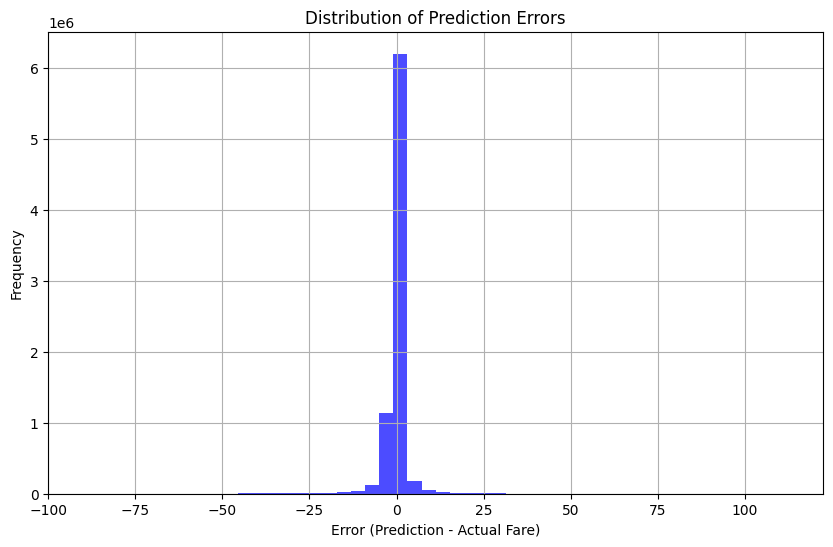

Summary statistics for the prediction error:
+-------+--------------------+
|summary|               error|
+-------+--------------------+
|  count|             7864856|
|   mean|0.001268114461413...|
| stddev|  3.7523710807410913|
|    min|  -89.95266000700732|
|    max|  112.44635436461509|
+-------+--------------------+


--- Performance  ---
RMSE on test set: 3.7524
R-squared on test set: 0.9135

--- Evaluation Job Finished Successfully! ---
+-----------+--------------------+------------------+
|fare_amount|            features|        prediction|
+-----------+--------------------+------------------+
|       16.5|(536,[0,7,31,277,...| 15.93516042907657|
|        5.0|(536,[0,8,49,279,...| 6.093422999888092|
|       24.0|(536,[0,7,18,341,...|22.963881895374442|
|        6.5|(536,[0,7,14,274,...| 7.603309037477905|
|        7.0|(536,[0,7,16,277,...|  7.44877926241297|
|        4.5|(536,[0,7,38,271,...| 5.705470914303338|
|        9.5|(536,[0,7,28,277,...| 9.339956513044537|
|        7.

In [5]:
from pyspark.sql import SparkSession
from pyspark.ml.regression import LinearRegressionModel
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.sql.functions import col
import matplotlib.pyplot as plt


def evaluate_final_model(spark, config):
    """
    Loads a final trained model and pre-processed test features,
    makes predictions, and evaluates the final performance.
    """
    print("--- Starting Final Model Evaluation Job ---")

    # --- 1. Load the Pre-processed TEST Features ---
    # These were created by your Feature Engineering pipeline using the test split.
    print(f"Loading test features from: {config['test_features_path']}")
    try:
        test_features_df = spark.read.parquet(config['test_features_path'])
        test_count = test_features_df.count()
        if test_count == 0:
            print("ERROR: Test features DataFrame is empty. Cannot evaluate.")
            return
        print(f"Loaded {test_count:,} rows of test data.")
    except Exception as e:
        print(f"ERROR: Could not load test features. Path: {config['test_features_path']}")
        print(e)
        raise

    # --- 2. Load the FINAL TRAINED Model ---
    # This is the 'bestModel' that was saved from your CrossValidator run.
    print(f"Loading final trained model from: {config['model_path']}")
    try:
        # For a LinearRegression model, you load it with its specific class
        final_model = LinearRegressionModel.load(config['model_path'])
    except Exception as e:
        print(f"ERROR: Could not load the final model.")
        print(e)
        raise

    # --- 3. Make Predictions on the Test Set ---
    # The .transform() method is Spark's equivalent of .predict()
    # It will add a new column named 'prediction' by default.
    print("Making predictions on the test set...")
    predictions_df = final_model.transform(test_features_df)

    # --- 4. Evaluate the Performance ---
    # The label and predictions are on the log scale, so we can evaluate RMSE there.
    # We will also back-transform to get the RMSE in dollars for better business interpretation.

    # 4a. Evaluate on the Log Scale
    evaluator = RegressionEvaluator(
        labelCol=config['label_col'],
        predictionCol="prediction",
        metricName="rmse"
    )
    rmse = evaluator.evaluate(predictions_df)
    
    evaluator_r2 = RegressionEvaluator(
        labelCol=config['label_col'],
        predictionCol="prediction",
        metricName="r2"
    )
    r2 = evaluator_r2.evaluate(predictions_df)
    # --- 3. Calculate the error ---
    # The error is the difference between the prediction and the actual fare amount
    predictions_with_error_df = predictions_df.withColumn("error", col("prediction") - col("fare_amount"))

    # --- 4. Collect the errors to the driver for plotting ---
    # Be cautious with .toPandas() on large datasets.
    # For very large data, consider sampling first: .sample(withReplacement=False, fraction=0.1)
    errors_pd = predictions_with_error_df.select("error").toPandas()

    # --- 5. Plot the distribution of errors ---
    plt.figure(figsize=(10, 6))
    plt.hist(errors_pd['error'], bins=50, color='blue', alpha=0.7)
    plt.title('Distribution of Prediction Errors')
    plt.xlabel('Error (Prediction - Actual Fare)')
    plt.ylabel('Frequency')
    plt.grid(True)
    plt.show()

    # You can also get summary statistics of the error in Spark
    print("Summary statistics for the prediction error:")
    predictions_with_error_df.select("error").describe().show()
    print("\n--- Performance  ---")
    print(f"RMSE on test set: {rmse:.4f}")
    print(f"R-squared on test set: {r2:.4f}")
    print("\n--- Evaluation Job Finished Successfully! ---")
    predictions_df.show()
    # You could save the predictions for further analysis if needed
    # predictions_dollar_scale.write.mode("overwrite").parquet(config['predictions_output_path'])


if __name__ == "__main__":
    
    job_config = {
        # Input: The final, engineered test features
        "test_features_path": "/home/jovyan/workspace/.data/processed/test_features.parquet",
        
        # Input: The path to the final trained model you saved
        "model_path": "/home/jovyan/workspace/.data/artifacts/ridge_model.spark",
        
        # The name of your label column in the features DataFrame
        "label_col": "fare_amount", 
    }
    spark = SparkSession.builder \
        .appName("Inference") \
        .master("spark://spark-master:7077") \
        .config("spark.executor.memory", "6g").getOrCreate()

    # --- Run the Job ---
    evaluate_final_model(spark, job_config)
    
    spark.stop()

In [6]:
import pandas as pd
from pyspark.sql import SparkSession
from pyspark.ml import PipelineModel
from pyspark.ml.regression import LinearRegressionModel
from pyspark.ml.feature import OneHotEncoderModel, StringIndexerModel, VectorAssembler
import json
import os

def get_feature_names_from_pipeline(pipeline_model: PipelineModel) -> list:
    """
    Inspects a fitted PipelineModel to reconstruct the ordered list of all
    individual feature names, correctly handling the interaction between
    StringIndexer(handleInvalid='keep') and OneHotEncoder.
    """
    final_feature_names = []
    
    vector_assembler = None
    for stage in pipeline_model.stages:
        if isinstance(stage, VectorAssembler):
            vector_assembler = stage
            break
            
    if not vector_assembler:
        raise RuntimeError("Could not find a VectorAssembler stage in the loaded pipeline.")

    assembler_input_cols = vector_assembler.getInputCols()
    stage_outputs = {stage.getOutputCol(): stage for stage in pipeline_model.stages if hasattr(stage, 'getOutputCol')}

    for col_name in assembler_input_cols:
        if col_name not in stage_outputs:
            final_feature_names.append(col_name)
            continue

        stage = stage_outputs[col_name]
        
        if isinstance(stage, OneHotEncoderModel):
            indexer_input_col = stage.getInputCol()
            
            if indexer_input_col in stage_outputs and isinstance(stage_outputs[indexer_input_col], StringIndexerModel):
                indexer_model = stage_outputs[indexer_input_col]
                original_col_name = indexer_model.getInputCol()
                
                # Get the original labels learned during fitting
                base_labels = indexer_model.labels
                
                # *** THE KEY FIX IS HERE ***
                # Check if the indexer was configured to add an extra index for unseen values.
                if indexer_model.getHandleInvalid() == "keep":
                    # If so, the OneHotEncoder will see an additional potential category.
                    effective_num_categories = len(base_labels) + 1
                else:
                    effective_num_categories = len(base_labels)
                
                # The final size of the OHE vector depends on the dropLast parameter.
                if stage.getDropLast():
                    output_size = effective_num_categories - 1
                else:
                    output_size = effective_num_categories
                
                # We generate names for the first 'output_size' categories.
                # Because dropLast=True drops the LAST category (which is the 'unseen' one
                # when handleInvalid='keep'), the names are simply the base labels.
                for i in range(output_size):
                     # If the number of outputs is same as base labels, the names are the base labels.
                     if i < len(base_labels):
                        category_name = base_labels[i]
                        final_feature_names.append(f"{original_col_name}_ohe_{category_name}")
                     else: # This case is rare but handles edge cases
                        final_feature_names.append(f"{original_col_name}_ohe_unknown_{i}")

            else:
                raise RuntimeError(f"Could not find the StringIndexerModel for OHE stage with input '{indexer_input_col}'")
        else:
            final_feature_names.append(col_name)
            
    return final_feature_names


def inspect_and_save_model_weights(spark, config):
    """
    Loads a saved feature pipeline and a trained model, robustly extracts
    feature names from the pipeline itself, and saves the weights to a JSON file.
    """
    print("--- Starting Model Inspection Job ---")

    print(f"Loading fitted feature pipeline from: {config['feature_pipeline_path']}")
    try:
        fitted_feature_pipeline = PipelineModel.load(config['feature_pipeline_path'])
    except Exception as e:
        print(f"ERROR: Could not load the fitted pipeline model. \n{e}")
        raise
        
    print(f"Loading trained regression model from: {config['model_path']}")
    try:
        lr_model = LinearRegressionModel.load(config['model_path'])
    except Exception as e:
        print(f"ERROR: Could not load the regression model. \n{e}")
        raise

    print("\nExtracting feature names directly from the pipeline model...")
    try:
        feature_names = get_feature_names_from_pipeline(fitted_feature_pipeline)
        print(f"Successfully extracted {len(feature_names)} feature names.")
    except Exception as e:
        print(f"ERROR: Failed to extract feature names from pipeline. \n{e}")
        raise

    coefficients = lr_model.coefficients
    intercept = lr_model.intercept
    
    if len(feature_names) != len(coefficients):
        raise ValueError(
            f"CRITICAL ERROR: Mismatch between extracted feature names and model coefficients. "
            f"({len(feature_names)} names vs {len(coefficients)} coefficients)."
        )

    weights_df = pd.DataFrame({
        'feature': feature_names,
        'weight': coefficients.tolist()
    })
    weights_df['abs_weight'] = weights_df['weight'].abs()
    weights_df = weights_df.sort_values(by='abs_weight', ascending=False).drop(columns=['abs_weight'])
    
    coefficient_list = weights_df.to_dict(orient='records')
    
    output_data = {
        "model_type": "Ridge Regression (LinearRegression with L2)",
        "intercept": intercept,
        "coefficient_count": len(coefficient_list),
        "coefficients": coefficient_list
    }

    output_path = config['weights_output_path']
    print(f"\nSaving model weights to: {output_path}")
    
    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    
    with open(output_path, 'w') as f:
        json.dump(output_data, f, indent=4)
        
    print("--- Model weights saved successfully. ---")


if __name__ == "__main__":
    
    job_config = {
        "feature_pipeline_path": "/home/jovyan/workspace/.data/artifacts/fitted_feature_pipeline.spark",
        "model_path": "/home/jovyan/workspace/.data/artifacts/ridge_model.spark",
        "weights_output_path": "/home/jovyan/workspace/.data/artifacts/ridge_model_weights.json"
    }
    
    spark = SparkSession.builder \
        .appName("Model Weight Exporter") \
        .master("spark://spark-master:7077") \
        .getOrCreate()

    # If your pipeline uses custom Python classes, their definitions must be
    # available in the script's scope for the pipeline to load.
    
    inspect_and_save_model_weights(spark, job_config)
    
    spark.stop()
    print("\nModel inspection job complete.")

--- Starting Model Inspection Job ---
Loading fitted feature pipeline from: /home/jovyan/workspace/.data/artifacts/fitted_feature_pipeline.spark


Loading trained regression model from: /home/jovyan/workspace/.data/artifacts/ridge_model.spark

Extracting feature names directly from the pipeline model...
Successfully extracted 536 feature names.

Saving model weights to: /home/jovyan/workspace/.data/artifacts/ridge_model_weights.json
--- Model weights saved successfully. ---

Model inspection job complete.


In [7]:
import json
import pandas as pd

def analyze_model_weights(config):
    """
    Loads model weights from a JSON file and prints the features with the
    highest and lowest weights.
    """
    print(f"--- Loading Model Weights from: {config['weights_path']} ---")

    try:
        with open(config['weights_path'], 'r') as f:
            data = json.load(f)
    except FileNotFoundError:
        print(f"ERROR: The file was not found at the specified path: {config['weights_path']}")
        return
    except json.JSONDecodeError:
        print(f"ERROR: The file at {config['weights_path']} is not a valid JSON file.")
        return

    # Extract the intercept and the list of coefficients
    intercept = data.get('intercept', 'N/A')
    coefficients = data.get('coefficients', [])

    if not coefficients:
        print("Could not find any coefficients in the JSON file.")
        return

    # --- Convert to a Pandas DataFrame for Easy Analysis ---
    # The list of dictionaries format is perfect for creating a DataFrame
    weights_df = pd.DataFrame(coefficients)

    # Ensure the 'weight' column is numeric
    weights_df['weight'] = pd.to_numeric(weights_df['weight'])

    print(f"\nModel Intercept (Base Fare): ${intercept:,.4f}")
    print(f"Analyzed {len(weights_df)} total features.")

    # --- 1. Find the Features with the GREATEST (Most Positive) Weights ---
    # These features increase the fare the most.
    
    # Sort the DataFrame by the 'weight' column in descending order
    greatest_weights = weights_df.sort_values(by='weight', ascending=False)
    
    print("\n" + " TOP FEATURES WITH GREATEST POSITIVE WEIGHTS (Increases Fare) ".center(80, "="))
    # .head(N) shows the top N features. Let's show the top 15.
    print(greatest_weights.head(config.get('top_n', 15)))


    # --- 2. Find the Features with the LOWEST (Most Negative) Weights ---
    # These features decrease the fare the most.
    
    # Sort the DataFrame by the 'weight' column in ascending order
    lowest_weights = weights_df.sort_values(by='weight', ascending=True)

    print("\n" + " TOP FEATURES WITH LOWEST NEGATIVE WEIGHTS (Decreases Fare) ".center(80, "="))
    print(lowest_weights.head(config.get('top_n', 15)))
    print("\n" + "="*80)


if __name__ == "__main__":
    
    # Configuration for the analysis script
    analysis_config = {
        "weights_path": "/home/jovyan/workspace/.data/artifacts/ridge_model_weights.json",
        "top_n": 15 # The number of top/bottom features to display
    }

    # Set pandas display options for better readability in the console
    pd.set_option('display.max_rows', 50)
    pd.set_option('display.width', 100)

    # --- Run the Analysis ---
    analyze_model_weights(analysis_config)

--- Loading Model Weights from: /home/jovyan/workspace/.data/artifacts/ridge_model_weights.json ---

Model Intercept (Base Fare): $9.3448
Analyzed 536 total features.

========= TOP FEATURES WITH GREATEST POSITIVE WEIGHTS (Increases Fare) =========
                 feature    weight
0          trip_distance  6.633114
1           trip_minutes  3.753586
2     RatecodeID_ohe_5.0  2.390562
4     DOLocationID_ohe_1  0.706169
5   PULocationID_ohe_265  0.645437
6   DOLocationID_ohe_138  0.460137
7   PULocationID_ohe_138  0.411107
8     RatecodeID_ohe_3.0  0.401252
9   DOLocationID_ohe_132  0.328061
10    PULocationID_ohe_1  0.287987
11  DOLocationID_ohe_265  0.254902
12    RatecodeID_ohe_4.0  0.218994
13    RatecodeID_ohe_2.0  0.208828
14  PULocationID_ohe_132  0.198748
15  PULocationID_ohe_216  0.172863

========== TOP FEATURES WITH LOWEST NEGATIVE WEIGHTS (Decreases Fare) ==========
                 feature    weight
3     RatecodeID_ohe_1.0 -1.147547
21   RatecodeID_ohe_99.0 -0.130789
25  

In [8]:
# size of model on disk
import os

def get_dir_size(path='.'):
    total_size = 0
    for dirpath, dirnames, filenames in os.walk(path):
        for f in filenames:
            fp = os.path.join(dirpath, f)
            # skip if it is symbolic link
            if not os.path.islink(fp):
                total_size += os.path.getsize(fp)
    return total_size

model_path = "/home/jovyan/workspace/.data/artifacts/ridge_model.spark"
disk_size_bytes = get_dir_size(model_path)
disk_size_mb = disk_size_bytes / (1024 * 1024)

print(f"The model size on disk is: {disk_size_bytes} bytes")
print(f"The model size on disk is: {disk_size_mb:.2f} MB")

The model size on disk is: 7030 bytes
The model size on disk is: 0.01 MB


In [9]:
spark.stop()

In [10]:
## let's now do online inference with mlflow

In [11]:
%%writefile .data/inference/mlflow_wrapper.py
import mlflow
import pandas as pd
from pyspark.sql import SparkSession
from pyspark.ml import PipelineModel
from pyspark.ml.regression import LinearRegressionModel

# We import from the .py file we just created
from custom_transformers import RawFeatureCalculator, DataCleanerAndImputerModel, DataStats, ColumnDropper
from pyspark.sql.types import StructType, StructField, StringType, LongType, DoubleType, TimestampType

class SparkModelWrapper(mlflow.pyfunc.PythonModel):
    def load_context(self, context):
        self.spark = SparkSession.builder.appName("MLflowInference").master("local[*]").getOrCreate()
        feature_pipeline_path = context.artifacts["feature_pipeline"]
        model_path = context.artifacts["model"]
        self.feature_pipeline = PipelineModel.load(feature_pipeline_path)
        self.model = LinearRegressionModel.load(model_path)

    def predict(self, context, model_input):
        print("\n--- PREDICT FUNCTION CALLED ---")
        
        # --- THE CRITICAL FIX IS HERE ---
        # The input 'model_input' is a Pandas DataFrame with string dates.
        # We must convert them to datetime objects in Pandas before giving them to Spark.
        print("Converting string columns to datetime objects in Pandas...")
        model_input['tpep_pickup_datetime'] = pd.to_datetime(model_input['tpep_pickup_datetime'])
        model_input['tpep_dropoff_datetime'] = pd.to_datetime(model_input['tpep_dropoff_datetime'])
        
        # Now that the columns are proper datetime objects, Spark can handle them.
        # We can let Spark infer the schema, but explicitly setting it is more robust.
        expected_schema = StructType([
            StructField("tpep_pickup_datetime", TimestampType(), True),
            StructField("tpep_dropoff_datetime", TimestampType(), True),
            StructField("passenger_count", LongType(), True),
            StructField("trip_distance", DoubleType(), True),
            StructField("RatecodeID", LongType(), True),
            StructField("store_and_fwd_flag", StringType(), True),
            StructField("PULocationID", LongType(), True),
            StructField("DOLocationID", LongType(), True),
        ])
        # Create the Spark DataFrame using the enforced schema.
        spark_df = self.spark.createDataFrame(model_input, schema=expected_schema)
        
        print("Input DataFrame Schema after enforcing types:")
        spark_df.printSchema()
        print(f"Rows before feature pipeline: {spark_df.count()}")
        
        # Apply the feature engineering pipeline
        features_df = self.feature_pipeline.transform(spark_df)
        
        post_count = features_df.count()
        print(f"Rows after feature pipeline: {post_count}")

        if post_count == 0:
            print("!!! WARNING: All rows were filtered out. !!!")
            return pd.DataFrame([], columns=["prediction"])

        # Make predictions
        predictions_df = self.model.transform(features_df)

        print("Prediction successful. Returning results.")
        return predictions_df.select("prediction").toPandas()
print("mlflow_wrapper.py has been created.")

Writing .data/inference/mlflow_wrapper.py


In [1]:
! rm -rf .data/inference/spark_pyfunc_model/
# Now, in the same cell, run the saving logic
import sys
sys.path.append("./.data/inference") # so we can pull it
import mlflow
mlflow.set_tracking_uri("./.data/inference/mlruns")
from mlflow_wrapper import SparkModelWrapper

# --- Configuration ---
PYSPARK_VERSION = "3.5.6" # The version of Spark you trained with
feature_pipeline_path = "/home/jovyan/workspace/.data/artifacts/fitted_feature_pipeline.spark"
model_path = "/home/jovyan/workspace/.data/artifacts/ridge_model.spark"
mlflow_model_path = "/home/jovyan/workspace/.data/inference/spark_pyfunc_model"

conda_env = {
    "channels": ["conda-forge"],
    "dependencies": [
        "python=3.10",
        "pip",
        {"pip": [f"pyspark=={PYSPARK_VERSION}", "mlflow", "pandas", "numpy"]},
    ],
}

# --- Save the Model ---
# This packages everything into the 'spark_pyfunc_model' directory
mlflow.pyfunc.save_model(
    path=mlflow_model_path,
    python_model=SparkModelWrapper(),
    artifacts={
        "feature_pipeline": feature_pipeline_path,
        "model": model_path
    },
    # CRITICAL: This tells MLflow to include our newly created .py files in the package
    code_paths=["/home/jovyan/workspace/.data/inference/custom_transformers.py", "/home/jovyan/workspace/.data/inference/mlflow_wrapper.py"],
    conda_env=conda_env
)

/usr/local/lib/python3.10/dist-packages/mlflow/pyfunc/utils/data_validation.py:186: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(
/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


mlflow_wrapper.py has been created.


In [2]:
import subprocess

# Define the command to run
command = [
    "mlflow",
    "models",
    "serve",
    "-m", "/home/jovyan/workspace/.data/inference/spark_pyfunc_model",
    "-p", "5001",
    "--env-manager", "local",
]

# Define log files for the server's output
stdout_log = './.data/inference/mlflow_server.log'
stderr_log = './.data/inference/mlflow_server_error.log'

# Open the log files
stdout_file = open(stdout_log, 'w')
stderr_file = open(stderr_log, 'w')

# Use subprocess.Popen to start the command as a new background process
# We redirect its stdout and stderr to our log files.
print("Starting MLflow server in the background...")
server_process = subprocess.Popen(command, stdout=stdout_file, stderr=stderr_file)

print(f"Server started successfully with PID: {server_process.pid}")
print(f"Logs are being written to '{stdout_log}' and '{stderr_log}'.")
print("You can now run other cells.")

Starting MLflow server in the background...
Server started successfully with PID: 7474
Logs are being written to './.data/inference/mlflow_server.log' and './.data/inference/mlflow_server_error.log'.
You can now run other cells.


In [4]:
import subprocess
import json

# 1. Create your input data as a Python dictionary
payload = {
    "dataframe_split": {
        "columns": [
            "tpep_pickup_datetime",
            "tpep_dropoff_datetime",
            "passenger_count",
            "trip_distance",
            "RatecodeID",
            "store_and_fwd_flag",
            "PULocationID",
            "DOLocationID"
        ],
        "data": [
            [
                "2022-01-01T01:18:08.000",
                "2022-01-01T01:19:08.000",
                1,
                1.70,
                1,
                "N",
                249,
                49
            ]
        ]
    }
}

# 2. Convert the dictionary to a JSON string
json_payload = json.dumps(payload)

# 3. Define the command as a list of arguments
command = [
    "curl",
    "-X", "POST",
    "-H", "Content-Type:application/json",
    "--data", json_payload,
    "http://localhost:5001/invocations"
]

# 4. Run the command and capture the output
result = subprocess.run(command, capture_output=True, text=True)

# 5. Print the server's response in a clean way
if result.returncode == 0:
    print("--- Server Response ---")
    # Parse the JSON response for pretty printing
    response_json = json.loads(result.stdout)
    print(json.dumps(response_json, indent=2))
else:
    print("--- Error ---")
    print(result.stderr)

--- Error ---
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed

  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
curl: (7) Failed to connect to localhost port 5001 after 0 ms: Connection refused



In [11]:
!pkill -f mlflow

### Deploying an endpoint rather than local:
1. Set up the `inference-requirements.txt` (in `/cluster/` directory):
```
pyspark==3.5.6
mlflow>=2.5.0
pandas
numpy
```

1. Create a dockerfile for it: `inference.dockerfile` (assuming in `/cluster/` directory.)
```
# Start from a lightweight, official Python image.
FROM python:3.10-slim

# Install the Java version that is available in this base image's repository.
RUN apt-get update && \
    apt-get install -y --no-install-recommends openjdk-21-jre-headless && \
    apt-get clean && \
    rm -rf /var/lib/apt/lists/*

# --- END OF FIX ---
# Set a working directory inside the container.
WORKDIR /app

# Copy the specific requirements file for this service.
COPY ./cluster/inference-requirements.txt .

# Install the Python libraries.
RUN pip install --no-cache-dir -r inference-requirements.txt

# --- Self-Contained Model ---
# Copy the saved MLflow model directory into the image.
# This makes the image a complete, portable, and self-contained artifact.
# It assumes 'spark_pyfunc_model' is in the same directory as this Dockerfile.
COPY ./spark_pyfunc_model ./spark_pyfunc_model

# Expose the port that the MLflow server will run on.
EXPOSE 5001

# The command to run when the container starts.
# --host 0.0.0.0 is CRITICAL for accepting connections from outside the container.
CMD ["mlflow", "models", "serve", "-m", "./spark_pyfunc_model", "--host", "0.0.0.0", "-p", "5001", "--env-manager", "local"]
```
1. Add service to our docker-compose (in `/cluster/`)
```
  inference-server:
    build:
      context: ..
      dockerfile: cluster/inference.Dockerfile
    environment:
      - JAVA_HOME=/usr/lib/jvm/java-21-openjdk-arm64
    ports:
      # Map port 5001 on your host to port 5001 in the container.
      # This is how your notebook can "hit" the endpoint.
      - "5001:5001"
    # No volumes or Spark environment variables needed here, as the image is self-contained.

```
1. You can hit it with:
```
import subprocess
import json

# 1. Create your input data as a Python dictionary
payload = {
    "dataframe_split": {
        "columns": [
            "tpep_pickup_datetime",
            "tpep_dropoff_datetime",
            "passenger_count",
            "trip_distance",
            "RatecodeID",
            "store_and_fwd_flag",
            "PULocationID",
            "DOLocationID"
        ],
        "data": [
            [
                "2022-01-01T01:18:08.000",
                "2022-01-01T01:19:08.000",
                1,
                1.70,
                1,
                "N",
                249,
                49
            ]
        ]
    }
}

# 2. Convert the dictionary to a JSON string
json_payload = json.dumps(payload)

# 3. Define the command as a list of arguments
command = [
    "curl",
    "-X", "POST",
    "-H", "Content-Type:application/json",
    "--data", json_payload,
    "http://inference-server:5001/invocations"
]

# 4. Run the command and capture the output
result = subprocess.run(command, capture_output=True, text=True)

# 5. Print the server's response in a clean way
if result.returncode == 0:
    print("--- Server Response ---")
    # Parse the JSON response for pretty printing
    response_json = json.loads(result.stdout)
    print(json.dumps(response_json, indent=2))
else:
    print("--- Error ---")
    print(result.stderr)
```

### Online inference optimizations
The current MLflow deployment, which wraps the PySpark pipeline, offers maximum flexibility for custom Python transformations but incurs performance overhead due to the local Spark Session and data serialization. For use cases with ultra-low latency requirements (e.g., sub-50ms), a potential optimization path is to re-implement the inference logic in a Python-native framework like Scikit-learn or pure NumPy.

This approach would involve manually extracting all trained parameters—such as model coefficients, scaling parameters, and category mappings—from the saved Spark artifacts and rewriting the prediction function. While this would yield the highest performance by eliminating the JVM dependency, it introduces a significant risk of training-serving skew and increases maintenance overhead, as the extraction process must be meticulously repeated every time the model is retrained.